# Klasifikasi Sentimen Publik terhadap Polemik KPAI vs PB Djarum pada Komentar Berita Online

### Proyek UTS Pemrosesan Bahasa Alami — Dataset Development, Anotasi Multilabel & NER

| | |
|---|---|
| **Mata kuliah** | Pemrosesan Bahasa Alami (INFT41603) — Gasal 2026/2027 |
| **Kelompok** | NLP |
| **Anggota (NIM)** | 240712822 · 240712828 · 240712846 |
| **Dataset sumber** | *Abusive Language Detection on Indonesian Online News Comments* (`id_abusive_news_comment`, dataset No. 7 daftar resmi) |
| **Notebook** | `KelpNLP_dataset_EDA.ipynb` — cleaning + EDA (output wajib #5) |

## Deskripsi Proyek

### Latar belakang
Pada 2019, **Komisi Perlindungan Anak Indonesia (KPAI)** menilai *Audisi Umum Beasiswa Bulu Tangkis* yang diselenggarakan **PB Djarum** sebagai bentuk eksploitasi anak, karena peserta anak-anak mengenakan logo merek yang identik dengan produk rokok. Akibatnya, PB Djarum menghentikan audisi tersebut. Polemik ini memicu ribuan komentar pembaca di portal berita: ada yang membela KPAI, ada yang membela PB Djarum, dan banyak yang memakai bahasa kasar.

Dataset asli hanya menandai apakah sebuah komentar **abusif atau tidak**. Label itu tidak bisa menjawab pertanyaan yang lebih penting: **bagaimana sikap publik terhadap masing-masing pihak?**

### Tujuan
Proyek ini mengembangkan dataset tersebut menjadi **gold dataset** untuk dua tugas NLP yang saling terhubung, dengan fokus pada **satu domain spesifik**: polemik **KPAI vs PB Djarum**.

| Tugas | Pertanyaan yang dijawab | Label / entitas |
|---|---|---|
| **A. Multilabel Text Classification** (level teks) | Bagaimana sikap komentar terhadap KPAI dan PB Djarum (positif/negatif), dan apakah bahasanya abusif? | `KPAI_POSITIVE`, `KPAI_NEGATIVE`, `PBDJARUM_POSITIVE`, `PBDJARUM_NEGATIVE`, `ABUSIVE`, `NEUTRAL` |
| **B. Named Entity Recognition** (level kata) | Entitas apa yang dibicarakan? | `GOV_ORG` (lembaga negara), `NONGOV_ORG` (organisasi non-pemerintah), `PERSON`, `GROUP` (kelompok orang) |

Kedua tugas saling terhubung. NER mengenali **siapa** yang dibicarakan, sedangkan multilabel menentukan **sikap** terhadapnya:

```
Teks  : PB Djarum tuh bukan berjasa cari bibit aja tapi pembiayaan sponsor sampe jadi atlet sama pelatih juga..
        sayang kemampuan otaknya orang2 KPAI terbatas..
NER   : [PB Djarum]NONGOV_ORG ... [atlet]GROUP ... [KPAI]GOV_ORG
Label : [PBDJARUM_POSITIVE, KPAI_NEGATIVE, ABUSIVE]
```

### Alur proyek
```
Dataset terpilih → Domain analysis (§4.2) → Cleaning & seleksi domain → Sampling 1.000 teks
→ Taxonomy multilabel + NER → Annotation guideline → Anotasi (Label Studio)
→ Inter-annotator agreement + adjudication → GOLD DATASET (UTS) → EDA → Streamlit dataset explorer
→ (UAS) model multilabel + NER → evaluasi → deployment
```

Notebook ini disusun mengikuti urutan spesifikasi proyek. Bagian pertama adalah **§4.2 Dataset Selection dan Domain Analysis**.

## 0. Setup

Semua path **relatif** terhadap folder proyek `UTS_NLP/`, sehingga notebook bisa dijalankan di komputer mana pun. Jalankan dari folder `notebook/` dengan *Kernel → Restart & Run All*.

In [1]:
import re
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 150)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True})
BAR = "#3b6ea8"          # satu warna untuk semua grafik jumlah
SEED = 42

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()   # .../UTS_NLP
REPO_DIR = ROOT / "dataset" / "Indonesian-Online-News-Comments"
RAW_PATH = REPO_DIR / "Dataset" / "Abusive Language Detection on Indonesian Online News Comments Dataset .xlsx"
README_PATH = REPO_DIR / "README.md"

print("ROOT     :", ROOT)
print("Dataset  :", RAW_PATH.relative_to(ROOT), "| ada:", RAW_PATH.exists())

ROOT     : /tmp/claude-0/-home-claude/e7bce545-d667-5043-960f-0a586cdb0ed3/scratchpad/run44/UTS_NLP
Dataset  : dataset/Indonesian-Online-News-Comments/Dataset/Abusive Language Detection on Indonesian Online News Comments Dataset .xlsx | ada: True


---
# 4.2 Dataset Selection dan Domain Analysis

Bagian ini memahami dataset sebagai **data nyata**, bukan sekadar file yang akan diproses. Sesuai spesifikasi 4.2, ada tujuh hal yang dibahas:

| No | Poin spesifikasi | Subbagian |
|---|---|---|
| 1 | Sumber dan tujuan awal dataset | 4.2.1 |
| 2 | Bahasa serta domain data | 4.2.2 |
| 3 | Jumlah data dan struktur kolom | 4.2.3 |
| 4 | Label asli | 4.2.4 |
| 5 | Distribusi awal data | 4.2.5 |
| 6 | Masalah kualitas data | 4.2.6 |
| 7 | Potensi pengembangan menjadi multilabel dan NER | 4.2.7 |

Ringkasannya ada di **4.2.8**.

## 4.2.1 Sumber dan tujuan awal dataset

| Aspek | Keterangan |
|---|---|
| Nama | *Abusive Language Detection on Indonesian Online News Comments* |
| Asal | Repository GitHub penulis paper (folder `dataset/Indonesian-Online-News-Comments/`) |
| Publikasi | Paper IEEE Xplore doc. **9034620** |
| Sumber teks | Kolom komentar pembaca **Kompas**, **Kaskus**, dan **Detik** pada **15 berita populer tahun 2019** |
| Cara pengumpulan | *Crawling* komentar per berita (notebook `Code/0. Crawling Dataset.ipynb` memakai API komentar Detik) |
| Pelabelan asli | Dilakukan oleh beberapa annotator; setiap komentar diberi **1 dari 3 label** tingkat keabusifan |
| **Tujuan awal** | **Mendeteksi bahasa abusif** (*abusive language detection*) sebagai tugas klasifikasi 3 kelas. Penulis membandingkan Naive Bayes, SVM, dan KNN dengan seleksi fitur *Mutual Information*; SVM terbaik dengan akurasi 90,19% |
| Lisensi | Repo tidak menyertakan file LICENSE → dipakai untuk keperluan akademik dan **wajib disitasi** |

Daftar 15 berita sumber dibaca langsung dari README repo:

In [2]:
readme = README_PATH.read_text(encoding="utf-8")
headlines = [l.strip("- ").strip() for l in readme.splitlines() if l.startswith("- ") and "'" not in l[:3]]
headlines = [h for h in headlines if not h.lower().startswith(("1 '", "2 '", "3 '"))]
pd.DataFrame({"no": range(1, len(headlines) + 1), "judul berita sumber (2019)": headlines}).set_index("no")

,judul berita sumber (2019)
no,
1,"Sandi Butuh Rp 9,9 T untuk 'Rebut' Indosat dari Investor Qatar"
2,"Fadli Zon Dicurhati Tol Mahal, Ini Tarif Trans Jawa & Sumatera"
3,"Menuai Protes, Pemprov DKI Batalkan Kegiatan yang Undang Muslimah HTI"
4,KPU Sindir Kubu Prabowo: TIM IT Mereka Terlalu Pintar
5,"Kasus Ujaran Idiot, Ahmad Dhani Divonis 1 Tahun Penjara"
6,"Demokrat: SBY Minta Prabowo Sebut Kebaikan Ani, Bukan soal Politik"
7,"Penyesalan Luna Maya Posting Cuplikan Film Aladdin, Ini Jadi Pelajaran"
8,Masih Ingat Operator Esia? Begini Nasibnya Sekarang
9,"Jika Revisi UU KPK Disahkan, UII Siap Ajukan Mosi Tak Percaya ke Jokowi"


**Catatan:** dari 15 berita, **3 berita** membahas langsung polemik KPAI vs PB Djarum: no. 10 ("Orang Tua Anak Peserta Audisi PB Djarum: KPAI Survei Ke Anak Yang Mana??"), no. 12 ("#bubarkanKPAI Trending di Twitter, KPAI Angkat Bicara"), dan no. 15 ("PB Djarum Hentikan Audisi Bulutangkis, Ini Kata KPAI"). Berita no. 11 (SpongeBob di GTV, tentang sensor KPI) letaknya berdekatan di dataset. Tiga berita inilah yang membuat polemik KPAI vs PB Djarum menjadi topik terbesar di dataset (dibuktikan di 4.2.2).

## 4.2.2 Bahasa serta domain data

Sebelum membahas bahasa dan domain, data dimuat terlebih dahulu. Setiap baris diberi ID permanen `ANC-0001` … sesuai urutan baris asli, supaya setiap perubahan di tahap berikutnya bisa dilacak kembali.

In [3]:
raw = pd.read_excel(RAW_PATH)
raw.insert(0, "id", [f"ANC-{i + 1:04d}" for i in range(len(raw))])
raw["Kalimat"] = raw["Kalimat"].astype(str)
raw.head(8)

,id,Kalimat,label
0,ANC-0001,san ente aje yg unboxing Indosat. masa ente kalah ama kemenakan Prabowo...unboxing mesin atm wkwkwkwkwk,1
1,ANC-0002,"‚Å£‚Å£GOBLOK,ngapain beli indosat ? g ada untungnya, jaringan aja super lemot,di papua aja g ada jaringannya, mentok2 cuma 2G, harusnya pikir paka...",3
2,ANC-0003,Ngotot mau beli saham indosat kok jika jd presiden??? Ada apa ya??. Jika menguntungkan knp Sandi yg pengusaha & uangnya banyak tdk beli indosat bu...,1
3,ANC-0004,"Buyback Isat??anda sehat??sdh diminum obatnya??... Sinyal lelet,paket data omdo,hutang msh trilyunan..coba kau pikirkan kembali Adolfo??!!",1
4,ANC-0005,"Saya percaya kalau sama Sandiaga Uno, tapi kalau sama Jokowi.. 100%gak percaya,ÔøΩ",1
5,ANC-0006,"HaHaHa... Lucu! Dengan harga jauh di atas Rp. 9,9 Triliun sajs Ooredoo Qatar belum tentu mau. Nilai Indosat terlalu rendah saat ini. Per Desember ...",1
6,ANC-0007,Yg jual Indosat siapa ...??? Yg mau beli balik siapa...????ÔøΩ,1
7,ANC-0008,"Ngapain beli indosat?? Sinyal lelet gaje, wkwkwk",1


### a. Bahasa
Komentar ditulis dalam **Bahasa Indonesia informal (bahasa media sosial)**. Cirinya bisa dihitung langsung dari data: singkatan, kata tidak baku, bahasa daerah/Betawi, slang internet, dan campuran bahasa Inggris.

In [4]:
t_low = raw["Kalimat"].str.lower()
ciri_bahasa = {
    "singkatan (yg, gk, klo, tdk, dgn, sdh, jd)": r"\b(yg|gk|klo|kalo|tdk|dgn|sdh|udh|jd|krn|blm|bgt)\b",
    "kata tidak baku (gak, nggak, aja, udah, emang)": r"\b(gak|ga|nggak|ngga|aja|udah|emang|kayak|gimana)\b",
    "Betawi/daerah (ente, ane, lu, gue, gw)": r"\b(ente|ane|lu|loe|gue|gw|elu)\b",
    "slang internet (wkwk, gan, bro, sis)": r"wkwk|\b(gan|bro|sis|bray)\b|haha",
    "bahasa Inggris (the, and, is, you)": r"\b(the|and|is|you|this|what)\b",
    "reduplikasi dengan angka (anak2, orang2)": r"\b[a-z]{2,}2\b",
}
tbl = pd.DataFrame({"jumlah komentar": {k: int(t_low.str.contains(p).sum()) for k, p in ciri_bahasa.items()}})
tbl["persen"] = (tbl["jumlah komentar"] / len(raw) * 100).round(1)
tbl

,jumlah komentar,persen
"singkatan (yg, gk, klo, tdk, dgn, sdh, jd)",1139,35.8
"kata tidak baku (gak, nggak, aja, udah, emang)",1081,34.0
"Betawi/daerah (ente, ane, lu, gue, gw)",250,7.9
"slang internet (wkwk, gan, bro, sis)",187,5.9
"bahasa Inggris (the, and, is, you)",34,1.1
"reduplikasi dengan angka (anak2, orang2)",565,17.7


In [5]:
kata = Counter(w for s in t_low for w in re.findall(r"[a-z]+", s))
print("Ukuran kosakata (kata unik):", len(kata))
print("20 kata tersering:", [w for w, _ in kata.most_common(20)])

Ukuran kosakata (kata unik): 9259
20 kata tersering: ['yg', 'kpai', 'anak', 'di', 'dan', 'yang', 'ada', 'ini', 'djarum', 'itu', 'aja', 'ga', 'dari', 'ya', 'apa', 'bisa', 'tidak', 'gak', 'juga', 'nya']


**Interpretasi:** bentuk informal sangat dominan. Kata tersering justru `yg` (bukan `yang`), dan `kpai` masuk 2 besar. Konsekuensinya, tahap normalisasi (kamus singkatan) perlu dilakukan untuk analisis kosakata, tetapi **teks asli tetap dipakai untuk anotasi** agar informasi seperti huruf kapital, emoji, dan makian tidak hilang.

### b. Domain
Domain umum dataset adalah **opini publik pada komentar berita politik, kebijakan, dan sosial di Indonesia tahun 2019**. Untuk menentukan domain spesifik proyek, topik setiap komentar diidentifikasi dengan dua cara:

1. **Kata kunci**: mencocokkan kata khas dari ke-15 berita (mis. `kpai`, `djarum`, `audisi` → KPAI vs PB Djarum).
2. **Posisi baris**: dataset tersusun **berurutan per berita**, sehingga komentar tanpa kata kunci (mis. `Bubarkan saja!!`) diberi topik mayoritas dari ±12 baris di sekitarnya.

In [6]:
TOPIC_KEYWORDS = {
    "KPAI vs PB Djarum": r"kpai|djarum|\bjarum\b|audisi|bulu ?tangkis|\bkpi\b",
    "Revisi UU KPK": r"\bkpk\b|revisi|penyadapan|dewan pengawas|korupsi",
    "Indosat / Sandi": r"indosat|\bisat\b|sandi|ooredoo|qatar",
    "Tarif tol / Fadli Zon": r"\btol\b|fadli",
    "HTI / Pemprov DKI": r"\bhti\b|muslimah|pemprov|anies",
    "SpongeBob / GTV": r"spongebob|patrick|\bgtv\b|squarepants|kartun",
    "Esia": r"\besia\b|bakrie",
    "Luna Maya": r"luna|aladdin",
    "KPU / Tim IT": r"\bkpu\b|tim it",
    "SBY / Ani": r"\bsby\b|bu ani|\bani\b",
    "Ahmad Dhani": r"dhani",
}

def assign_topic(text: str) -> str:
    """Topik berdasarkan kata kunci 15 berita sumber."""
    t = text.lower()
    for topic, pattern in TOPIC_KEYWORDS.items():
        if re.search(pattern, t):
            return topic
    return "tidak terdeteksi"

def assign_segment(df: pd.DataFrame, window: int = 12) -> pd.Series:
    """Topik berita asal dari POSISI baris: mayoritas topik kata kunci di ±window baris."""
    kw = df["topic_keyword"].where(df["topic_keyword"] != "tidak terdeteksi").reset_index(drop=True)
    out = []
    for i in range(len(kw)):
        w = kw.iloc[max(0, i - window): i + window + 1].dropna()
        out.append(w.mode().iloc[0] if len(w) else "tidak terdeteksi")
    return pd.Series(out, index=df.index)

raw["topic_keyword"] = raw["Kalimat"].map(assign_topic)
raw["segment"] = assign_segment(raw)

topik = pd.DataFrame({
    "kata kunci": raw["topic_keyword"].value_counts(),
    "posisi baris": raw["segment"].value_counts(),
}).fillna(0).astype(int).sort_values("posisi baris", ascending=False)
topik["≥ 800 teks?"] = np.where(topik["posisi baris"] >= 800, "✅", "—")
topik

,kata kunci,posisi baris,≥ 800 teks?
KPAI vs PB Djarum,1246,1836,✅
Revisi UU KPK,156,323,—
Tarif tol / Fadli Zon,97,295,—
Indosat / Sandi,104,192,—
HTI / Pemprov DKI,64,158,—
Esia,46,133,—
Luna Maya,12,82,—
KPU / Tim IT,9,62,—
tidak terdeteksi,1399,55,—
SBY / Ani,6,33,—


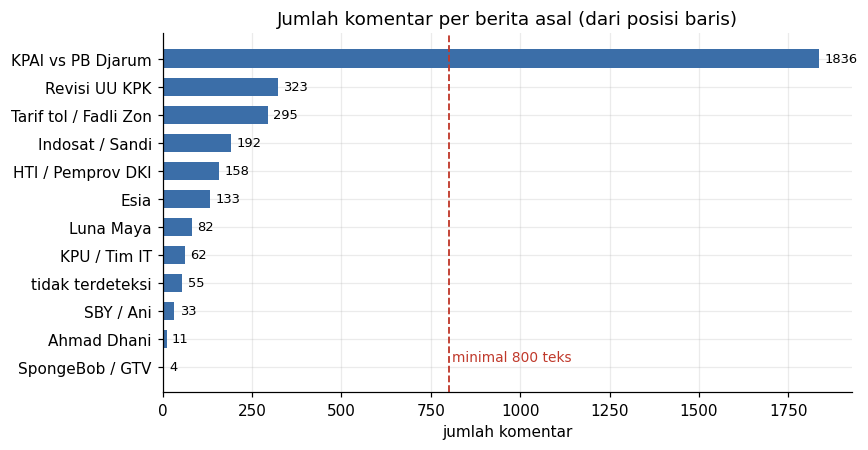

In [7]:
seg = raw["segment"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(seg.index, seg.values, color=BAR, height=0.65)
ax.axvline(800, color="#c0392b", ls="--", lw=1.2)
ax.text(810, 0.2, "minimal 800 teks", color="#c0392b", fontsize=9)
for i, v in enumerate(seg.values):
    ax.text(v + 15, i, str(v), va="center", fontsize=8.5)
ax.set_title("Jumlah komentar per berita asal (dari posisi baris)")
ax.set_xlabel("jumlah komentar")
plt.tight_layout(); plt.show()

In [8]:
# rentang baris berita KPAI vs PB Djarum
raw["_blok"] = (raw["segment"] != raw["segment"].shift()).cumsum()
blok = (raw[raw["segment"] == "KPAI vs PB Djarum"].groupby("_blok")
        .agg(dari=("id", "first"), sampai=("id", "last"), jumlah=("id", "size")))
display(blok[blok["jumlah"] >= 20].reset_index(drop=True))
raw = raw.drop(columns="_blok")

,dari,sampai,jumlah
0,ANC-1119,ANC-1461,343
1,ANC-1466,ANC-2008,543
2,ANC-2235,ANC-3184,950


**Interpretasi:**
- Metode kata kunci saja meninggalkan banyak komentar **tidak terdeteksi**, karena orang sering berkomentar tanpa menyebut topik. Metode posisi baris berhasil memberi topik pada hampir semua komentar.
- **KPAI vs PB Djarum adalah satu-satunya topik dengan lebih dari 800 komentar.** Topik terbesar berikutnya (Revisi UU KPK) hanya ±320 komentar. Ini menjadi dasar kuat pemilihan domain, sesuai arahan dosen untuk memilih satu domain spesifik.
- Komentar KPAI vs PB Djarum berada di **3 rentang baris** (utas). Di dalam rentang itu terselip komentar tentang **KPI/sensor SpongeBob** (berita no. 11), yang akan dibuang saat seleksi domain di tahap cleaning (4.3).

**Domain proyek:** polemik **KPAI vs PB Djarum** — komentar publik tentang penghentian audisi bulu tangkis karena isu eksploitasi anak dan branding rokok.

## 4.2.3 Jumlah data dan struktur kolom

In [9]:
asli = pd.read_excel(RAW_PATH)
print(f"Jumlah baris : {asli.shape[0]:,}")
print(f"Jumlah kolom : {asli.shape[1]}")
struktur = pd.DataFrame({
    "tipe data": asli.dtypes.astype(str),
    "jumlah non-null": asli.notna().sum(),
    "missing": asli.isna().sum(),
    "nilai unik": asli.nunique(),
    "contoh nilai": [asli[c].iloc[1] for c in asli.columns],
})
struktur

Jumlah baris : 3,184
Jumlah kolom : 2


,tipe data,jumlah non-null,missing,nilai unik,contoh nilai
Kalimat,object,3184,0,3169,"‚Å£‚Å£GOBLOK,ngapain beli indosat ? g ada untungnya, jaringan aja super lemot,di papua aja g ada jaringannya, mentok2 cuma 2G, harusnya pikir paka..."
label,int64,3184,0,3,3


| Kolom | Isi | Keterangan |
|---|---|---|
| `Kalimat` | teks komentar (string) | Satu baris = satu komentar. Bisa lebih dari satu kalimat, termasuk baris baru, emoji, dan hashtag |
| `label` | bilangan bulat 1, 2, atau 3 | Label tingkat keabusifan (lihat 4.2.4) |

**Yang tidak tersedia:** ID komentar, nama/ID akun, tanggal, sumber portal per baris, dan judul berita. Karena itu notebook menambahkan `id` sendiri, dan topik ditentukan dari posisi baris (4.2.2).

## 4.2.4 Label asli

Dataset memiliki **satu label per komentar** (*single-label*, 3 kelas). Definisi diambil dari README repo:

| Label | Nama | Arti |
|---|---|---|
| **1** | *not abusive* | komentar tidak mengandung bahasa abusif |
| **2** | *abusive but not offensive* | mengandung kata abusif/kasar tetapi tidak menyerang (mis. candaan) |
| **3** | *abusive and offensive* | mengandung bahasa abusif **dan** menyerang/menghina pihak tertentu |

Contoh acak untuk setiap label:

In [10]:
LABEL_NAMA = {1: "not abusive", 2: "abusive but not offensive", 3: "abusive and offensive"}
for lab, nama in LABEL_NAMA.items():
    display(Markdown(f"**Label {lab} — {nama}**"))
    contoh = raw.loc[(raw["label"] == lab) & (raw["Kalimat"].str.len() < 160), ["id", "Kalimat"]]
    display(contoh.sample(4, random_state=SEED))

**Label 1 — not abusive**

,id,Kalimat
2093,ANC-2094,"Klo menyadap prlu izin...bkn menyadap tuh, namanya mendengarkan dgn seksama.. Keburu bocor lah...aneh tu DPR"
3066,ANC-3067,Mudah2an KPAI yang akan meneruskan audisi bulutangkis untuk anak-anak sehingga mendapatkan bibit bibit yang berbakat.
891,ANC-0892,"Paling bt pas yg didepan menyalakan hp, apalagi ternyata merekam adegan biar sebentar tapi mengganggu \n\nTapi semoga LM tidak sampai ditahan, kas..."
37,ANC-0038,"Wakakak.... Akan diusahakan, tukang sayur juga bisa bilang begitu"


**Label 2 — abusive but not offensive**

,id,Kalimat
844,ANC-0845,terus g di proses hukum ?!\n\nnajis dah
119,ANC-0120,Mundur kotanya.. Gila warganya..
799,ANC-0800,"Bukan kebodohan itu mah, kenikmatan"
850,ANC-0851,"""Itu kebodohan aku aja. Jangan sampe diulangi lagi pelajarannya,"" ungkapnya.\n\n\n\n\n\n\n\n""bikin film"" sama A, kebodohan bukan?"


**Label 3 — abusive and offensive**

,id,Kalimat
1331,ANC-1332,"toket yang ada di pantung, gambar, lukisan.\nsemuanya harus kena blur, itu udah peraturan yanng di terapkan QC"
265,ANC-0266,mulut rusak.......keluarnya omongan benci terus....
364,ANC-0365,"Curhat kok ke mulut ember harusnya ke pemerintah atuh... beli mobilnya kuat kok bayar tol nya ga kuat, jual aja mobilnya bro..."
2391,ANC-2392,"KPAI ini ga ada kerjaan, apa emang isinya orang TOLOL semua sih #BubarkanKPAI"


**Catatan:** label asli hanya mengukur **tingkat keabusifan**. Label ini tidak memuat informasi **sentimen** (setuju/menolak), **target** (KPAI atau PB Djarum), maupun **entitas** yang dibicarakan. Itu sebabnya label asli hanya dipakai sebagai **referensi awal** (misalnya untuk sampling dan perbandingan), bukan sebagai skema proyek.

## 4.2.5 Distribusi awal data

### a. Distribusi label asli — seluruh dataset vs domain KPAI vs PB Djarum

In [11]:
def dist_label(df):
    vc = df["label"].value_counts().sort_index()
    return pd.DataFrame({"jumlah": vc, "persen": (vc / vc.sum() * 100).round(2)})

domain = raw[raw["segment"] == "KPAI vs PB Djarum"]
dist = pd.concat({"seluruh dataset": dist_label(raw), "domain KPAI vs PB Djarum": dist_label(domain)}, axis=1)
dist.index = [f"{i} — {LABEL_NAMA[i]}" for i in dist.index]
display(dist)
semua = raw["label"].value_counts()
print(f"Imbalance ratio (terbesar : terkecil) seluruh dataset = {semua.max() / semua.min():.1f} : 1")

seluruh dataset        domain KPAI vs PB Djarum  \
                                       jumlah persen                   jumlah   
1 — not abusive                          2789  87.59                     1615   
2 — abusive but not offensive             110   3.45                       51   
3 — abusive and offensive                 285   8.95                      170   

                                      
                              persen  
1 — not abusive                87.96  
2 — abusive but not offensive   2.78  
3 — abusive and offensive       9.26

Imbalance ratio (terbesar : terkecil) seluruh dataset = 25.4 : 1


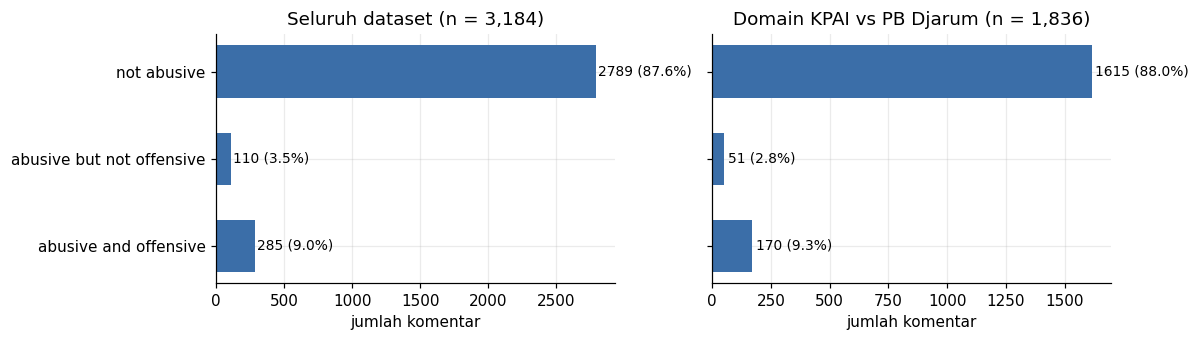

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, (judul, df) in zip(axes, [("Seluruh dataset", raw), ("Domain KPAI vs PB Djarum", domain)]):
    vc = df["label"].value_counts().sort_index()
    ax.barh([LABEL_NAMA[i] for i in vc.index], vc.values, color=BAR, height=0.6)
    for i, v in enumerate(vc.values):
        ax.text(v + 15, i, f"{v} ({v / vc.sum() * 100:.1f}%)", va="center", fontsize=9)
    ax.set_title(f"{judul} (n = {len(df):,})"); ax.set_xlabel("jumlah komentar")
axes[0].invert_yaxis()
plt.tight_layout(); plt.show()

### b. Distribusi panjang teks

In [13]:
raw["n_kata"] = raw["Kalimat"].str.split().str.len()
raw["n_karakter"] = raw["Kalimat"].str.len()
display(raw[["n_kata", "n_karakter"]].describe().round(1).T)
display(raw.groupby("label")["n_kata"].describe().round(1).rename(index=LABEL_NAMA))

,count,mean,std,min,25%,50%,75%,max
n_kata,3184.0,19.9,21.0,1.0,8.0,14.0,26.0,486.0
n_karakter,3184.0,129.1,138.2,2.0,47.0,88.5,164.0,3162.0


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
not abusive,2789.0,19.9,21.3,1.0,8.0,14.0,25.0,486.0
abusive but not offensive,110.0,19.5,19.7,1.0,6.0,14.5,26.0,118.0
abusive and offensive,285.0,20.4,18.7,1.0,7.0,15.0,29.0,110.0


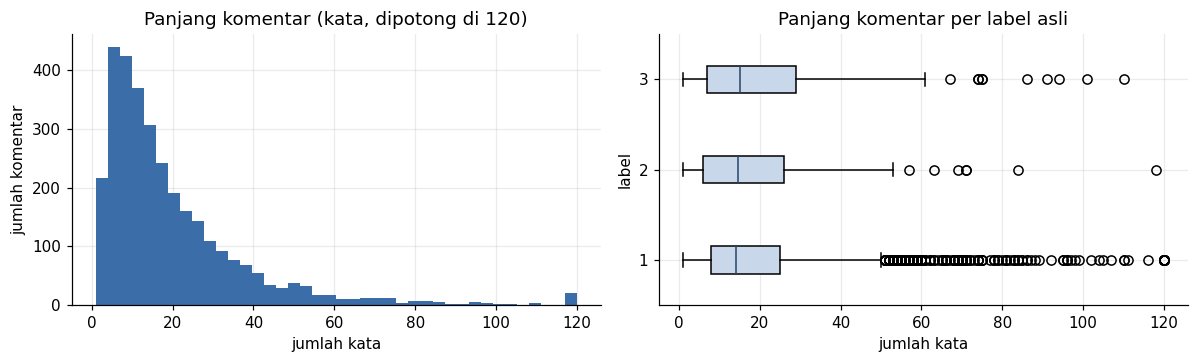

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(raw["n_kata"].clip(upper=120), bins=40, color=BAR)
axes[0].set_title("Panjang komentar (kata, dipotong di 120)"); axes[0].set_xlabel("jumlah kata"); axes[0].set_ylabel("jumlah komentar")
data = [raw.loc[raw["label"] == l, "n_kata"].clip(upper=120) for l in (1, 2, 3)]
axes[1].boxplot(data, labels=["1", "2", "3"], vert=False, patch_artist=True,
                boxprops=dict(facecolor="#c9d7ea"), medianprops=dict(color="#24456b"))
axes[1].set_title("Panjang komentar per label asli"); axes[1].set_xlabel("jumlah kata"); axes[1].set_ylabel("label")
plt.tight_layout(); plt.show()

### c. Distribusi label per topik

In [15]:
ct = pd.crosstab(raw["segment"], raw["label"], margins=True, margins_name="total")
ct.columns = [f"label {c}" if c != "total" else c for c in ct.columns]
ct["% abusif (2+3)"] = ((ct["label 2"] + ct["label 3"]) / ct["total"] * 100).round(1)
ct.sort_values("total", ascending=False)

,label 1,label 2,label 3,total,% abusif (2+3)
segment,,,,,
total,2789,110,285,3184,12.4
KPAI vs PB Djarum,1615,51,170,1836,12.0
Revisi UU KPK,301,4,18,323,6.8
Tarif tol / Fadli Zon,243,7,45,295,17.6
Indosat / Sandi,170,7,15,192,11.5
HTI / Pemprov DKI,151,1,6,158,4.4
Esia,124,8,1,133,6.8
Luna Maya,51,16,15,82,37.8
KPU / Tim IT,47,7,8,62,24.2


**Interpretasi:**
- Data **sangat tidak seimbang**: ±88% komentar berlabel *not abusive*, dengan rasio kelas terbesar : terkecil sekitar **25 : 1**. Dampaknya terlihat di notebook asli repo: model mencapai akurasi ±87% hanya dengan **selalu menebak kelas 1** (recall kelas 2 dan 3 = 0). Proyek ini karena itu tidak akan memakai *accuracy* sebagai satu-satunya metrik.
- Panjang komentar sangat bervariasi (median ±14 kata, ada yang ratusan kata), tetapi **hampir sama di ketiga label**. Jadi panjang teks bukan pembeda keabusifan.
- Domain KPAI vs PB Djarum memiliki proporsi abusif yang mirip dengan keseluruhan data (±11–12%), sehingga label `ABUSIVE` tetap minoritas dan perlu diperhatikan saat sampling.

## 4.2.6 Masalah kualitas data yang ditemukan

Pemeriksaan dilakukan pada teks **asli** (sebelum cleaning). Ada lima kelompok masalah: (a) noise teknis, (b) duplikat & teks tidak layak, (c) noise linguistik, (d) masalah label, dan (e) masalah metadata.

### a. Noise teknis (encoding, karakter, markup)

In [16]:
t = raw["Kalimat"].astype(object)   # object dtype: regex Python (mendukung backreference)

def fix_mojibake(s):
    """UTF-8 yang terbaca sebagai Mac Roman -> teks asli. Jika gagal, kembalikan teks semula."""
    try:
        return s.encode("mac_roman").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s

def decode_pct(s):
    """'%uD83D%uDE02' -> emoji (escape gaya JavaScript, termasuk surrogate pair)."""
    def rep(m):
        cps = [int(x, 16) for x in re.findall(r"%u([0-9A-Fa-f]{4})", m.group(0))]
        return "".join(map(chr, cps)).encode("utf-16", "surrogatepass").decode("utf-16", "replace")
    return re.sub(r"(?:%u[0-9A-Fa-f]{4})+", rep, s)

pulih = t.map(fix_mojibake).map(decode_pct)        # teks setelah encoding diperbaiki (untuk pengecekan)

def cek(pola, regex=True, seri=None):
    seri = t if seri is None else seri
    m = seri.str.contains(pola, regex=regex)
    contoh = seri[m].iloc[0][:90] if m.any() else ""
    return int(m.sum()), repr(contoh)

noise_teknis = {
    "Mojibake (UTF-8 terbaca sebagai Mac Roman: ÔøΩ, \\uf8ff, ‚Å£)": (int((t.map(fix_mojibake) != t).sum()), repr(t[t.map(fix_mojibake) != t].iloc[1][:90])),
    "Escape emoji gaya JavaScript (%uD83D%uDE02)": cek(r"%u[0-9A-Fa-f]{4}"),
    "Emoji hilang permanen (U+FFFD, setelah encoding diperbaiki)": cek("\ufffd", regex=False, seri=pulih),
    "Karakter tak terlihat (U+2063 dll., setelah encoding diperbaiki)": cek("[\u200b-\u200f\u2060-\u2064\ufeff]", seri=pulih),
    "Baris baru (\\n) di dalam komentar": cek("\n", regex=False),
    "Spasi ganda / berlebih": cek(r"  +"),
    "URL": cek(r"https?://|www\."),
    "Username (@...)": cek(r"(?<!\w)@\w+"),
    "Tag HTML": cek(r"<[^>]+>"),
}
pd.DataFrame(noise_teknis, index=["jumlah baris", "contoh"]).T

,jumlah baris,contoh
"Mojibake (UTF-8 terbaca sebagai Mac Roman: ÔøΩ, \uf8ff, ‚Å£)",348,"'Saya percaya kalau sama Sandiaga Uno, tapi kalau sama Jokowi.. 100%gak percaya,ÔøΩ'"
Escape emoji gaya JavaScript (%uD83D%uDE02),106,'%u2063Menjadi Atlet Berprestasi itu Mahal ! Dunia Olahraga dan dunia pendidikan saat ini '
"Emoji hilang permanen (U+FFFD, setelah encoding diperbaiki)",267,"'Saya percaya kalau sama Sandiaga Uno, tapi kalau sama Jokowi.. 100%gak percaya,�'"
"Karakter tak terlihat (U+2063 dll., setelah encoding diperbaiki)",48,"'\u2063\u2063GOBLOK,ngapain beli indosat ? g ada untungnya, jaringan aja super lemot,di papua aja g a'"
Baris baru (\n) di dalam komentar,294,'segitu mahal ? kelewatan klo gt\n'
Spasi ganda / berlebih,165,"'IT yg jenius itu ketika mereka kerja bs menolong org banyak, bukan kerja untuk menjerumusk'"
URL,3,'msh mahal bayar Zonki dan tak berguna mendingan buat bayar Tol ..wowww. mini daus mudik ga'
Username (@...),2,"'@khafidz99 w bisa bilang mereka malah gak nonton itu gan, klo misalnya yg kerja isinya gen'"
Tag HTML,0,''


In [17]:
# bukti bahwa mojibake & escape emoji bisa dipulihkan
contoh_moji = t[t.map(lambda x: "\uf8ff" in x)].iloc[0]
contoh_pct = t[t.str.contains("%uD83D", regex=False)].iloc[0]
i = contoh_pct.find("%u")
print("Mojibake   :", repr(contoh_moji[-45:]))
print("diperbaiki :", repr(fix_mojibake(contoh_moji)[-35:]))
print("Escape %u  :", repr(contoh_pct[max(0, i - 30): i + 24]))
print("diperbaiki :", repr(decode_pct(contoh_pct)[max(0, i - 30): i + 2]))

Mojibake   : 'eli sahan Freeport itu, jelas logis. \uf8ffüòâ\uf8ffüòâ'
diperbaiki : 'sahan Freeport itu, jelas logis. 😉😉'
Escape %u  : 'ri rokok juga.   apalagi ya.. %uD83D%uDE02'
diperbaiki : 'ri rokok juga.   apalagi ya.. 😂'


**Interpretasi:** sebagian besar noise teknis berasal dari **kesalahan encoding saat crawling**, bukan dari penulis komentar. Mojibake dan escape `%u` **bisa dipulihkan 100%** menjadi emoji asli (😂, 😉), sehingga informasi emosi tidak hilang. Sebaliknya, karakter `�` (U+FFFD) berarti emojinya sudah hilang sejak crawling dan tidak bisa dikembalikan. Karakter tak terlihat (U+2063) baru tampak setelah encoding diperbaiki, karena sebelumnya tersamar sebagai `‚Å£`.

### b. Duplikat, teks kosong, dan teks tidak layak

In [18]:
kunci = t.str.strip().str.lower()
dup = kunci.duplicated(keep=False)
konflik = raw[dup].groupby(kunci[dup])["label"].nunique().gt(1).sum()
tidak_layak = {
    "missing / kosong": int(t.isna().sum() + (t.str.strip() == "").sum()),
    "duplikat persis": int(t.duplicated().sum()),
    "duplikat (abaikan huruf besar/kecil & spasi tepi)": int(kunci.duplicated().sum()),
    "duplikat dengan label bertentangan": int(konflik),
    "tanpa huruf sama sekali (mis. ':(' , '1111')": int((~t.str.contains(r"[A-Za-z]")).sum()),
    "hanya 1 kata": int((raw["n_kata"] == 1).sum()),
    "lebih dari 200 kata": int((raw["n_kata"] > 200).sum()),
}
display(pd.Series(tidak_layak, name="jumlah baris").to_frame())
print("Contoh duplikat:", raw.loc[dup, "Kalimat"].str.strip().value_counts().head(3).to_dict())
print("Contoh tanpa huruf:", t[~t.str.contains(r"[A-Za-z]")].tolist())
print("Contoh 1 kata:", t[raw["n_kata"] == 1].head(10).tolist())

,jumlah baris
missing / kosong,0
duplikat persis,15
duplikat (abaikan huruf besar/kecil & spasi tepi),20
duplikat dengan label bertentangan,0
"tanpa huruf sama sekali (mis. ':(' , '1111')",5
hanya 1 kata,42
lebih dari 200 kata,1


Contoh duplikat: {'#bubarkankpai': 3, '#BUBARKANKPAI': 3, 'Manusia yang mukanya lebih ruwet dari sampah alias sampah masyarakat tukang nyinyir tp gaji DPR': 2}
Contoh tanpa huruf: [':(', ':** ', '1111', '1 + 1 = 0', '1 + 1 = 2']
Contoh 1 kata: ['Palsuuuuuuuu', ':(', ':** ', 'Blunder....', '1111', 'Huahuahaaaaaa', ' guoblog...', '\nSetuju', 'matabelo', '\nBahalul']


Teks pendek **tidak otomatis dibuang**: banyak komentar 1 kata justru bermakna (mis. `kampungan`, `Bahalul`). Yang dibuang hanya teks tanpa huruf dan duplikat.

### c. Noise linguistik (dipertahankan, tapi perlu ditangani di normalisasi/guideline)

In [19]:
noise_linguistik = {
    "Huruf berulang (Palsuuuu, enaaak)": cek(r"(\w)\1{2,}"),
    "Tanda baca berulang (!!!, ???)": cek(r"([!?.])\1+"),
    "Kata dalam HURUF KAPITAL (≥4 huruf)": cek(r"\b[A-Z]{4,}\b"),
    "Hashtag (#BubarkanKPAI)": cek(r"#\w+"),
    "Kata kasar disensor/disamarkan (b*rak, beg0, ng3w3)": cek(r"\b\w+\*+\w+\b|\bbeg0\b|ng3w3|\bbgsd\b"),
    "Reduplikasi dengan angka (anak2)": cek(r"\b[A-Za-z]{2,}2\b"),
}
pd.DataFrame(noise_linguistik, index=["jumlah baris", "contoh"]).T

,jumlah baris,contoh
"Huruf berulang (Palsuuuu, enaaak)",198,'Palsuuuuuuuu'
"Tanda baca berulang (!!!, ???)",1265,'san ente aje yg unboxing Indosat. masa ente kalah ama kemenakan Prabowo...unboxing mesin a'
Kata dalam HURUF KAPITAL (≥4 huruf),895,"'‚Å£‚Å£GOBLOK,ngapain beli indosat ? g ada untungnya, jaringan aja super lemot,di papua aja'"
Hashtag (#BubarkanKPAI),86,"'Apa untungnya beli Indosat, cuma dompleng beken doang.... #woles'"
"Kata kasar disensor/disamarkan (b*rak, beg0, ng3w3)",18,'Kinerja Indosat sedang b*brok mau dibeli? Lunasi hutangmu dulu Asen. Presiden Jokowi sudah'
Reduplikasi dengan angka (anak2),563,"'‚Å£‚Å£GOBLOK,ngapain beli indosat ? g ada untungnya, jaringan aja super lemot,di papua aja'"


### d. Masalah label

In [20]:
KASAR = r"\b(goblo\w*|tolol\w*|bego|dungu|bangsat|anjing|bajingan|kampret|idiot|sampah)\b"
ada_kasar = t.str.lower().str.contains(KASAR)
display(pd.crosstab(ada_kasar.rename("mengandung kata kasar kuat"), raw["label"].rename("label asli")))
print("Contoh komentar berkata kasar tetapi berlabel 1 (not abusive):")
for s in raw.loc[ada_kasar & (raw["label"] == 1), "Kalimat"].str[:120].head(6):
    print("  -", s)

label asli,1,2,3
mengandung kata kasar kuat,,,
False,2766,98,186
True,23,12,99


Contoh komentar berkata kasar tetapi berlabel 1 (not abusive):
  - Mending beli satelite bos ..ÔøΩ bego di piara . Kambing di piara bisa gemuk
  - Dasar sampah klo RI beli satelit sendiri biaya ya lebih murah. Lagian indosat lagi rugi triliunan makanya di jual ke inv
  - Ngapain beli perusahaan yg mau ambruk dasar dungu
  - Mulutmu sampah!!!
  - Klo dr jakarta - surabaya hanya 600rb an mahal nya dmn ya? Dasar otak jongos, sekalipun 100rb ttp aja dia bilang mahal. 
  - manusia itu ada yg berguna dan ada yg tidak berguna. anda FZ ini memungut 1 botol plastik di jalan, lalu dibuang ke temp


**Interpretasi:** ada **23 komentar** berkata kasar kuat (mis. `Mulutmu sampah!!!`, `dasar dungu`) yang justru berlabel *not abusive*. Ini menunjukkan **label asli tidak konsisten**. Sebaliknya, 186 komentar berlabel 3 tidak memuat kata kasar umum, yang berarti abusif sering muncul secara **implisit** (sindiran, pelesetan). Keduanya menjadi alasan proyek melakukan **anotasi ulang** dengan guideline yang jelas, bukan memakai label asli.

### e. Masalah metadata
- Tidak ada **ID**, **tanggal**, **akun**, atau **sumber portal** per baris, sehingga topik harus ditebak dari isi teks dan posisi baris (4.2.2).
- Notebook asli repo bergantung pada file yang **tidak ada** di repo (`dataset_stemming - Sheet1.csv`, `stopwords.txt`, `kamusalay.csv`), sehingga pipeline lama tidak bisa dijalankan ulang.

### Ringkasan masalah kualitas & rencana penanganan

| Masalah | Dampak | Rencana penanganan (tahap cleaning) |
|---|---|---|
| Mojibake, escape `%u`, karakter tak terlihat | teks rusak; emoji tidak terbaca | dipulihkan ke UTF-8/emoji, karakter tak terlihat dihapus |
| Emoji hilang permanen (`�`) | informasi emosi hilang | `�` dihapus dan dicatat di kolom flag |
| Baris baru & spasi berlebih | tampilan dan tokenisasi tidak konsisten | diseragamkan menjadi satu spasi |
| URL / username | noise + privasi | diganti `[URL]` / `[USER]` |
| Duplikat & teks tanpa huruf | data ganda / tidak bisa dianotasi | dibuang (dicatat alasannya) |
| Huruf/tanda baca berulang, kapital, hashtag, sensor | **sinyal emosi & entitas** | **dipertahankan** di teks anotasi; dinormalkan hanya di kolom analisis |
| Label tidak konsisten (kata kasar berlabel 1) | label asli tidak bisa dipercaya penuh | anotasi ulang dengan guideline baru |
| Label sangat tidak seimbang | model bias ke kelas mayoritas | sampling purposive + metrik per label |
| Tanpa metadata | topik tidak diketahui | topik dari posisi baris + kata kunci |

## 4.2.7 Potensi pengembangan dataset menjadi permasalahan multilabel dan NER

Label asli hanya menjawab *"abusif atau tidak?"*. Pada domain KPAI vs PB Djarum, isi komentar ternyata jauh lebih kaya. Bagian ini menunjukkan **bukti dari corpus** bahwa data layak dikembangkan menjadi dua tugas.

### a. Bukti untuk multilabel: satu komentar memuat beberapa fenomena sekaligus

In [21]:
dom = raw[raw["segment"] == "KPAI vs PB Djarum"].copy()
dl = dom["Kalimat"].str.lower()
indikasi = {
    "menyerang / menolak KPAI": r"bubar|kpai.{0,40}(gak|ga|tidak|nggak) (becus|guna|berguna|mikir)|cari (sensasi|panggung)|kpai.{0,30}(bodoh|goblok|tolol|bego|dungu)",
    "membela KPAI": r"kpai (benar|betul)|setuju (dengan |sama )?kpai|dukung kpai|melindungi anak",
    "membela PB Djarum / audisi": r"djarum.{0,60}(berjasa|jasa|dukung|hebat|terima ?kasih|bibit|prestasi)|sayang|kasihan|atlet",
    "mengkritik PB Djarum / rokok": r"promosi|terselubung|iklan rokok|yayasan sosial|branding",
    "bahasa abusif (kata kasar)": r"goblo|tolol|bodoh|bego|beg0|dungu|bangsat|anjing|sampah|otak",
}
M = pd.DataFrame({k: dl.str.contains(p) for k, p in indikasi.items()})
ringkas = pd.DataFrame({"jumlah komentar": M.sum(), "persen domain": (M.mean() * 100).round(1)})
display(ringkas)
print(f"Komentar dengan ≥2 indikasi sekaligus: {(M.sum(axis=1) >= 2).sum()} "
      f"({(M.sum(axis=1) >= 2).mean() * 100:.1f}% domain)")

,jumlah komentar,persen domain
menyerang / menolak KPAI,245,13.3
membela KPAI,13,0.7
membela PB Djarum / audisi,103,5.6
mengkritik PB Djarum / rokok,27,1.5
bahasa abusif (kata kasar),136,7.4


Komentar dengan ≥2 indikasi sekaligus: 65 (3.5% domain)


In [22]:
print("Contoh komentar dengan beberapa indikasi sekaligus:\n")
multi = dom[M.sum(axis=1) >= 2]
for _, r in multi[multi["Kalimat"].str.len() < 230].sample(5, random_state=SEED).iterrows():
    tanda = ", ".join(M.columns[M.loc[r.name]])
    print(f"[{r['id']}] {r['Kalimat'][:230]}\n   → indikasi: {tanda}\n")

Contoh komentar dengan beberapa indikasi sekaligus:

[ANC-3076] KPAI ... ketuanya cari panggung, sebentar lagi bibit atlit sepakbola, atletik, renang, karate ...dsb akan hilang .. karena latihannya toh pasti kadang2 dibentak bentak dan keras secara phisik .....ÔøΩ
   → indikasi: menyerang / menolak KPAI, membela PB Djarum / audisi

[ANC-2424] Usul sy sebaiknya anggaran kpai dipakai buat audisi mencari bibit atlet bulutangkis & pembinaan mereka ke depannya. Trus kpainya? Bubarin saja..
   → indikasi: menyerang / menolak KPAI, membela PB Djarum / audisi

[ANC-2518] KPAI bisa nyariin yayasan dan dana sebesar yang dikeluarkan PB.Djarum, prestasi bulutangkis kira merosot malah dinyinyirin, bubarin KPAI dan LSM pendukungnya...pengkhianat...
   → indikasi: menyerang / menolak KPAI, membela PB Djarum / audisi

[ANC-3174] KPAI tolol, di us, china, rusia, itu anak2 dr kecil udah digembleng abis abisan. Di eropa yg namanya pemain bola itu masuk sekolah sepak bola dr kecil. Trs mau mencetak atlet 

**Interpretasi:**
- Komentar di domain ini bukan sekadar abusif atau tidak. Isinya **sikap terhadap dua pihak yang berlawanan**: menyerang KPAI, membela PB Djarum, mengkritik rokok, dan sebagainya. Dalam satu komentar, sikap-sikap ini bisa muncul **bersamaan** dengan bahasa abusif, sehingga cocok untuk **multilabel**.
- Opini terlihat **berat sebelah**: indikasi menyerang KPAI jauh lebih banyak daripada membela KPAI. Ini menjadi temuan penting sekaligus peringatan akan *imbalance* label.
- Hitungan berbasis kata kunci ini adalah **batas bawah** dan hanya **indikasi awal** untuk membuktikan potensi, bukan label. Banyak sikap diungkapkan tanpa kata kunci (sarkasme, pertanyaan retoris), dan label final ditentukan lewat anotasi manual.

### b. Bukti untuk NER: entitas yang dibicarakan

In [23]:
entitas = {
    "GOV_ORG (lembaga negara)": {"KPAI": r"\bkpai\b", "KPI": r"\bkpi\b", "pemerintah": r"pemerintah",
                                 "Komnas": r"komnas", "DPR": r"\bdpr\b", "Kemenpora/Menpora": r"menpora"},
    "NONGOV_ORG (organisasi non-pemerintah)": {"Djarum / PB Djarum": r"djarum|\bjarum\b", "PBSI": r"pbsi",
                                               "Sampoerna": r"sampoerna", "Lentera Anak": r"lentera"},
    "PERSON (nama orang)": {"Susanto (ketua KPAI)": r"susanto", "Jokowi": r"jokowi",
                            "atlet (Kevin, Marcus, Susi, dll.)": r"kevin|marcus|susi|liliyana|taufik|ginting"},
    "GROUP (kelompok orang)": {"anak / anak2 / anak-anak": r"\banak", "atlet / pemain / bibit": r"atlet|atlit|pemain|bibit",
                               "orang tua": r"orang ?tua|ortu", "masyarakat / rakyat / netizen": r"masyarakat|rakyat|netizen|netijen",
                               "perokok": r"perokok"},
}
rows = [{"tipe entitas (usulan)": tipe, "contoh entitas": nama, "komentar yang menyebut": int(dl.str.contains(p).sum())}
        for tipe, d in entitas.items() for nama, p in d.items()]
pd.DataFrame(rows)

,tipe entitas (usulan),contoh entitas,komentar yang menyebut
0,GOV_ORG (lembaga negara),KPAI,902
1,GOV_ORG (lembaga negara),KPI,116
2,GOV_ORG (lembaga negara),pemerintah,45
3,GOV_ORG (lembaga negara),Komnas,26
4,GOV_ORG (lembaga negara),DPR,1
5,GOV_ORG (lembaga negara),Kemenpora/Menpora,6
6,NONGOV_ORG (organisasi non-pemerintah),Djarum / PB Djarum,423
7,NONGOV_ORG (organisasi non-pemerintah),PBSI,1
8,NONGOV_ORG (organisasi non-pemerintah),Sampoerna,12
9,NONGOV_ORG (organisasi non-pemerintah),Lentera Anak,7


### c. Usulan skema berdasarkan bukti di atas

**Tugas A — Multilabel (sentimen, level teks).** Setiap komentar dinilai pada tiga dimensi terpisah, lalu diberi **semua** label yang berlaku:

| Label | Kategori yang termasuk (dari pola corpus) |
|---|---|
| `KPAI_POSITIVE` | membela KPAI; setuju branding rokok dilarang; audisi = eksploitasi anak; menolak KPAI dibubarkan |
| `KPAI_NEGATIVE` | kritik kinerja/keputusan KPAI; tuduhan cari sensasi; membandingkan dengan masalah anak lain; khawatir prestasi turun; #BubarkanKPAI; sarkasme ke KPAI |
| `PBDJARUM_POSITIVE` | apresiasi pembinaan atlet; menyayangkan audisi dihentikan; menilai logo wajar |
| `PBDJARUM_NEGATIVE` | audisi = promosi rokok terselubung; kritik yayasan/branding rokok |
| `ABUSIVE` | makian, hinaan, ejekan merendahkan, termasuk bentuk sensor dan pelesetan |
| `NEUTRAL` | tidak bersikap ke KPAI maupun PB Djarum (eksklusif) |

**Tugas B — NER (level kata).** Hanya **nama/sebutan entitas** yang dilabeli (opini dan makian tidak):

| Tipe | Contoh teks yang masuk NER |
|---|---|
| `GOV_ORG` | `KPAI`, `Komisi Perlindungan Anak Indonesia`, `KPI`, `pemerintah` |
| `NONGOV_ORG` | `PB Djarum`, `Djarum Foundation`, `PBSI` |
| `PERSON` | `Susanto`, `Jokowi`, `Kevin` |
| `GROUP` | `anak-anak`, `anak2`, `atlet muda`, `orang tua`, `perokok` |

**Hubungan kedua tugas:** NER menjawab **siapa** yang dibicarakan, multilabel menjawab **bagaimana sikapnya**. `KPAI_*` ↔ `GOV_ORG` (KPAI), `PBDJARUM_*` ↔ `NONGOV_ORG` (PB Djarum), `ABUSIVE` ↔ sasaran makian. Contoh nyata dari corpus:

In [24]:
contoh = dom.loc[dom["Kalimat"].str.contains("PB Djarum tuh bukan berjasa", regex=False)].iloc[0]
teks = contoh["Kalimat"].strip()
spans = [("PB Djarum", "NONGOV_ORG"), ("atlet", "GROUP"), ("KPAI", "GOV_ORG")]
print(f"[{contoh['id']}] label asli = {contoh['label']} ({LABEL_NAMA[contoh['label']]})")
print("Teks :", teks)
print("NER  :", "  ".join(f"[{s}]{l} @{teks.find(s)}-{teks.find(s) + len(s)}" for s, l in spans))
print("Label:", ["PBDJARUM_POSITIVE", "KPAI_NEGATIVE", "ABUSIVE"])

[ANC-2385] label asli = 1 (not abusive)
Teks : PB Djarum tuh bukan berjasa cari bibit aja tapi pembiayaan sponsor sampe jadi atlet sama pelatih juga.. sayang kemampuan otaknya orang2 KPAI terbatas..
NER  : [PB Djarum]NONGOV_ORG @0-9  [atlet]GROUP @78-83  [KPAI]GOV_ORG @136-140
Label: ['PBDJARUM_POSITIVE', 'KPAI_NEGATIVE', 'ABUSIVE']


Satu komentar ini memuat **tiga label sekaligus** (membela PB Djarum, menyerang KPAI, dan abusif lewat hinaan "kemampuan otaknya ... terbatas") serta **tiga entitas dengan tipe berbeda**. Label aslinya justru `1 — not abusive`. Contoh ini memperlihatkan dua kelemahan label asli sekaligus: label asli tidak menangkap sentimen maupun target, dan juga melewatkan hinaan.

## 4.2.8 Ringkasan Dataset Selection & Domain Analysis

In [25]:
n_dom = len(dom)
abusif_dom = int((dom["label"] > 1).sum())
ringkasan = pd.DataFrame([
    ("Sumber", "Komentar Kompas, Kaskus, Detik — 15 berita 2019 (paper IEEE 9034620)"),
    ("Tujuan awal", "Deteksi bahasa abusif, klasifikasi 3 kelas (NB/SVM/KNN)"),
    ("Bahasa", "Indonesia informal: singkatan, slang, Betawi/daerah, campur Inggris"),
    ("Jumlah & kolom", f"{len(raw):,} baris × 2 kolom (Kalimat, label); tanpa metadata"),
    ("Label asli", "1 not abusive · 2 abusive not offensive · 3 abusive & offensive (single-label)"),
    ("Distribusi", f"label 1 = {(raw['label'] == 1).mean() * 100:.1f}% → sangat tidak seimbang (±25:1)"),
    ("Domain terpilih", f"KPAI vs PB Djarum: {n_dom:,} komentar sebelum cleaning ({abusif_dom} berlabel abusif); "
                        "jumlah final setelah cleaning & membuang blok berita KPI/SpongeBob ditetapkan di tahap 4.3"),
    ("Masalah kualitas", "mojibake, escape emoji, emoji hilang, karakter tak terlihat, duplikat, label tidak konsisten, tanpa metadata"),
    ("Potensi", "Multilabel sentimen (6 label) + NER (4 tipe entitas) yang saling terhubung"),
], columns=["aspek", "temuan"]).set_index("aspek")
ringkasan

,temuan
aspek,
Sumber,"Komentar Kompas, Kaskus, Detik — 15 berita 2019 (paper IEEE 9034620)"
Tujuan awal,"Deteksi bahasa abusif, klasifikasi 3 kelas (NB/SVM/KNN)"
Bahasa,"Indonesia informal: singkatan, slang, Betawi/daerah, campur Inggris"
Jumlah & kolom,"3,184 baris × 2 kolom (Kalimat, label); tanpa metadata"
Label asli,1 not abusive · 2 abusive not offensive · 3 abusive & offensive (single-label)
Distribusi,label 1 = 87.6% → sangat tidak seimbang (±25:1)
Domain terpilih,"KPAI vs PB Djarum: 1,836 komentar sebelum cleaning (221 berlabel abusif); jumlah final setelah cleaning & membuang blok berita KPI/SpongeBob ditet..."
Masalah kualitas,"mojibake, escape emoji, emoji hilang, karakter tak terlihat, duplikat, label tidak konsisten, tanpa metadata"
Potensi,Multilabel sentimen (6 label) + NER (4 tipe entitas) yang saling terhubung


**Kesimpulan:** dataset ini layak dikembangkan untuk proyek karena (1) domain KPAI vs PB Djarum cukup besar (> 800 komentar), (2) komentarnya kaya akan sikap terhadap dua pihak yang berlawanan, sehingga cocok untuk **multilabel sentimen**, dan (3) entitas yang dibicarakan jelas dan sering muncul, sehingga cocok untuk **NER**. Masalah kualitas yang ditemukan akan ditangani di tahap **4.3 Data Cleaning**, dengan prinsip memperbaiki noise teknis tanpa menghilangkan informasi penting bagi anotasi.

---
# 4.3 Data Cleaning dan Kriteria Minimum

Bagian ini membersihkan dataset dan menghasilkan **`KelpNLP_dataset_clean.csv`** (output wajib #2). **Belum ada pelabelan** di tahap ini. Label sentimen dan entitas baru dibuat pada tahap anotasi; kolom `orig_label` hanyalah label bawaan dataset asli yang dibawa sebagai metadata.

### Prinsip cleaning
1. **Hanya noise teknis yang diperbaiki**: encoding rusak, escape, karakter tak terlihat, sisa markup, URL/username, dan spasi. Noise ini berasal dari proses *crawling*, bukan dari penulis komentar.
2. **Ciri tulisan komentator dipertahankan**: huruf kapital, emoji, tanda baca berulang (`!!!`), hashtag, huruf berulang (`Palsuuuu`), dan kata yang disensor (`beg0`). Semuanya membawa sinyal sentimen atau abusif, dan menjadi bagian dari teks yang nanti dianotasi.
3. **Teks asli tidak pernah ditimpa.** `text_raw` menyimpan teks asli, `text_clean` menyimpan hasil cleaning. Offset entitas NER nanti dihitung pada `text_clean`, sehingga teks ini dibekukan setelah tahap ini.
4. **Setiap perubahan bisa dilacak**: ID permanen per baris, *flag* `had_*` per langkah, `cleaning_log.csv` (statistik tiap langkah), dan `removed_rows.csv` (baris yang dibuang beserta alasannya).
5. **Bisa dijalankan ulang**: seluruh langkah berupa fungsi, tanpa suntingan manual pada data.

### Alur
```
dataset/KelpNLP_dataset_original.xlsx   (salinan dataset asli, tidak diubah)
      │
      │  4.3.1  beri ID permanen ANC-0001 … + pemeriksaan awal sesuai kriteria minimum
      ▼
PERBAIKAN TEKS  — jumlah baris tetap, hanya isi teks yang diperbaiki          (4.3.2 – 4.3.3)
      C1 mojibake → C2 escape %u → C3 karakter hilang (�) → C4 karakter tak terlihat
      → C5 Unicode NFC → C6 markup → C7 URL → C8 username → C9 spasi
      ▼
PEMBUANGAN BARIS — baris tidak layak dibuang dan dicatat                      (4.3.4)
      C10 teks tanpa huruf → C11 duplikat
      ▼
SELEKSI DOMAIN  — baris tidak dibuang, hanya ditandai                         (4.3.5)
      kolom segment, thread, in_domain  (domain KPAI vs PB Djarum)
      ▼
STATISTIK sebelum–sesudah (4.3.6) → VALIDASI (4.3.7) → SIMPAN (4.3.8)
      ▼
dataset/KelpNLP_dataset_clean.csv  +  dataset/pendukung/cleaning_log.csv, removed_rows.csv
```

### Kriteria minimum spesifikasi → langkah di notebook
| Kriteria minimum (spesifikasi 4.3) | Diperiksa di | Ditangani di |
|---|---|---|
| Missing values | 4.3.1 | tidak ditemukan (teks kosong tetap dijaga oleh C10) |
| Duplicate text | 4.3.1 | C11 |
| Empty text | 4.3.1 | C10 |
| Karakter atau markup yang tidak relevan | 4.3.1, 4.3.3 | C1–C6 |
| URL/HTML | 4.3.1 | C6, C7 (username: C8) |
| Spasi/encoding | 4.3.1 | C1, C2, C5, C9 |
| Teks yang terlalu pendek | 4.3.1, 4.3.4 | diperiksa; hanya teks tanpa huruf yang dibuang (C10) |

## 4.3.1 Persiapan: file output, ID permanen, dan pemeriksaan awal

Tiga hal disiapkan sebelum cleaning:
1. **Path output** mengikuti struktur folder spesifikasi 4.10. File pendukung (log) disimpan di `dataset/pendukung/`.
2. **Dataset asli disalin apa adanya** menjadi `KelpNLP_dataset_original.xlsx` (output wajib #1). Cleaning membaca dari salinan ini.
3. **ID permanen** `ANC-0001` … diberikan sesuai urutan baris asli. ID inilah yang menghubungkan `text_raw`, `text_clean`, log, dan nanti hasil anotasi.

In [26]:
import hashlib
import html
import shutil
import unicodedata

# ---------- identitas kelompok & path output (struktur folder spesifikasi 4.10) ----------
KELOMPOK = "NLP"
PREFIX = f"Kelp{KELOMPOK}"                                         # -> "KelpNLP"

DATASET_DIR = ROOT / "dataset"
SUPPORT_DIR = DATASET_DIR / "pendukung"                            # file pendukung (bukti proses)
ORIGINAL_PATH = DATASET_DIR / f"{PREFIX}_dataset_original.xlsx"    # output wajib 1: dataset asli
CLEAN_PATH = DATASET_DIR / f"{PREFIX}_dataset_clean.csv"           # output wajib 2: dataset hasil cleaning
CLEANING_LOG_PATH = SUPPORT_DIR / "cleaning_log.csv"               # statistik tiap langkah cleaning
REMOVED_ROWS_PATH = SUPPORT_DIR / "removed_rows.csv"               # baris yang dibuang + alasannya
SUPPORT_DIR.mkdir(parents=True, exist_ok=True)

ORIG_LABEL_NAMES = {1: "not_abusive", 2: "abusive_not_offensive", 3: "abusive_offensive"}

# ---------- 1) salin dataset asli tanpa perubahan apa pun ----------
if not ORIGINAL_PATH.exists():
    shutil.copyfile(RAW_PATH, ORIGINAL_PATH)

def md5(path):
    return hashlib.md5(path.read_bytes()).hexdigest()

print("Dataset asli :", ORIGINAL_PATH.relative_to(ROOT),
      "| identik dengan file sumber:", md5(RAW_PATH) == md5(ORIGINAL_PATH))

# ---------- 2) muat dataset asli + beri ID permanen ----------
def load_original(path=ORIGINAL_PATH):
    """Muat dataset asli. Nama kolom diseragamkan dan tiap baris diberi ID sesuai urutan aslinya."""
    df = pd.read_excel(path).rename(columns={"Kalimat": "text_raw", "label": "orig_label"})
    df.attrs["n_missing_text"] = int(df["text_raw"].isna().sum())      # dicatat sebelum NaN diisi
    df.attrs["n_missing_label"] = int(df["orig_label"].isna().sum())
    df["text_raw"] = df["text_raw"].fillna("").astype(str)             # NaN -> "" (nanti dibuang oleh C10)
    df.insert(0, "id", [f"ANC-{i + 1:04d}" for i in range(len(df))])
    df["orig_label_name"] = df["orig_label"].map(ORIG_LABEL_NAMES)
    return df

df_raw = load_original()
N_ASLI = len(df_raw)
print(f"Jumlah baris : {N_ASLI:,} | kolom: {df_raw.columns.tolist()}")
df_raw.head(3)

Dataset asli : dataset/KelpNLP_dataset_original.xlsx | identik dengan file sumber: True


Jumlah baris : 3,184 | kolom: ['id', 'text_raw', 'orig_label', 'orig_label_name']


,id,text_raw,orig_label,orig_label_name
0,ANC-0001,san ente aje yg unboxing Indosat. masa ente kalah ama kemenakan Prabowo...unboxing mesin atm wkwkwkwkwk,1,not_abusive
1,ANC-0002,"‚Å£‚Å£GOBLOK,ngapain beli indosat ? g ada untungnya, jaringan aja super lemot,di papua aja g ada jaringannya, mentok2 cuma 2G, harusnya pikir paka...",3,abusive_offensive
2,ANC-0003,Ngotot mau beli saham indosat kok jika jd presiden??? Ada apa ya??. Jika menguntungkan knp Sandi yg pengusaha & uangnya banyak tdk beli indosat bu...,1,not_abusive


### Pemeriksaan awal (sebelum cleaning)
Sel berikut memeriksa **semua kriteria minimum** pada teks asli. Hasilnya menjadi dasar langkah C1–C11. Pencocokan pola memakai modul `re` Python supaya hasilnya sama di semua versi pandas.

In [27]:
def hitung(seri, pola, flags=0):
    """Jumlah baris pada `seri` yang cocok dengan pola regex."""
    rx = re.compile(pola, flags)
    return int(seri.map(lambda x: bool(rx.search(x))).sum())

t0 = df_raw["text_raw"]
kunci0 = t0.str.strip().str.lower()                      # kunci duplikat: abaikan kapital & spasi tepi
dup0 = kunci0.duplicated(keep=False)
konflik0 = int(df_raw[dup0].groupby(kunci0[dup0])["orig_label"].nunique().gt(1).sum())
n_kata0 = t0.str.split().str.len()

pemeriksaan_awal = pd.DataFrame([
    ("Missing values", "teks kosong (NaN)", df_raw.attrs["n_missing_text"]),
    ("Missing values", "label kosong (NaN)", df_raw.attrs["n_missing_label"]),
    ("Empty text", "teks kosong / hanya spasi", int((t0.str.strip() == "").sum())),
    ("Empty text", "teks tanpa huruf sama sekali", int((~t0.map(lambda x: any(c.isalpha() for c in x))).sum())),
    ("Duplicate text", "duplikat persis", int(t0.duplicated().sum())),
    ("Duplicate text", "duplikat (abaikan kapital & spasi tepi)", int(kunci0.duplicated().sum())),
    ("Duplicate text", "kelompok duplikat dengan label asli bertentangan", konflik0),
    ("Karakter/markup", "karakter non-ASCII (di data ini seluruhnya mojibake)", hitung(t0, r"[^\x00-\x7f]")),
    ("Karakter/markup", "escape %uXXXX", hitung(t0, r"%u[0-9A-Fa-f]{4}")),
    ("Karakter/markup", r"escape garis miring \/", hitung(t0, r"\\/")),
    ("URL/HTML", "URL", hitung(t0, r"https?://\S+|(?<!\w)www\.\S+")),
    ("URL/HTML", "tag atau entity HTML", hitung(t0, r"<[^>]+>|&(?:[a-zA-Z]+|#\d+);")),
    ("URL/HTML", "username (@nama)", hitung(t0, r"(?<!\w)@\w+")),
    ("Spasi/encoding", "baris baru di dalam komentar", hitung(t0, r"\n")),
    ("Spasi/encoding", "spasi ganda", hitung(t0, r"  +")),
    ("Spasi/encoding", "spasi di awal/akhir teks", int((t0 != t0.str.strip()).sum())),
    ("Teks terlalu pendek", "hanya 1 kata", int((n_kata0 == 1).sum())),
    ("Teks terlalu pendek", "≤ 3 kata", int((n_kata0 <= 3).sum())),
], columns=["kriteria minimum", "pemeriksaan", "jumlah baris"])
pemeriksaan_awal

,kriteria minimum,pemeriksaan,jumlah baris
0,Missing values,teks kosong (NaN),0
1,Missing values,label kosong (NaN),0
2,Empty text,teks kosong / hanya spasi,0
3,Empty text,teks tanpa huruf sama sekali,5
4,Duplicate text,duplikat persis,15
5,Duplicate text,duplikat (abaikan kapital & spasi tepi),20
6,Duplicate text,kelompok duplikat dengan label asli bertentangan,0
7,Karakter/markup,karakter non-ASCII (di data ini seluruhnya mojibake),348
8,Karakter/markup,escape %uXXXX,106
9,Karakter/markup,escape garis miring \/,9


**Hasil pemeriksaan:**
- **Tidak ada missing value** pada teks maupun label, dan tidak ada teks yang kosong. Namun ada teks **tanpa huruf** (mis. `:(`, `1111`) yang tidak bisa dianotasi.
- Ada **duplikat**, dan tidak ada kelompok duplikat yang label aslinya bertentangan. Artinya, membuang duplikat tidak menghilangkan informasi label.
- Masalah terbesar adalah **encoding**: semua karakter non-ASCII di data asli ternyata mojibake (emoji yang rusak), ditambah escape `%uXXXX`.
- **URL dan username sangat sedikit**, dan **tidak ada tag HTML**. Pemeriksaannya tetap dilakukan dan fungsinya tetap disiapkan agar pipeline aman bila data bertambah.
- Banyak komentar memuat **baris baru dan spasi berlebih**, yang akan mengacaukan offset karakter bila dibiarkan.
- **Teks pendek cukup banyak**, tetapi sebagian besar tetap bermakna. Keputusannya dibahas di 4.3.4.

## 4.3.2 Fungsi cleaning

Setiap langkah adalah **satu fungsi kecil** dengan satu tugas. Dengan begitu tiap langkah bisa diuji, dihitung dampaknya, dan dijelaskan alasannya.

| Kode | Langkah | Yang dilakukan | Alasan |
|---|---|---|---|
| **C1** | Mojibake | `ÔøΩ`, `üòÇ` → karakter aslinya (😂) | Teks UTF-8 terbaca sebagai Mac Roman saat crawling. Emoji adalah sinyal emosi, jadi **dipulihkan**, bukan dibuang. |
| **C2** | Escape `%uXXXX` | `%uD83D%uDE02` → 😂 | Escape gaya JavaScript dari halaman sumber; isinya umumnya emoji. |
| **C3** | Karakter hilang | `�` (U+FFFD) dihapus; bila berada di tengah kata diganti spasi | Karakternya sudah hilang sejak crawling dan tidak bisa dipulihkan. Spasi mencegah dua kata/angka menempel (`1�24 jam` tidak menjadi `124 jam`). |
| **C4** | Karakter tak terlihat | U+200B–U+200F, U+2060–U+2064, U+FEFF dihapus | Tidak tampak di layar, tetapi menggeser offset karakter dan menggagalkan pencocokan kata. |
| **C5** | Unicode NFC | bentuk karakter diseragamkan | Satu karakter hanya punya satu representasi, sehingga offset konsisten. |
| **C6** | Markup | tag HTML dibuang, entity HTML dikembalikan ke karakternya, `\/` → `/` | Sisa format halaman web/JSON, bukan tulisan komentator (`kevin\/marcus` → `kevin/marcus`). |
| **C7** | URL | → `[URL]` | Alamat tautan tidak membawa sentimen. *Placeholder* menjaga posisi tautan di kalimat. |
| **C8** | Username | `@nama` → `[USER]` | Privasi: nama akun tidak perlu ikut ke dataset. |
| **C9** | Spasi | baris baru, tab, spasi ganda → satu spasi; spasi tepi dibuang | Satu komentar menjadi satu baris, offset stabil. |
| **C10** | Teks tanpa huruf | **baris dibuang** | Tidak ada isi yang bisa dianotasi. |
| **C11** | Duplikat | **baris dibuang**, kemunculan pertama disimpan | Spesifikasi meminta teks **unik**. Duplikat membuat anotasi ganda dan bisa bocor antar-split saat UAS. |

**Urutan itu penting:**
- **C1 dan C2 harus paling awal.** Karakter `�` dan karakter tak terlihat baru muncul *setelah* encoding diperbaiki (sebelumnya tersamar sebagai `ÔøΩ` dan `‚Å£`).
- **C9 paling akhir** di kelompok perbaikan teks, karena langkah sebelumnya bisa menyisakan spasi berlebih.
- **C10 dan C11 dijalankan pada teks yang sudah bersih.** Dua komentar yang hanya berbeda baris baru atau spasi baru terdeteksi sebagai duplikat setelah C9.

**Pengecualian C8:** `@BubarkanKPAI` bukan nama akun, melainkan slogan (`#BubarkanKPAI`) yang salah ketik simbol. Jika di-*mask*, sebutan KPAI dan sikap komentarnya hilang. Aturannya: `@kata` **tidak** di-*mask* bila `#kata` yang sama dipakai sebagai hashtag di corpus.

**Yang sengaja tidak dilakukan di tahap ini:** *lowercase*, membuang tanda baca/emoji/hashtag, menormalkan slang (`yg` → `yang`), *stopword removal*, dan *stemming*. Semua itu mengubah teks yang akan dianotasi. Normalisasi semacam itu dibuat nanti sebagai kolom turunan terpisah (`text_norm`) pada tahap *text processing*, tanpa menyentuh `text_clean`.

In [28]:
# ============================== C1–C9: perbaikan teks ==============================

def fix_mojibake(s):
    """C1. UTF-8 yang terbaca sebagai Mac Roman ('ÔøΩ', 'üòÇ') dikembalikan ke karakter aslinya.
    Teks yang bukan mojibake akan gagal dikonversi, lalu dikembalikan apa adanya."""
    try:
        return s.encode("mac_roman").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s

def decode_pct_escape(s):
    """C2. '%uD83D%uDE02' -> '😂' (escape gaya JavaScript, termasuk pasangan surrogate untuk emoji)."""
    def ganti(m):
        kode = [int(x, 16) for x in re.findall(r"%u([0-9A-Fa-f]{4})", m.group(0))]
        return "".join(map(chr, kode)).encode("utf-16", "surrogatepass").decode("utf-16", "replace")
    return re.sub(r"(?:%u[0-9A-Fa-f]{4})+", ganti, s)

def remove_lost_char(s):
    """C3. U+FFFD = karakter yang sudah hilang sejak crawling. Di tengah kata diganti spasi, selain itu dihapus."""
    s = re.sub("(?<=\\w)\ufffd+(?=\\w)", " ", s)
    return s.replace("\ufffd", "")

def remove_invisible(s):
    """C4. Karakter tak terlihat (zero-width space, invisible separator, BOM, dll.)."""
    return re.sub("[\u200b-\u200f\u2060-\u2064\ufeff]", "", s)

def unicode_nfc(s):
    """C5. Normalisasi Unicode ke bentuk NFC (bentuk karakter saja, isi tidak berubah)."""
    return unicodedata.normalize("NFC", s)

def strip_markup(s):
    """C6. Tag HTML dibuang, entity HTML ('&amp;') dikembalikan ke karakternya,
    dan escape JSON (garis miring yang didahului backslash) dikembalikan menjadi '/'."""
    s = re.sub(r"<[^>]+>", " ", s)
    s = re.sub(r"&(?:[a-zA-Z]+|#\d+);", lambda m: html.unescape(m.group(0)), s)
    return s.replace("\\/", "/")

def mask_url(s):
    """C7. URL diganti placeholder [URL]."""
    return re.sub(r"https?://\S+|(?<!\w)www\.\S+", "[URL]", s)

# Hashtag yang dipakai di corpus. '@kata' yang sama dengan salah satu hashtag dianggap slogan, bukan nama akun.
HASHTAG_SET = {h.lower() for s in df_raw["text_raw"] for h in re.findall(r"#(\w+)", fix_mojibake(s))}

def mask_user(s):
    """C8. '@nama' diganti [USER], kecuali bila 'nama' adalah hashtag yang dikenal (mis. @BubarkanKPAI)."""
    return re.sub(r"(?<!\w)@(\w+)",
                  lambda m: m.group(0) if m.group(1).lower() in HASHTAG_SET else "[USER]", s)

def normalize_whitespace(s):
    """C9. Semua jenis spasi (baris baru, tab, spasi ganda, NBSP) menjadi satu spasi; spasi tepi dibuang."""
    return re.sub(r"\s+", " ", s).strip()

# Urutan langkah = urutan eksekusi. (kode, nama flag, fungsi, aksi)
CLEANING_STEPS = [
    ("C1", "mojibake",   fix_mojibake,         "pulihkan karakter asli"),
    ("C2", "pct_escape", decode_pct_escape,    "dekode ke karakter asli (umumnya emoji)"),
    ("C3", "lost_emoji", remove_lost_char,     "hapus (spasi bila di tengah kata)"),
    ("C4", "invisible",  remove_invisible,     "hapus"),
    ("C5", "nfc",        unicode_nfc,          "seragamkan bentuk karakter"),
    ("C6", "markup",     strip_markup,         "buang tag HTML, perbaiki entity dan \\/"),
    ("C7", "url",        mask_url,             "ganti dengan [URL]"),
    ("C8", "user",       mask_user,            "ganti dengan [USER]"),
    ("C9", "whitespace", normalize_whitespace, "seragamkan menjadi satu spasi"),
]

def clean_text(s):
    """Jalankan C1–C9 berurutan pada satu teks.
    Hasil: (teks_bersih, {had_<langkah>: True bila langkah itu mengubah teks})."""
    flags = {}
    for _, nama, fungsi, _ in CLEANING_STEPS:
        baru = fungsi(s)
        flags[f"had_{nama}"] = baru != s
        s = baru
    return s, flags

def apply_cleaning(df):
    """Tambahkan kolom text_clean + flag per langkah. Belum ada baris yang dibuang."""
    out = df.copy()
    hasil = [clean_text(s) for s in out["text_raw"]]
    out["text_clean"] = [h[0] for h in hasil]
    flags = pd.DataFrame([h[1] for h in hasil], index=out.index)
    return pd.concat([out, flags], axis=1)

def contoh_langkah(s, kode, lebar=60):
    """Potongan teks tepat SEBELUM dan SESUDAH langkah `kode` (untuk tabel log)."""
    for k, _, fungsi, _ in CLEANING_STEPS:
        baru = fungsi(s)
        if k == kode:
            beda = next((i for i, (a, b) in enumerate(zip(s, baru)) if a != b), min(len(s), len(baru)))
            awal = max(0, beda - lebar // 3)
            return s[awal:awal + lebar], baru[awal:awal + lebar]
        s = baru

# uji cepat pada satu contoh buatan yang memuat beberapa noise sekaligus
contoh_uji = "Mantap\n\n  gan %uD83D%uDE02  cek www.contoh.com @akun123 kevin\\/marcus   #BubarkanKPAI"
print("sebelum:", repr(contoh_uji))
print("sesudah:", repr(clean_text(contoh_uji)[0]))

sebelum: 'Mantap\n\n  gan %uD83D%uDE02  cek www.contoh.com @akun123 kevin\\/marcus   #BubarkanKPAI'
sesudah: 'Mantap gan 😂 cek [URL] [USER] kevin/marcus #BubarkanKPAI'


## 4.3.3 Menjalankan C1–C9 (perbaikan teks)

Fungsi dijalankan pada semua baris. **Jumlah baris belum berubah**; yang berubah hanya isi teks. Tabel di bawah menunjukkan berapa baris yang terdampak tiap langkah, lengkap dengan potongan teks tepat sebelum dan sesudah langkah itu. Contoh ditampilkan dengan `repr()` agar karakter yang tidak terlihat (`\n`, `\u2063`) ikut tampak.

In [29]:
df_flag = apply_cleaning(df_raw)

baris_langkah = []
for kode, nama, _, aksi in CLEANING_STEPS:
    kena = df_flag[f"had_{nama}"]
    sebelum, sesudah = ("", "")
    if kena.any():
        kandidat = df_flag.loc[kena, "text_raw"]
        panjang = kandidat[kandidat.str.len() >= 40]                 # utamakan contoh yang konteksnya terlihat
        sebelum, sesudah = contoh_langkah((panjang if len(panjang) else kandidat).iloc[0], kode)
    baris_langkah.append({"step": kode, "name": nama, "action": aksi, "rows_affected": int(kena.sum()),
                          "n_rows_after": len(df_flag),
                          "example_before": repr(sebelum), "example_after": repr(sesudah)})
log_teks = pd.DataFrame(baris_langkah)

n_berubah = int((df_flag["text_raw"] != df_flag["text_clean"]).sum())
print(f"Baris yang teksnya berubah: {n_berubah:,} dari {len(df_flag):,} ({n_berubah / len(df_flag) * 100:.1f}%)")
print("Pengecualian C8 (ANC-1745)  : ...", df_flag.loc[df_flag["id"] == "ANC-1745", "text_clean"].iloc[0][-58:])
log_teks.drop(columns="n_rows_after")

Baris yang teksnya berubah: 935 dari 3,184 (29.4%)
Pengecualian C8 (ANC-1745)  : ...  kedua lembaga ini pantas utk dibubarkan..!! @BubarkanKPAI


,step,name,action,rows_affected,example_before,example_after
0,C1,mojibake,pulihkan karakter asli,348,"'‚Å£‚Å£GOBLOK,ngapain beli indosat ? g ada untungnya, jaringa'","'\u2063\u2063GOBLOK,ngapain beli indosat ? g ada untungnya, jaringan aj'"
1,C2,pct_escape,dekode ke karakter asli (umumnya emoji),106,'%u2063Menjadi Atlet Berprestasi itu Mahal ! Dunia Olahraga ','\u2063Menjadi Atlet Berprestasi itu Mahal ! Dunia Olahraga dan d'
2,C3,lost_emoji,hapus (spasi bila di tengah kata),267,"'i.. 100%gak percaya,�'","'i.. 100%gak percaya,'"
3,C4,invisible,hapus,48,"'\u2063\u2063GOBLOK,ngapain beli indosat ? g ada untungnya, jaringan aj'","'GOBLOK,ngapain beli indosat ? g ada untungnya, jaringan aja '"
4,C5,nfc,seragamkan bentuk karakter,0,'',''
5,C6,markup,"buang tag HTML, perbaiki entity dan \/",9,"'akan gaji buta 0,5M \\/bln dr PAJAK hsl banting tulang n keri'","'akan gaji buta 0,5M /bln dr PAJAK hsl banting tulang n kerin'"
6,C7,url,ganti dengan [URL],2,'hread ane gan: \n\n1. https://kask.us/iCRpK \n\n2. https://kask.','hread ane gan: \n\n1. [URL] \n\n2. [URL] \n\n3. [URL]'
7,C8,user,ganti dengan [USER],1,"'@khafidz99 w bisa bilang mereka malah gak nonton itu gan, kl'","'[USER] w bisa bilang mereka malah gak nonton itu gan, klo mi'"
8,C9,whitespace,seragamkan menjadi satu spasi,540,'siden RI tahun 2500?\n','siden RI tahun 2500?'


Beberapa contoh utuh **sebelum → sesudah** (dipilih acak dengan *seed* tetap dari baris yang terkena perbaikan encoding):

In [30]:
kena_encoding = df_flag[df_flag["had_mojibake"] | df_flag["had_pct_escape"]]
contoh_utuh = kena_encoding[kena_encoding["text_raw"].str.len() < 130].sample(6, random_state=SEED).sort_values("id")
contoh_utuh[["id", "text_raw", "text_clean"]]

,id,text_raw,text_clean
554,ANC-0555,Gabener lagi ingin didukung naik jadi presiden jadi ya gitu deh...ÔøΩ,Gabener lagi ingin didukung naik jadi presiden jadi ya gitu deh...
975,ANC-0976,esia ane hapenya masih ada aje üòÇüòÇüòÇ,esia ane hapenya masih ada aje 😂😂😂
1765,ANC-1766,PB KPAI.....ÔøΩ,PB KPAI.....
1857,ANC-1858,Bubarkan kpai yang gak banyak manfaat pemborosan anggaran negara aja...ÔøΩ,Bubarkan kpai yang gak banyak manfaat pemborosan anggaran negara aja...
2623,ANC-2624,Emang susah...ÔøΩ,Emang susah...
3021,ANC-3022,PLAY STUPID GAMES WIN STUPID PRIZES. %uD83D%uDE06,PLAY STUPID GAMES WIN STUPID PRIZES. 😆


**Interpretasi:**
- Perbaikan terbanyak ada di **spasi (C9)** dan **encoding (C1–C3)**. Emoji yang tadinya tampil sebagai `üòÇ` atau `%uD83D%uDE02` kembali menjadi 😂, sehingga sinyal emosinya tetap ada.
- **C3** hanya menghapus karakter `�`, yaitu karakter yang memang sudah tidak bisa dipulihkan.
- **C5 (NFC)** tidak mengubah baris mana pun. Pemeriksaan tetap dijalankan sebagai jaminan konsistensi.
- **C6** hanya menemukan escape `\/`. Tidak ada tag atau entity HTML di dataset ini.
- **C7 dan C8** hanya mengenai segelintir baris. `@BubarkanKPAI` tidak di-*mask* sesuai aturan pengecualian.
- Kapital, tanda baca berulang, hashtag, dan kata sensor **tidak disentuh** (lihat validasi 4.3.7).

## 4.3.4 Membuang baris yang tidak layak (C10–C11)

Hanya dua jenis baris yang dibuang, dan keduanya dicatat di `removed_rows.csv`:

- **C10 — teks tanpa huruf.** Setelah cleaning, teks seperti `:(` atau `1111` tidak memuat satu huruf pun. Tidak ada sikap atau entitas yang bisa dianotasi.
- **C11 — duplikat.** Dua teks dianggap sama bila `text_clean`-nya identik tanpa membedakan huruf besar/kecil. **Kemunculan pertama disimpan**, sisanya dibuang. Kolom `duplicate_of` mencatat ID baris yang dipertahankan.

In [31]:
def drop_invalid_and_duplicates(df):
    """C10 buang teks tanpa huruf, lalu C11 buang duplikat (abaikan kapital, simpan yang pertama).
    Hasil: (df_layak, df_dibuang) supaya baris yang dibuang tetap terdokumentasi."""
    d = df.copy()

    # --- C10: teks tanpa huruf (termasuk teks kosong) ---
    tanpa_huruf = ~d["text_clean"].map(lambda x: any(c.isalpha() for c in x))
    buang_c10 = d[tanpa_huruf].assign(reason="C10_no_letters", duplicate_of="")
    d = d[~tanpa_huruf]

    # --- C11: duplikat pada teks bersih ---
    kunci = d["text_clean"].str.lower()
    duplikat = kunci.duplicated(keep="first")
    id_pertama = d.groupby(kunci)["id"].transform("first")          # ID baris yang dipertahankan
    buang_c11 = d[duplikat].assign(reason="C11_duplicate", duplicate_of=id_pertama[duplikat])
    d = d[~duplikat].reset_index(drop=True)

    dibuang = pd.concat([buang_c10, buang_c11]).sort_values("id").reset_index(drop=True)
    return d, dibuang

df_layak, df_dibuang = drop_invalid_and_duplicates(df_flag)

n_c10 = int((df_dibuang["reason"] == "C10_no_letters").sum())
n_c11 = int((df_dibuang["reason"] == "C11_duplicate").sum())
print(f"C10 teks tanpa huruf : {n_c10} baris dibuang")
print(f"C11 duplikat         : {n_c11} baris dibuang")
print(f"Jumlah baris         : {N_ASLI:,} -> {len(df_layak):,}")
df_dibuang[["id", "text_clean", "orig_label", "reason", "duplicate_of"]]

C10 teks tanpa huruf : 5 baris dibuang
C11 duplikat         : 22 baris dibuang
Jumlah baris         : 3,184 -> 3,157


,id,text_clean,orig_label,reason,duplicate_of
0,ANC-0066,:(,1,C10_no_letters,
1,ANC-0214,:**,1,C10_no_letters,
2,ANC-0438,Manusia yang mukanya lebih ruwet dari sampah alias sampah masyarakat tukang nyinyir tp gaji DPR,3,C11_duplicate,ANC-0436
3,ANC-0439,"kambuh lagi Fadli....jk ngak mau mahal lewat jalan biasa lebih lama dan jalan kurang lancar. Pesawat mahal ngeluhnya kok ke pemerintah, yg naikkan...",1,C11_duplicate,ANC-0437
4,ANC-0479,Ya tinggal keluar dr jalan tol aja kalau gk mau bayar. Gt aja kok di ributin. Hahahaha,1,C11_duplicate,ANC-0475
5,ANC-0485,1111,1,C10_no_letters,
6,ANC-0639,"kalau tidak viral, lanjut terus..sungguh keji mendoktrin anak-anak kecil dgn faham khilafah/hti, terbukti berencana makar melawan pemerintah yg sy...",1,C11_duplicate,ANC-0614
7,ANC-0672,1 + 1 = 0,1,C10_no_letters,
8,ANC-0716,1 + 1 = 2,1,C10_no_letters,
9,ANC-0900,yg Punya aja gak ambil pusing..... masih hobi foya foya,1,C11_duplicate,ANC-0899


### Teks yang terlalu pendek
Spesifikasi meminta teks pendek **diperiksa**. Sel berikut menghitung teks pendek yang tersisa dan menampilkan contohnya.

In [32]:
n_kata = df_layak["text_clean"].str.split().str.len()
pendek = pd.DataFrame({
    "jumlah baris": [int((n_kata == 1).sum()), int((n_kata == 2).sum()), int((n_kata == 3).sum())],
    "contoh": [df_layak.loc[n_kata == k, "text_clean"].head(6).tolist() for k in (1, 2, 3)],
}, index=["1 kata", "2 kata", "3 kata"])
display(pendek)

# near-duplicate: sama bila kapital, spasi, dan tanda baca diabaikan (hanya diperiksa, tidak dibuang)
kunci_longgar = df_layak["text_clean"].str.lower().map(lambda x: re.sub(r"[^a-z0-9]", "", x))
mirip = kunci_longgar.duplicated(keep=False)
print(f"Near-duplicate (beda tanda baca/spasi saja): {int(kunci_longgar.duplicated().sum())} baris di luar kemunculan pertama")
for _, grup in df_layak[mirip].groupby(kunci_longgar[mirip]):
    print("  ", grup["text_clean"].tolist())

,jumlah baris,contoh
1 kata,29,"[Palsuuuuuuuu, Blunder...., Huahuahaaaaaa, guoblog..., Setuju, matabelo]"
2 kata,68,"[Komentar tertolol, Mulutmu sampah!!!, Hadiiiirr 😂🤣😂🤣, BAduttt tttttttt, Ngeluh aja...., Yoi hahahaaha]"
3 kata,105,"[Ini bukan manusia, Telak Sekali bro, Tampang ahli naar, Manusia kufur nikmat, Otak gada isinya, telusuri motif nya]"


Near-duplicate (beda tanda baca/spasi saja): 10 baris di luar kemunculan pertama
   ['#bubarkankpai', '#BUBARKAN KPAI', 'BubarkanKPAI !', 'BubarkanKPAI', 'bubar kan KPAI !!!!', 'Bubarkan KPAI', '#BUBARKAN KPAI !!!']
   ['bubarkan KPI', '#bubarkanKPI']
   ['Dimana KPAI ???????', 'Dimana KPAI ???']
   ['rip kpk', 'RIP KPK .....', 'Rip KPK....']


**Keputusan:**
- **Teks pendek dipertahankan.** Komentar satu kata seperti `kampungan`, `#gantipenguruskpai`, atau `Membleee..!!` tetap memuat sikap atau bahasa kasar, sehingga layak dianotasi. Membuangnya berdasarkan panjang saja akan menghilangkan data yang justru khas untuk komentar berita. Teks pendek yang benar-benar tidak berisi sudah tertangani oleh C10.
- **Near-duplicate dipertahankan.** `#BubarkanKPAI`, `Bubarkan KPAI`, dan `#BUBARKAN KPAI !!!` isinya sama, tetapi bentuk tulisannya berbeda (hashtag vs kata biasa, ada/tidaknya tanda seru). Bentuk tulisan itu sengaja dijaga sebagai sinyal, dan variasinya berguna untuk NER. Jumlahnya juga sangat kecil.

## 4.3.5 Seleksi domain: KPAI vs PB Djarum

Proyek hanya memakai komentar dari **satu domain**. Di tahap ini baris **tidak dibuang**: semua teks bersih tetap disimpan, lalu diberi tiga kolom penanda.

| Kolom | Isi |
|---|---|
| `segment` | berita asal komentar (dari posisi baris) |
| `thread` | nomor utas domain: `1`, `2`, `3`; `0` = bukan domain |
| `in_domain` | `True` bila komentar berasal dari berita KPAI vs PB Djarum |

**Definisi domain:** komentar yang berasal dari **tiga berita** tentang polemik KPAI vs PB Djarum (berita no. 10, 12, dan 15 pada daftar di 4.2.1).

### Mengapa perlu diperiksa ulang?
Di 4.2.2 segmen KPAI vs PB Djarum ditemukan dari posisi baris. Namun kata kunci topik itu masih memuat `kpi`, sehingga komentar berita **SpongeBob/KPI** (berita no. 11), yang letaknya tepat di antara dua berita KPAI, ikut terhitung. Kata kunci saja juga tidak cukup untuk memisahkannya:
- banyak komentar SpongeBob tidak menyebut KPI atau SpongeBob sama sekali (`saya tambahin patungnya bre`);
- sebaliknya, komentar KPAI yang sah kadang menyebut `KPI` atau `sinetron`.

Karena dataset tersusun **berurutan per berita**, cara yang paling tepat adalah menentukan **batas baris** tiap berita:
1. segmentasi otomatis diulang dengan kata kunci yang sudah diperbaiki (`kpi` dan `sensor` dipindah ke topik SpongeBob/KPI);
2. baris di sekitar tiap batas **dibaca langsung** untuk menetapkan batas persisnya;
3. batas itu disimpan sebagai konstanta `DOMAIN_THREADS`, sehingga hasilnya selalu sama saat dijalankan ulang.

In [33]:
DOMAIN = "KPAI vs PB Djarum"
SEGMENT_WINDOW = 12            # jendela ±12 baris untuk menebak berita asal

# Kata kunci topik (perbaikan dari 4.2.2: 'kpi' dan 'sensor' kini milik topik SpongeBob / KPI)
TOPIK_BERITA = {
    DOMAIN: r"kpai|djarum|\bjarum\b|audisi|bulu ?tangkis",
    "SpongeBob / KPI": r"spongebob|patrick|\bgtv\b|squarepants|kartun|\bkpi\b|sensor",
    "Revisi UU KPK": r"\bkpk\b|revisi|penyadapan|dewan pengawas|korupsi",
    "Indosat / Sandi": r"indosat|\bisat\b|sandi|ooredoo|qatar",
    "Tarif tol / Fadli Zon": r"\btol\b|fadli",
    "HTI / Pemprov DKI": r"\bhti\b|muslimah|pemprov|anies",
    "Esia": r"\besia\b|bakrie",
    "Luna Maya": r"luna|aladdin",
    "KPU / Tim IT": r"\bkpu\b|tim it",
    "SBY / Ani": r"\bsby\b|bu ani|\bani\b",
    "Ahmad Dhani": r"dhani",
}
TIDAK_TERDETEKSI = "tidak terdeteksi"

def topik_kata_kunci(teks):
    """Topik dari kata kunci di dalam teks itu sendiri (banyak komentar tidak menyebut topiknya)."""
    t = teks.lower()
    for topik, pola in TOPIK_BERITA.items():
        if re.search(pola, t):
            return topik
    return TIDAK_TERDETEKSI

def segmen_otomatis(topik, window=SEGMENT_WINDOW):
    """Berita asal dari POSISI baris: topik terbanyak di ±window baris sekitarnya."""
    daftar = [None if x == TIDAK_TERDETEKSI else x for x in topik]
    hasil = []
    for i in range(len(daftar)):
        sekitar = [x for x in daftar[max(0, i - window): i + window + 1] if x is not None]
        hasil.append(Counter(sekitar).most_common(1)[0][0] if sekitar else TIDAK_TERDETEKSI)
    return hasil

df_seg = df_layak.copy()
df_seg["topic"] = df_seg["text_clean"].map(topik_kata_kunci)
df_seg["segment_auto"] = segmen_otomatis(df_seg["topic"].tolist())

# blok berurutan hasil segmentasi otomatis di sekitar domain
df_seg["_blok"] = (df_seg["segment_auto"] != df_seg["segment_auto"].shift()).cumsum()
blok_auto = (df_seg.groupby("_blok")
             .agg(segmen=("segment_auto", "first"), dari=("id", "first"), sampai=("id", "last"), jumlah=("id", "size")))
df_seg = df_seg.drop(columns="_blok")
print("Blok hasil segmentasi otomatis (kata kunci sudah diperbaiki):")
blok_auto[blok_auto["segmen"].isin([DOMAIN, "SpongeBob / KPI"]) & (blok_auto["jumlah"] >= 20)].reset_index(drop=True)

Blok hasil segmentasi otomatis (kata kunci sudah diperbaiki):


,segmen,dari,sampai,jumlah
0,KPAI vs PB Djarum,ANC-1119,ANC-1300,182
1,SpongeBob / KPI,ANC-1301,ANC-1591,290
2,KPAI vs PB Djarum,ANC-1595,ANC-2008,405
3,KPAI vs PB Djarum,ANC-2237,ANC-3184,943


Segmentasi otomatis kini memisahkan blok **SpongeBob / KPI** dari tiga blok KPAI vs PB Djarum. Namun jendela ±12 baris membuat tepi blok bisa meleset beberapa baris. Karena itu batasnya ditetapkan dengan **membaca baris di sekitar tiap batas**:

In [34]:
# Batas tiap utas (ID awal, ID akhir) hasil verifikasi dengan membaca baris di sekitar batas.
DOMAIN_THREADS = {
    1: ("ANC-1123", "ANC-1300"),     # berita no. 10: "Orang Tua Anak Peserta Audisi PB Djarum: KPAI Survei Ke Anak Yang Mana??"
    2: ("ANC-1599", "ANC-2007"),     # berita no. 12: "#bubarkanKPAI Trending di Twitter, KPAI Angkat Bicara"
    3: ("ANC-2243", "ANC-3184"),     # berita no. 15: "PB Djarum Hentikan Audisi Bulutangkis, Ini Kata KPAI"
}

def nomor_baris(id_):
    """'ANC-1123' -> 1123 (nomor baris pada dataset asli)."""
    return int(id_[4:])

def utas_dari_id(seri_id):
    """Nomor utas (1-3) untuk tiap ID; 0 bila di luar domain."""
    baris = seri_id.map(nomor_baris)
    utas = pd.Series(0, index=seri_id.index)
    for no, (awal, akhir) in DOMAIN_THREADS.items():
        utas[baris.between(nomor_baris(awal), nomor_baris(akhir))] = no
    return utas

# Bukti: 3 baris sebelum dan sesudah tiap batas (dibaca dari dataset asli agar baris yang dibuang pun terlihat)
bukti = df_flag[["id", "text_clean"]].copy()
bukti["utas"] = utas_dari_id(bukti["id"])
bukti["baris"] = bukti["id"].map(nomor_baris)
potongan = []
for no, (awal, akhir) in DOMAIN_THREADS.items():
    for nama, titik in ((f"awal utas {no}", nomor_baris(awal)), (f"akhir utas {no}", nomor_baris(akhir) + 1)):
        p = bukti[bukti["baris"].between(titik - 3, titik + 2)].copy()
        p.insert(0, "batas", nama)
        potongan.append(p)
bukti_batas = pd.concat(potongan)
bukti_batas["text_clean"] = bukti_batas["text_clean"].str.slice(0, 110)
bukti_batas["utas"] = bukti_batas["utas"].map(lambda x: f"utas {x}" if x else "— luar domain")
bukti_batas[["batas", "id", "utas", "text_clean"]].reset_index(drop=True)

,batas,id,utas,text_clean
0,awal utas 1,ANC-1120,— luar domain,enggak gitu dong gan! apa mereka bakal tau apa yang akan kejadian hari ini? jangan di sangkut pautkan ya gan h
1,awal utas 1,ANC-1121,— luar domain,"Tunggu saja pendapat presiden, melemahkan yg dimaksud itu seperti apa. Revisi juga belum keluar kok ini udah m"
2,awal utas 1,ANC-1122,— luar domain,kan memang kerjaan pemerintah dan DPR bikin UU secara formal gak ada yang salah dengan revisi UU ini karena di
3,awal utas 1,ANC-1123,utas 1,"Mungkin dia survei ke anaknya sendiri yang gak lolos seleksi, jadinya ada sakit hati dan juga iri. Orang kelua"
4,awal utas 1,ANC-1124,utas 1,"KPAI bicara ketulusan, coba cek ketulusan KPAI ini, berani sumbangkan gaji mereka ke anak-anak peserta Audisi"
5,awal utas 1,ANC-1125,utas 1,anak nya sendiri yg gak lolos pra seleksi karna memang gak bisa main bulu tangkis... bisa nya main bulu ayam
6,akhir utas 1,ANC-1298,utas 1,akhirnya lanjut terus...
7,akhir utas 1,ANC-1299,utas 1,"Mmmm.... Maksudnya? Maksudnya? Ada yg minta uang ga dikasih, shg kemudian jadi perkara?"
8,akhir utas 1,ANC-1300,utas 1,KPAI emang tolol
9,akhir utas 1,ANC-1301,— luar domain,Tontonan dari jaman gw sd baru kena sekarang?


**Membaca tabel batas:**
- **Awal utas 1 (ANC-1123):** komentar berpindah dari Revisi UU KPK (`Revisi juga belum keluar`, `revisi UU ini`) ke survei KPAI terhadap peserta audisi.
- **Akhir utas 1 (ANC-1300) → ANC-1301:** komentar berpindah dari `KPAI emang tolol` ke `Tontonan dari jaman gw sd…`, `warga bikini bottom`, dan `kpi`. Ini awal berita SpongeBob.
- **Awal utas 2 (ANC-1599):** setelah deretan komentar tentang KPI, komentar kembali ke logo Djarum di kaus peserta audisi.
- **Akhir utas 2 (ANC-2007) → ANC-2008:** berpindah ke `OTT` dan `penyadapan` (berita KPK).
- **Awal utas 3 (ANC-2243):** setelah komentar tentang janji kampanye dan RUU KPK, komentar kembali ke KPAI dan PB Djarum sampai akhir dataset.

Sebagai bukti kedua, sel berikut menghitung berapa persen komentar di tiap blok yang menyebut kata kunci masing-masing topik.

In [35]:
POLA_DOMAIN = r"kpai|djarum|\bjarum\b|audisi|bulu ?tangkis|badminton"
POLA_BUKTI = {
    "% menyebut KPAI/Djarum/audisi/bulu tangkis": POLA_DOMAIN,
    "% menyebut KPI/SpongeBob/kartun/sensor": r"\bkpi\b|spongebob|kartun|sensor|\bgtv\b",
    "% menyebut KPK/penyadapan/Jokowi/korupsi": r"\bkpk\b|penyadapan|jokowi|korupsi",
}
batas = [(nomor_baris(a), nomor_baris(b)) for a, b in DOMAIN_THREADS.values()]
blok_bukti = [
    ("Utas 1 (berita no. 10)", *batas[0]),
    ("di antara utas 1 dan 2 (berita no. 11: SpongeBob/KPI)", batas[0][1] + 1, batas[1][0] - 1),
    ("Utas 2 (berita no. 12)", *batas[1]),
    ("di antara utas 2 dan 3 (berita no. 13–14: KPK/Jokowi)", batas[1][1] + 1, batas[2][0] - 1),
    ("Utas 3 (berita no. 15)", *batas[2]),
]
baris_bukti = []
for nama, a, b in blok_bukti:
    isi = bukti.loc[bukti["baris"].between(a, b), "text_clean"]
    rekap = {"blok": nama, "rentang": f"ANC-{a:04d} – ANC-{b:04d}", "jumlah baris": len(isi)}
    for kolom, pola in POLA_BUKTI.items():
        rekap[kolom] = round(hitung(isi, pola, re.IGNORECASE) / len(isi) * 100, 1)
    baris_bukti.append(rekap)
pd.DataFrame(baris_bukti).set_index("blok")

,rentang,jumlah baris,% menyebut KPAI/Djarum/audisi/bulu tangkis,% menyebut KPI/SpongeBob/kartun/sensor,% menyebut KPK/penyadapan/Jokowi/korupsi
blok,,,,,
Utas 1 (berita no. 10),ANC-1123 – ANC-1300,178,62.9,0.0,0.6
di antara utas 1 dan 2 (berita no. 11: SpongeBob/KPI),ANC-1301 – ANC-1598,298,11.7,55.7,1.0
Utas 2 (berita no. 12),ANC-1599 – ANC-2007,409,78.0,0.5,0.2
di antara utas 2 dan 3 (berita no. 13–14: KPK/Jokowi),ANC-2008 – ANC-2242,235,0.0,0.0,47.2
Utas 3 (berita no. 15),ANC-2243 – ANC-3184,942,74.5,1.8,1.3


**Interpretasi:** pemisahannya tegas. Di tiga utas domain, mayoritas komentar menyebut KPAI/Djarum/audisi dan hampir tidak ada yang menyebut SpongeBob. Di blok antara utas 1 dan 2 polanya terbalik: yang dominan adalah KPI/SpongeBob/sensor. Di blok antara utas 2 dan 3 yang muncul adalah topik KPK/Jokowi, dan tidak ada satu pun komentar yang menyebut KPAI atau Djarum.

Batas yang sudah terverifikasi sekarang dipakai untuk mengisi kolom `thread`, `in_domain`, dan `segment`.

In [36]:
def assign_domain(df):
    """Isi kolom thread, in_domain, dan segment berdasarkan batas utas terverifikasi (DOMAIN_THREADS)."""
    out = df.copy()
    out["thread"] = utas_dari_id(out["id"])
    out["in_domain"] = out["thread"] > 0

    # segment = hasil otomatis yang diselaraskan dengan batas terverifikasi:
    # baris tepi yang oleh jendela ±12 ikut terbawa ke domain mengikuti berita tetangganya di luar domain
    seg = out["segment_auto"].astype(object)
    tepi = (seg == DOMAIN) & ~out["in_domain"]
    seg[tepi] = None
    kiri, kanan = seg.ffill(), seg.bfill()
    seg[tepi] = np.where(kiri[tepi] == DOMAIN, kanan[tepi], kiri[tepi])
    seg[out["in_domain"]] = DOMAIN
    out["segment"] = seg.astype(str)
    return out.drop(columns="segment_auto"), int(tepi.sum())

n_segmen_42 = int((raw["segment"] == DOMAIN).sum())                 # segmen di 4.2.2 (kata kunci lama)
n_segmen_auto = int((df_seg["segment_auto"] == DOMAIN).sum())       # segmentasi ulang (kata kunci diperbaiki)
df_clean, n_tepi = assign_domain(df_seg)
N_DOMAIN = int(df_clean["in_domain"].sum())

display(pd.DataFrame([
    ("Segmen di 4.2.2 (kata kunci `kpi` masih di topik KPAI; sebelum cleaning)", n_segmen_42),
    ("Segmentasi ulang otomatis (kata kunci diperbaiki; setelah cleaning)", n_segmen_auto),
    (f"Batas terverifikasi ({n_tepi} baris tepi dikeluarkan) = corpus domain", N_DOMAIN),
], columns=["cara menentukan domain", "jumlah teks"]))

# komentar dari berita SpongeBob/KPI yang ikut menyebut KPAI atau Djarum
a_sb, b_sb = batas[0][1] + 1, batas[1][0] - 1
di_spongebob = df_clean["id"].map(nomor_baris).between(a_sb, b_sb)
menyebut = df_clean["text_clean"].map(lambda x: bool(re.search(POLA_DOMAIN, x, re.I)))
print(f"Komentar berita SpongeBob/KPI yang ikut menyebut KPAI/Djarum: {int((di_spongebob & menyebut).sum())} "
      f"dari {int(di_spongebob.sum())} (in_domain = False)")
df_clean.loc[di_spongebob & menyebut, ["id", "text_clean"]].head(5)

,cara menentukan domain,jumlah teks
0,Segmen di 4.2.2 (kata kunci `kpi` masih di topik KPAI; sebelum cleaning),1836
1,Segmentasi ulang otomatis (kata kunci diperbaiki; setelah cleaning),1532
2,Batas terverifikasi (17 baris tepi dikeluarkan) = corpus domain,1515


Komentar berita SpongeBob/KPI yang ikut menyebut KPAI/Djarum: 35 dari 297 (in_domain = False)


,id,text_clean
1309,ANC-1321,"KPAI & KPI nih satu kantor ya, satu pemikiran ya bahwa atlet badminton yang di dukung perusahaan rokok nanti jadi perokok & anak² yang nonton tind..."
1314,ANC-1326,"Waaah masa kecil ane penuh TOM & JERRY, Road Runner, Kamen Rider, Power Ranger semuanya berantem tapi ane ga jadi psikopat kok... KPAI sekarang in..."
1316,ANC-1328,"Kayak begini minta dikasi kerjaan sensorin youtube atau netflix. Cocoknya KPI kerja di arab saudi sana atau iran, jangan di indonesia. Bandinginla..."
1342,ANC-1354,Setelah KPAI sekarang giliran KPI.
1357,ANC-1369,"KPAI+KPI sama2 brengsek, sama kurang piknik, otaknya aja di dengkul. Pola pikir anak kecol beda dengan pola pikir anak remaja, camkan itu... Kalau..."


**Keputusan seleksi domain:**
- **Corpus domain = komentar dari tiga berita KPAI vs PB Djarum**, ditandai `in_domain = True` dan `thread` 1–3.
- **Blok berita SpongeBob/KPI dikeluarkan seluruhnya dari domain**, termasuk komentar yang tidak menyebut KPI/SpongeBob. Komentar itu membalas berita lain, sehingga sikapnya tidak tertuju ke polemik audisi.
- Beberapa komentar di blok SpongeBob memang **menyebut KPAI** (mis. `kagak mau kalah sama kpai`). Komentar itu tetap `in_domain = False` karena konteksnya sensor KPI. Barisnya **tidak dihapus** dari file, sehingga masih bisa ditinjau kembali bila diperlukan.
- Jumlah ini lebih kecil daripada perkiraan awal di 4.2.2, karena perkiraan itu masih memuat seluruh blok SpongeBob/KPI.

## 4.3.6 Statistik sebelum dan sesudah cleaning

Tiga hal dibandingkan: (a) jumlah baris di tiap tahap, (b) distribusi label asli, dan (c) panjang teks. Tujuannya memastikan cleaning **tidak mengubah karakter data**, dan corpus domain memenuhi syarat **minimal 800 teks unik**.

In [37]:
# (a) jumlah baris di tiap tahap
alur_jumlah = pd.DataFrame([
    ("Dataset asli", N_ASLI, "—"),
    ("C1–C9 perbaikan teks", N_ASLI, f"{n_berubah:,} teks diperbaiki, jumlah baris tetap"),
    ("C10 buang teks tanpa huruf", N_ASLI - n_c10, f"−{n_c10} baris"),
    ("C11 buang duplikat  →  dataset bersih", len(df_clean), f"−{n_c11} baris"),
    ("Seleksi domain KPAI vs PB Djarum", N_DOMAIN, f"{len(df_clean) - N_DOMAIN:,} teks lain tetap disimpan (in_domain = False)"),
], columns=["tahap", "jumlah teks", "keterangan"])
display(alur_jumlah)

# rincian per utas domain
BERITA_UTAS = {1: "no. 10 — KPAI Survei Ke Anak Yang Mana??", 2: "no. 12 — #bubarkanKPAI Trending di Twitter",
               3: "no. 15 — PB Djarum Hentikan Audisi Bulutangkis"}
df_domain = df_clean[df_clean["in_domain"]]
per_utas = df_domain.groupby("thread").agg(dari=("id", "first"), sampai=("id", "last"), jumlah=("id", "size"),
                                     abusif_label_2_3=("orig_label", lambda x: int((x > 1).sum())))
per_utas.insert(0, "berita", per_utas.index.map(BERITA_UTAS))
per_utas["% dari domain"] = (per_utas["jumlah"] / N_DOMAIN * 100).round(1)
per_utas

,tahap,jumlah teks,keterangan
0,Dataset asli,3184,—
1,C1–C9 perbaikan teks,3184,"935 teks diperbaiki, jumlah baris tetap"
2,C10 buang teks tanpa huruf,3179,−5 baris
3,C11 buang duplikat → dataset bersih,3157,−22 baris
4,Seleksi domain KPAI vs PB Djarum,1515,"1,642 teks lain tetap disimpan (in_domain = False)"


,berita,dari,sampai,jumlah,abusif_label_2_3,% dari domain
thread,,,,,,
1,no. 10 — KPAI Survei Ke Anak Yang Mana??,ANC-1123,ANC-1300,178,30,11.7
2,no. 12 — #bubarkanKPAI Trending di Twitter,ANC-1599,ANC-2007,400,49,26.4
3,no. 15 — PB Djarum Hentikan Audisi Bulutangkis,ANC-2243,ANC-3184,937,81,61.8


In [38]:
# (b) distribusi label asli: sebelum cleaning, sesudah cleaning, dan di domain
def dist_label_asli(d):
    vc = d["orig_label"].value_counts().sort_index()
    return (vc.astype(str) + " (" + (vc / len(d) * 100).round(1).astype(str) + "%)")

perbandingan_label = pd.DataFrame({
    f"asli ({N_ASLI:,})": dist_label_asli(df_raw),
    f"bersih ({len(df_clean):,})": dist_label_asli(df_clean),
    f"domain ({N_DOMAIN:,})": dist_label_asli(df_domain),
})
perbandingan_label.index = perbandingan_label.index.map(lambda k: f"{k} {ORIG_LABEL_NAMES[k]}")
display(perbandingan_label)

# (c) panjang teks (jumlah kata)
def ringkas_panjang(teks):
    n = teks.str.split().str.len()
    return {"rata-rata": round(n.mean(), 1), "median": int(n.median()), "min": int(n.min()), "maks": int(n.max())}

pd.DataFrame({
    "asli (text_raw)": ringkas_panjang(df_raw["text_raw"]),
    "bersih (text_clean)": ringkas_panjang(df_clean["text_clean"]),
    "domain (text_clean)": ringkas_panjang(df_domain["text_clean"]),
}).T

,"asli (3,184)","bersih (3,157)","domain (1,515)"
orig_label,,,
1 not_abusive,2789 (87.6%),2764 (87.6%),1355 (89.4%)
2 abusive_not_offensive,110 (3.5%),109 (3.5%),30 (2.0%)
3 abusive_offensive,285 (9.0%),284 (9.0%),130 (8.6%)


,rata-rata,median,min,maks
asli (text_raw),19.9,14.0,1.0,486.0
bersih (text_clean),20.0,14.0,1.0,486.0
domain (text_clean),22.7,16.0,1.0,486.0


**Interpretasi:**
- Cleaning hanya membuang sebagian kecil baris, dan **proporsi label asli nyaris tidak berubah** antara data asli dan data bersih. Artinya cleaning tidak menggeser distribusi data.
- **Panjang teks tidak berubah berarti**, karena yang diperbaiki hanya karakter teknis, bukan kata.
- **Corpus domain jauh di atas syarat minimal 800 teks unik**, sehingga masih ada ruang untuk mengambil sampel anotasi dan menyisihkan teks yang nanti ternyata tidak bisa dianotasi.
- Utas 3 adalah yang terbesar. Proporsi per utas ini akan dijaga saat sampling agar ketiga berita tetap terwakili.

## 4.3.7 Validasi hasil cleaning

Sebelum disimpan, hasil cleaning diuji secara otomatis. Jika satu saja pengujian gagal, notebook berhenti (`assert`), sehingga file yang tersimpan selalu lolos semua pengujian.

| Pengujian | Menjamin |
|---|---|
| ID unik, tidak ada nilai kosong | tiap teks bisa dirujuk |
| tidak ada teks tanpa huruf / duplikat | C10–C11 berhasil |
| tidak ada sisa noise teknis | C1–C9 berhasil |
| `text_raw` sama persis dengan file sumber | teks asli tetap bisa ditelusuri |
| baris bersih + baris dibuang = baris asli | tidak ada baris yang hilang tanpa catatan |
| cleaning ulang tidak mengubah apa pun | pipeline stabil dan bisa dijalankan ulang |
| jumlah sebutan `kpai` / `djarum` dan jumlah hashtag tidak berubah | informasi untuk NER tidak rusak |
| jumlah huruf kapital, tanda seru, dan tanda tanya tidak berubah | ciri tulisan komentator terjaga |
| domain ≥ 800 teks | syarat jumlah data terpenuhi |

In [39]:
tc = df_clean["text_clean"]
raw_layak = df_clean["text_raw"]                                   # teks asli dari baris yang dipertahankan
sumber = pd.read_excel(RAW_PATH)["Kalimat"].astype(str)            # dibaca ulang langsung dari file sumber
sumber_per_id = sumber.iloc[df_clean["id"].map(nomor_baris).values - 1].values

SISA_NOISE = {
    "mojibake / karakter hilang": "[�]|ÔøΩ|üò",
    "escape %uXXXX": r"%u[0-9A-Fa-f]{4}",
    "karakter tak terlihat": "[​-‏⁠-⁤﻿]",
    "tag HTML": r"<[^>]+>",
    "escape garis miring": r"\\/",
    "URL belum di-mask": r"https?://|(?<!\w)www\.\S",
    "baris baru / tab / spasi ganda": r"[\n\t\r\xa0]|  ",
}

def jumlah_cocok(teks, pola, flags=re.IGNORECASE):
    """Total kemunculan pola di semua teks (bukan jumlah baris)."""
    return int(teks.map(lambda x: len(re.findall(pola, x, flags))).sum())

# Ciri tulisan dibandingkan pada baris tanpa escape %u, URL, dan username:
# ketiganya sendiri memuat huruf kapital / tanda baca yang memang sengaja diganti.
biasa = ~(df_clean["had_pct_escape"] | df_clean["had_url"] | df_clean["had_user"])

uji = {
    "ID unik": df_clean["id"].is_unique,
    "tidak ada nilai kosong (id, text_raw, text_clean, orig_label)": not df_clean[["id", "text_raw", "text_clean", "orig_label"]].isna().any().any(),
    "tidak ada teks tanpa huruf": bool(tc.map(lambda x: any(c.isalpha() for c in x)).all()),
    "tidak ada duplikat (abaikan kapital)": not tc.str.lower().duplicated().any(),
    "tidak ada spasi di awal/akhir": bool((tc == tc.str.strip()).all()),
    **{f"tidak ada sisa: {nama}": hitung(tc, pola) == 0 for nama, pola in SISA_NOISE.items()},
    "text_raw sama persis dengan file sumber": bool((raw_layak.values == sumber_per_id).all()),
    "baris bersih + baris dibuang = baris asli": len(df_clean) + len(df_dibuang) == N_ASLI,
    "cleaning ulang tidak mengubah text_clean (stabil)": bool((tc.map(lambda x: clean_text(x)[0]) == tc).all()),
    "jumlah sebutan 'kpai' tidak berubah": jumlah_cocok(raw_layak, "kpai") == jumlah_cocok(tc, "kpai"),
    "jumlah sebutan 'djarum' tidak berubah": jumlah_cocok(raw_layak, "djarum") == jumlah_cocok(tc, "djarum"),
    "jumlah hashtag tidak berubah": jumlah_cocok(raw_layak, r"#\w+") == jumlah_cocok(tc, r"#\w+"),
    "jumlah huruf kapital tidak berubah": jumlah_cocok(raw_layak[biasa], "[A-Z]", 0) == jumlah_cocok(tc[biasa], "[A-Z]", 0),
    "jumlah tanda seru & tanda tanya tidak berubah": jumlah_cocok(raw_layak[biasa], r"[!?]") == jumlah_cocok(tc[biasa], r"[!?]"),
    "corpus domain ≥ 800 teks unik": N_DOMAIN >= 800,
}
hasil_uji = pd.DataFrame({"hasil": ["✅ lolos" if v else "❌ GAGAL" for v in uji.values()]}, index=list(uji))
display(hasil_uji)
assert all(uji.values()), "Ada pengujian yang gagal — periksa tabel di atas."
print(f"Semua {len(uji)} pengujian lolos.")

,hasil
ID unik,✅ lolos
"tidak ada nilai kosong (id, text_raw, text_clean, orig_label)",✅ lolos
tidak ada teks tanpa huruf,✅ lolos
tidak ada duplikat (abaikan kapital),✅ lolos
tidak ada spasi di awal/akhir,✅ lolos
tidak ada sisa: mojibake / karakter hilang,✅ lolos
tidak ada sisa: escape %uXXXX,✅ lolos
tidak ada sisa: karakter tak terlihat,✅ lolos
tidak ada sisa: tag HTML,✅ lolos
tidak ada sisa: escape garis miring,✅ lolos


Semua 21 pengujian lolos.


## 4.3.8 Menyimpan hasil

| File | Isi |
|---|---|
| `dataset/KelpNLP_dataset_original.xlsx` | dataset asli, tidak diubah (output wajib #1) |
| `dataset/KelpNLP_dataset_clean.csv` | **semua** teks bersih + penanda domain (output wajib #2) |
| `dataset/pendukung/cleaning_log.csv` | jumlah baris terdampak tiap langkah + contoh sebelum/sesudah |
| `dataset/pendukung/removed_rows.csv` | baris yang dibuang, alasan, dan ID pasangannya bila duplikat |

**Kolom `KelpNLP_dataset_clean.csv`:**

| Kolom | Keterangan |
|---|---|
| `id` | ID permanen `ANC-0001` … (urutan baris asli) |
| `text_raw` | teks asli, tidak diubah (jejak audit) |
| `text_clean` | teks hasil cleaning; **teks inilah yang nanti dianotasi** |
| `orig_label`, `orig_label_name` | label bawaan dataset asli (hanya metadata, bukan label proyek) |
| `source`, `year`, `language` | metadata corpus |
| `topic` | topik dari kata kunci di dalam teks |
| `segment` | berita asal dari posisi baris |
| `in_domain` | `True` bila termasuk domain KPAI vs PB Djarum |
| `thread` | nomor utas domain (1–3; 0 = bukan domain) |
| `n_chars`, `n_words` | panjang `text_clean` |
| `had_mojibake`, `had_pct_escape`, `had_lost_emoji`, `had_invisible`, `had_markup`, `had_url`, `had_user` | jejak cleaning: langkah mana yang mengubah teks ini |
| `annotation_status` | `not_annotated` untuk semua baris (belum ada anotasi) |

File CSV disimpan dengan encoding **UTF-8 (dengan BOM)** supaya emoji tampil benar saat dibuka di Excel. Kolom `text_norm` belum ada di titik ini. Kolom itu ditambahkan pada bagian normalisasi (4.3.10–4.3.19), yang menyimpan ulang file ini.

In [40]:
def add_metadata(df):
    """Metadata corpus + panjang teks + status anotasi."""
    out = df.copy()
    out["source"] = "kompas/kaskus/detik"      # sumber per baris tidak tercatat di dataset asli
    out["year"] = 2019
    out["language"] = "id"
    out["n_chars"] = out["text_clean"].str.len()
    out["n_words"] = out["text_clean"].str.split().str.len()
    out["annotation_status"] = "not_annotated"
    return out

CLEAN_COLS = ["id", "text_raw", "text_clean", "orig_label", "orig_label_name", "source", "year", "language",
              "topic", "segment", "in_domain", "thread", "n_chars", "n_words",
              "had_mojibake", "had_pct_escape", "had_lost_emoji", "had_invisible", "had_markup", "had_url", "had_user",
              "annotation_status"]
df_clean = add_metadata(df_clean)[CLEAN_COLS]

# log lengkap: C1–C9 (perbaikan teks) + C10–C11 (pembuangan baris) + seleksi domain
contoh_c10 = df_dibuang.loc[df_dibuang["reason"] == "C10_no_letters", "text_clean"]
contoh_c11 = df_dibuang.loc[df_dibuang["reason"] == "C11_duplicate", "text_clean"]
cleaning_log = pd.concat([log_teks, pd.DataFrame([
    {"step": "C10", "name": "no_letters", "action": "buang baris", "rows_affected": n_c10,
     "n_rows_after": N_ASLI - n_c10, "example_before": repr(contoh_c10.iloc[0]) if n_c10 else "", "example_after": "(dibuang)"},
    {"step": "C11", "name": "duplicate", "action": "buang baris (simpan kemunculan pertama)", "rows_affected": n_c11,
     "n_rows_after": len(df_clean), "example_before": repr(contoh_c11.iloc[0][:60]) if n_c11 else "", "example_after": "(dibuang)"},
    {"step": "D1", "name": "select_domain", "action": "tandai in_domain / thread / segment (baris tidak dibuang)",
     "rows_affected": N_DOMAIN, "n_rows_after": len(df_clean),
     "example_before": "; ".join(f"utas {k}: {a}–{b}" for k, (a, b) in DOMAIN_THREADS.items()),
     "example_after": f"{N_DOMAIN} teks in_domain"},
])], ignore_index=True)

df_clean.to_csv(CLEAN_PATH, index=False, encoding="utf-8-sig")
cleaning_log.to_csv(CLEANING_LOG_PATH, index=False, encoding="utf-8-sig")
df_dibuang[["id", "text_raw", "text_clean", "orig_label", "reason", "duplicate_of"]].to_csv(
    REMOVED_ROWS_PATH, index=False, encoding="utf-8-sig")

# baca ulang file yang baru disimpan untuk memastikan isinya utuh
df_cek = pd.read_csv(CLEAN_PATH, encoding="utf-8-sig")
assert df_cek.shape == df_clean.shape and (df_cek["text_clean"] == df_clean["text_clean"].values).all()
for p in (ORIGINAL_PATH, CLEAN_PATH, CLEANING_LOG_PATH, REMOVED_ROWS_PATH):
    print(f"tersimpan: {str(p.relative_to(ROOT)):48s} {p.stat().st_size / 1024:8.1f} KB")
print(f"\n{CLEAN_PATH.name}: {df_cek.shape[0]:,} baris × {df_cek.shape[1]} kolom | in_domain = {int(df_cek['in_domain'].sum()):,}")
df_cek[df_cek["in_domain"]].head(4)

tersimpan: dataset/KelpNLP_dataset_original.xlsx               236.6 KB
tersimpan: dataset/KelpNLP_dataset_clean.csv                  1287.0 KB
tersimpan: dataset/pendukung/cleaning_log.csv                    1.7 KB
tersimpan: dataset/pendukung/removed_rows.csv                    4.9 KB

KelpNLP_dataset_clean.csv: 3,157 baris × 22 kolom | in_domain = 1,515


,id,text_raw,text_clean,orig_label,orig_label_name,source,year,language,topic,segment,...,n_chars,n_words,had_mojibake,had_pct_escape,had_lost_emoji,had_invisible,had_markup,had_url,had_user,annotation_status
1111,ANC-1123,"Mungkin dia survei ke anaknya sendiri yang gak lolos seleksi, jadinya ada sakit hati dan juga iri. Orang keluar duit masa gak boleh nempel logo pe...","Mungkin dia survei ke anaknya sendiri yang gak lolos seleksi, jadinya ada sakit hati dan juga iri. Orang keluar duit masa gak boleh nempel logo pe...",1,not_abusive,kompas/kaskus/detik,2019,id,tidak terdeteksi,KPAI vs PB Djarum,...,234,39,False,False,False,False,False,False,False,not_annotated
1112,ANC-1124,"KPAI bicara ketulusan, coba cek ketulusan KPAI ini, berani sumbangkan gaji mereka ke anak-anak peserta Audisi tanpa embel-embel diketahui publik ?...","KPAI bicara ketulusan, coba cek ketulusan KPAI ini, berani sumbangkan gaji mereka ke anak-anak peserta Audisi tanpa embel-embel diketahui publik ?...",2,abusive_not_offensive,kompas/kaskus/detik,2019,id,KPAI vs PB Djarum,KPAI vs PB Djarum,...,161,23,False,False,False,False,False,False,False,not_annotated
1113,ANC-1125,anak nya sendiri yg gak lolos pra seleksi karna memang gak bisa main bulu tangkis... bisa nya main bulu ayam,anak nya sendiri yg gak lolos pra seleksi karna memang gak bisa main bulu tangkis... bisa nya main bulu ayam,1,not_abusive,kompas/kaskus/detik,2019,id,KPAI vs PB Djarum,KPAI vs PB Djarum,...,108,20,False,False,False,False,False,False,False,not_annotated
1114,ANC-1126,"Klo memang mau begitu, KPAI juga harus adil untuk pihak2 lain. Sangat disayangkan anak2 yang memang berniat di bidang bulutangkis. Kalau memang tu...","Klo memang mau begitu, KPAI juga harus adil untuk pihak2 lain. Sangat disayangkan anak2 yang memang berniat di bidang bulutangkis. Kalau memang tu...",1,not_abusive,kompas/kaskus/detik,2019,id,KPAI vs PB Djarum,KPAI vs PB Djarum,...,351,51,False,False,False,False,False,False,False,not_annotated


In [41]:
cleaning_log.drop(columns=["example_before", "example_after"])

,step,name,action,rows_affected,n_rows_after
0,C1,mojibake,pulihkan karakter asli,348,3184
1,C2,pct_escape,dekode ke karakter asli (umumnya emoji),106,3184
2,C3,lost_emoji,hapus (spasi bila di tengah kata),267,3184
3,C4,invisible,hapus,48,3184
4,C5,nfc,seragamkan bentuk karakter,0,3184
5,C6,markup,"buang tag HTML, perbaiki entity dan \/",9,3184
6,C7,url,ganti dengan [URL],2,3184
7,C8,user,ganti dengan [USER],1,3184
8,C9,whitespace,seragamkan menjadi satu spasi,540,3184
9,C10,no_letters,buang baris,5,3179


## 4.3.9 Ringkasan Data Cleaning

In [42]:
display(Markdown(f"""
| Hal | Hasil |
|---|---|
| Dataset asli | **{N_ASLI:,}** baris, tanpa missing value |
| Teks yang diperbaiki (C1–C9) | **{n_berubah:,}** baris ({n_berubah / N_ASLI * 100:.1f}%), terutama encoding dan spasi |
| Baris dibuang | **{n_c10 + n_c11}** baris: {n_c10} tanpa huruf (C10) + {n_c11} duplikat (C11) |
| Dataset bersih | **{len(df_clean):,}** teks unik → `{CLEAN_PATH.name}` |
| Corpus domain KPAI vs PB Djarum | **{N_DOMAIN:,}** teks (`in_domain = True`), 3 utas: {", ".join(f"utas {k} = {v:,}" for k, v in per_utas["jumlah"].items())} |
| Syarat minimal 800 teks unik | **terpenuhi** ({N_DOMAIN:,} ≥ 800) |
| Pelabelan | **belum dilakukan** (`annotation_status = not_annotated`) |
"""))


| Hal | Hasil |
|---|---|
| Dataset asli | **3,184** baris, tanpa missing value |
| Teks yang diperbaiki (C1–C9) | **935** baris (29.4%), terutama encoding dan spasi |
| Baris dibuang | **27** baris: 5 tanpa huruf (C10) + 22 duplikat (C11) |
| Dataset bersih | **3,157** teks unik → `KelpNLP_dataset_clean.csv` |
| Corpus domain KPAI vs PB Djarum | **1,515** teks (`in_domain = True`), 3 utas: utas 1 = 178, utas 2 = 400, utas 3 = 937 |
| Syarat minimal 800 teks unik | **terpenuhi** (1,515 ≥ 800) |
| Pelabelan | **belum dilakukan** (`annotation_status = not_annotated`) |


**Kesimpulan:**
- Cleaning hanya memperbaiki **noise teknis** dan membuang baris yang memang tidak bisa dianotasi. Kapital, emoji, tanda baca, hashtag, dan kata sensor tetap utuh.
- Setiap perubahan **bisa dilacak**: teks asli tersimpan di `text_raw`, langkah yang mengenai tiap baris tercatat di kolom `had_*`, dan baris yang dibuang tersimpan beserta alasannya.
- Domain **KPAI vs PB Djarum** ditetapkan dari batas baris tiga berita yang sudah diverifikasi, bukan dari kata kunci, sehingga komentar berita SpongeBob/KPI tidak ikut masuk.
- `text_clean` sekarang **dibekukan**. Offset entitas NER nanti dihitung pada teks ini.

**Tahap berikutnya:** normalisasi teks menjadi kolom `text_norm` (bagian 4.3 lanjutan di bawah), lalu **sampling** teks domain untuk dianotasi.

---
# 4.3 (lanjutan) Normalisasi Teks → kolom `text_norm`

Bagian 4.3.1–4.3.9 menghasilkan `text_clean`: teks yang sudah bersih dari noise teknis tetapi masih memakai ejaan asli komentator. Ejaan asli itu sangat beragam. Kata *tidak* saja ditulis `gak`, `ga`, `gk`, `tdk`, `nggak`, `ngga`, `kagak`, dan `g`. Akibatnya kosakata membengkak dan kata yang sama terhitung sebagai kata yang berbeda.

Bagian ini membuat kolom turunan **`text_norm`**: versi teks dengan ejaan yang diseragamkan. Kolom ini dipakai untuk analisis kosakata di EDA dan untuk fitur model (mis. TF-IDF) di UAS.

### Tiga versi teks
| Kolom | Isi | Dipakai untuk |
|---|---|---|
| `text_raw` | teks asli | jejak audit |
| `text_clean` | noise teknis diperbaiki; kapital, emoji, tanda baca utuh | **anotasi** dan offset NER (dibekukan) |
| `text_norm` | huruf kecil + ejaan kata umum diseragamkan | EDA kosakata, fitur model |

### Prinsip normalisasi
1. **`text_clean` tidak disentuh.** Normalisasi hanya menambah kolom baru.
2. **Hanya kata umum yang dinormalisasi**: singkatan, slang, salah ketik, bentuk ulang (`anak2`), dan huruf berulang (`Palsuuuu`).
3. **Yang diproteksi tidak diubah**: nama entitas (KPAI, PB Djarum, Jokowi), hashtag, *placeholder* `[URL]`/`[USER]`, dan bentuk sensor (`beg0`, `b*rak`).
4. **Kamus diaudit dulu sebelum dipakai.** Kamus bawaan dataset memuat entri yang keliru, sehingga tidak bisa dipakai mentah-mentah.
5. **Setiap penggantian tercatat** di `normalization_log.csv`.

### Alur
```
text_clean (dibekukan)                      2 kamus bawaan dataset
      │                                              │  4.3.11 audit kamus
      │   4.3.10 daftar proteksi                     ▼  4.3.12 build_norm_dict
      │                                     kamus_normalisasi.csv
      ▼
NORMALISASI per kata                                                  (4.3.13 – 4.3.14)
      N1 huruf kecil
      N2 proteksi      [URL]/[USER], #hashtag, @sebutan, nama entitas, bentuk sensor → dilewati
      N3 reduplikasi   anak2 → anak-anak
      N4 tawa          hahahaha → haha, wkwkwkwk → wkwk
      N5 kamus         yg → yang
      N6 huruf berulang  enaaak → enak, lalu dicek ke kamus sekali lagi
      ▼
text_norm
      │  4.3.15 audit 20 sampel  →  4.3.16 validasi hasil normalisasi
      ▼  4.3.17 simpan           →  4.3.18 validasi akhir seluruh file
dataset/KelpNLP_dataset_clean.csv (+ kolom text_norm)
dataset/pendukung/kamus_normalisasi.csv, normalization_log.csv
```

**Yang tidak dilakukan:** *stopword removal* dan *stemming*. Keduanya membuang informasi (kata negasi, imbuhan) dan lebih tepat diputuskan saat pemodelan di UAS.

## 4.3.10 Daftar proteksi: apa saja yang tidak boleh diubah

Normalisasi tidak boleh merusak hal yang nanti menjadi **entitas NER** atau **sinyal label**. Ada lima kelompok yang diproteksi:

| Kelompok | Contoh | Cara diproteksi |
|---|---|---|
| Nama entitas (kata) | `kpai`, `djarum`, `dpr`, `jokowi` | daftar `PROTECTED_WORDS` |
| Nama entitas (frasa) | `pb djarum`, `komnas pa`, `lentera anak` | daftar `PROTECTED_PHRASES`, dicocokkan lebih dulu |
| Hashtag dan sebutan akun | `#BubarkanKPAI`, `@BubarkanKPAI` | pola `#kata` / `@kata` |
| *Placeholder* hasil cleaning | `[URL]`, `[USER]` | pola tetap |
| Bentuk sensor / campuran huruf-angka | `beg0`, `b*rak`, `k*i`, `17T` | otomatis: token yang tidak seluruhnya huruf dilewati |

Sel berikut mendefinisikan daftarnya dan menghitung berapa kali tiap istilah muncul di corpus.

In [43]:
# ---------- path tahap normalisasi ----------
KAMUS_SUMBER = [REPO_DIR / "Dataset" / "Acronym Words and Typos .xlsx",              # kamus bawaan 1
                REPO_DIR / "Dataset" / "kumpulan_singkatan_dan_kata_dasar.xls"]      # kamus bawaan 2 (perlu library xlrd)
NORM_DICT_PATH = SUPPORT_DIR / "kamus_normalisasi.csv"                               # kamus final hasil audit
NORM_LOG_PATH = SUPPORT_DIR / "normalization_log.csv"                                # catatan semua penggantian

# ---------- daftar proteksi (huruf kecil, karena dicocokkan setelah teks dikecilkan) ----------
PROTECTED = {
    "GOV_ORG": "kpai kapai kpi kpk dpr dprd mpr pemerintah kemenpora menpora komnas kemensos pppa kpu polri",
    "NONGOV_ORG": "pb djarum jarum pt pbsi sampoerna foundation bca bloomberg uii hti pks",
    "PERSON": "susanto sitti siti jokowi kevin marcus susi susanti hartono taufik hidayat prabowo sandi fadli anies ahok sby",
}
PROTECTED_WORDS = {kata for daftar in PROTECTED.values() for kata in daftar.split()}
PROTECTED_PHRASES = ["komisi perlindungan anak indonesia", "djarum foundation", "pb djarum", "pt djarum",
                     "komnas pa", "komnas ham", "lentera anak", "susi susanti", "k pea i"]   # 'k pea i' = pelesetan KPAI

# Satu "kata" = deretan huruf/angka; boleh tersambung tanda * agar bentuk sensor (b*rak) tetap satu token
POLA_KATA = r"\w+(?:\*+\w+)*"

def batas_kata(istilah):
    """Pola regex untuk mencocokkan `istilah` sebagai kata/frasa utuh (bukan bagian dari kata lain)."""
    return r"(?<![\w*])" + re.escape(istilah) + r"(?![\w*])"

def jumlah_istilah(teks, istilah):
    """Berapa kali `istilah` muncul sebagai kata/frasa utuh di seluruh `teks`."""
    pola = re.compile(batas_kata(istilah))
    return int(teks.map(lambda x: len(pola.findall(x))).sum())

teks_kecil = df_clean["text_clean"].str.lower()                 # dasar pencocokan: text_clean huruf kecil
FREKUENSI_TOKEN = Counter(tok for s in teks_kecil for tok in re.findall(POLA_KATA, s))

rekap = []
for kelompok, daftar in PROTECTED.items():
    for kata in daftar.split():
        rekap.append((kelompok, kata, jumlah_istilah(teks_kecil, kata)))
for frasa in PROTECTED_PHRASES:
    rekap.append(("frasa", frasa, jumlah_istilah(teks_kecil, frasa)))
rekap_proteksi_awal = pd.DataFrame(rekap, columns=["kelompok", "istilah", "muncul di corpus"])

print(f"Kata diproteksi : {len(PROTECTED_WORDS)} | frasa diproteksi: {len(PROTECTED_PHRASES)}")
print("Hashtag di corpus          :", sum(len(re.findall(r'#\w+', s)) for s in teks_kecil))
campuran = [t for t in FREKUENSI_TOKEN if not (t.isascii() and t.isalpha()) and not t.isdigit()
            and not re.fullmatch(r"[a-z]{2,}[2²][a-z]*", t)]
print("Token campuran huruf-angka/sensor (dilewati otomatis):", len(campuran), "jenis, mis.",
      [t for t in campuran if "*" in t or t in ("beg0", "17t", "2g")][:8])
rekap_proteksi_awal[rekap_proteksi_awal["muncul di corpus"] > 0].sort_values("muncul di corpus", ascending=False).head(15)

Kata diproteksi : 44 | frasa diproteksi: 9
Hashtag di corpus          : 78
Token campuran huruf-angka/sensor (dilewati otomatis): 96 jenis, mis. ['2g', 'b*brok', 'r*s', 'b*rak', 'bl**n', '17t', 'smartfr*n', 'sinarm*s']


,kelompok,istilah,muncul di corpus
0,GOV_ORG,kpai,1135
16,NONGOV_ORG,djarum,561
15,NONGOV_ORG,pb,281
46,frasa,pb djarum,211
3,GOV_ORG,kpk,173
2,GOV_ORG,kpi,124
30,PERSON,jokowi,108
17,NONGOV_ORG,jarum,91
7,GOV_ORG,pemerintah,86
25,NONGOV_ORG,hti,72


## 4.3.11 Audit kamus bawaan dataset

Repo dataset menyertakan dua kamus singkatan/salah ketik. Sebelum dipakai, isinya diperiksa: berapa entri yang bisa dipakai, dan adakah entri yang justru **merusak** teks bila diterapkan?

In [44]:
def load_source_dicts():
    """Gabungkan dua kamus bawaan apa adanya (belum disaring). Kolom: kata, kata_baku, sumber."""
    a = pd.read_excel(KAMUS_SUMBER[0]).fillna("").astype(str)
    a.columns = ["kata", "kata_baku"]
    a["sumber"] = "acronym_words_typos"
    b = pd.read_excel(KAMUS_SUMBER[1], header=None).fillna("").astype(str)      # file ini tidak punya baris judul
    b.columns = ["kata", "kata_baku"]
    b["sumber"] = "kumpulan_singkatan"
    d = pd.concat([a, b], ignore_index=True)
    d["kata"] = d["kata"].str.strip().str.lower()
    d["kata_baku"] = d["kata_baku"].str.strip().str.lower().str.strip("'")      # nilai "'" = kosong di kamus asli
    return d

kamus_asli = load_source_dicts()
ada_nilai = kamus_asli[kamus_asli["kata_baku"] != ""]
nilai_per_kata = ada_nilai.groupby("kata")["kata_baku"].agg(lambda x: " / ".join(sorted(set(x))))
konflik = nilai_per_kata[nilai_per_kata.str.contains(" / ", regex=False)]

display(pd.DataFrame([
    ("jumlah entri (dua kamus)", len(kamus_asli)),
    ("nilai kosong", int((kamus_asli["kata_baku"] == "").sum())),
    ("kata bukan satu kata alfabet (mis. sisa mojibake, berspasi)", int((~kamus_asli["kata"].map(lambda k: bool(re.fullmatch(r"[a-z]+", k)))).sum())),
    ("kata sama dengan nilainya", int((kamus_asli["kata"] == kamus_asli["kata_baku"]).sum())),
    ("kata tercatat lebih dari sekali", int(kamus_asli["kata"].duplicated().sum())),
    ("kata dengan dua nilai yang bertentangan", len(konflik)),
], columns=["pemeriksaan kamus bawaan", "jumlah"]))

# contoh entri yang akan merusak teks bila kamus dipakai apa adanya
CONTOH_MASALAH = {
    "dpr": "nama lembaga (DPR)",
    "pt": "PT Djarum = perseroan terbatas",
    "pp": "PP 109 = peraturan pemerintah",
    "sd": "umumnya 'anak SD' (sekolah dasar)",
    "sby": "bisa Surabaya, bisa SBY (nama orang)",
    "uii": "nama universitas (UII)",
    "ts": "di Kaskus = thread starter",
    "krn": "dua nilai bertentangan",
    "pd": "di corpus berarti 'pada'",
    "minyak": "sudah kata baku; nilainya keliru",
    "tereksploitasi": "sudah kata baku; nilainya keliru",
}
pd.DataFrame([(k, nilai_per_kata.get(k, ""), FREKUENSI_TOKEN.get(k, 0), catatan) for k, catatan in CONTOH_MASALAH.items()],
             columns=["kata", "nilai di kamus bawaan", "muncul di corpus", "catatan"])

,pemeriksaan kamus bawaan,jumlah
0,jumlah entri (dua kamus),912
1,nilai kosong,44
2,"kata bukan satu kata alfabet (mis. sisa mojibake, berspasi)",16
3,kata sama dengan nilainya,24
4,kata tercatat lebih dari sekali,102
5,kata dengan dua nilai yang bertentangan,8


,kata,nilai di kamus bawaan,muncul di corpus,catatan
0,dpr,dapur,66,nama lembaga (DPR)
1,pt,patungan,12,PT Djarum = perseroan terbatas
2,pp,pulang pergi,9,PP 109 = peraturan pemerintah
3,sd,sampai dengan,13,umumnya 'anak SD' (sekolah dasar)
4,sby,surabaya,10,"bisa Surabaya, bisa SBY (nama orang)"
5,uii,ui,8,nama universitas (UII)
6,ts,tersebut,5,di Kaskus = thread starter
7,krn,kamu / karena,46,dua nilai bertentangan
8,pd,padahal,13,di corpus berarti 'pada'
9,minyak,ga mendidik,1,sudah kata baku; nilainya keliru


**Hasil audit:**
- Kamus ini berguna: sebagian besar entrinya memang singkatan dan salah ketik yang muncul di corpus (`yg`, `utk`, `tdk`, `dgn`).
- Namun kamus **tidak bisa dipakai apa adanya**. Ada entri yang nilainya kosong, ada kata dengan dua nilai yang bertentangan, dan ada entri yang jelas keliru.
- Yang paling berbahaya adalah **singkatan nama lembaga**. `dpr → dapur` akan mengubah puluhan sebutan DPR, dan `pt → patungan` akan merusak sebutan `PT Djarum` di domain proyek.
- Kamus ini juga **tidak memuat** kata informal yang paling sering muncul, seperti `gak`, `ga`, `aja`, `udah`, dan `kalo`.

Karena itu kamus final dibangun dalam tiga lapis: **saringan otomatis**, **daftar buang dan perbaikan** hasil audit, lalu **tambahan** kata informal yang sering muncul.

## 4.3.12 Membangun kamus normalisasi

Fungsi `build_norm_dict` menjalankan langkah berikut dan mencatat jumlah entri di tiap langkah:

| Langkah | Yang dilakukan |
|---|---|
| 1 | gabungkan dua kamus bawaan |
| 2 | buang nilai kosong |
| 3 | buang kata yang bukan satu kata alfabet (sisa mojibake, berspasi) |
| 4 | buang kata yang sama dengan nilainya |
| 5 | buang kata yang termasuk **daftar proteksi** (`dpr`, `pt`, `sby`, `uii`, …) |
| 6 | buang **daftar buang** hasil audit manual (`KAMUS_BUANG`) |
| 7 | buang kata ganda, simpan yang pertama |
| 8 | terapkan **perbaikan nilai** (`KAMUS_PERBAIKI`) |
| 9 | tambahkan **kata informal** yang sering muncul (`KAMUS_TAMBAHAN`) |
| 10 | teruskan rantai sampai bentuk akhirnya (`ajaa → aja → saja`) |

Ketiga daftar manual ditulis terang di kode agar bisa diperiksa dan diubah.

In [45]:
# ---------- hasil audit manual 1: entri kamus bawaan yang DIBUANG, dikelompokkan menurut alasannya ----------
KAMUS_BUANG = {
    "singkatan yang artinya lain di corpus ini": "pp pa sd smp ts km kt mr pk",
    "nilainya keliru atau meragukan": "minyak tereksploitasi berproses ramger tttttttt ono sik hah oya wohh kabare "
                                      "merklah esiaaapp univers krtidak past mass ehemmm san ana by mateen uiiiiii",
    "huruf tunggal yang ambigu": "b f m o",
    "bentuk singkat/sensor kata kasar (diproteksi, tidak diurai)": "bgsd kntl gblg cuk njeng",
    "isi hashtag (hashtag diproteksi)": "gantipenguruskpai kamibersamakpai pecatpenguruskpai berpikircerdas ripkpk",
}

# ---------- hasil audit manual 2: entri yang nilainya DIPERBAIKI ----------
KAMUS_PERBAIKI = {
    # kata dengan dua nilai bertentangan di kamus bawaan -> dipilih arti yang benar di corpus
    "krn": "karena", "kl": "kalau", "cm": "cuma", "gmn": "bagaimana", "mlh": "malah", "nggk": "tidak", "ngk": "tidak",
    # nilai keliru atau salah eja
    "pd": "pada", "dst": "dan seterusnya", "y": "ya", "jyg": "yang", "sebag": "sebagian", "sippp": "sip",
    "kemen": "kementerian", "olehraga": "olahraga", "pegimane": "bagaimana", "proprovokator": "pro provokator",
    "gegara": "gara-gara", "gpp": "tidak apa-apa", "gjelas": "tidak jelas", "djarumny": "djarumnya",
    "dripda": "daripada", "sblmnya": "sebelumnya", "difimfin": "dipimpin", "sebnrnya": "sebenarnya",
    "sbnernya": "sebenarnya", "ajaaah": "aja",
}

# ---------- hasil audit manual 3: kata informal yang sering muncul tetapi TIDAK ADA di kamus bawaan ----------
# format: bentuk baku -> daftar bentuk informal
KAMUS_TAMBAHAN = {
    "tidak": "ga gak nggak ngga enggak engga kagak kaga ndak", "sudah": "udah udh ud uda", "kalau": "klo kalo",
    "itu": "tuh", "saja": "aja aj ajah aza", "pakai": "pake", "begitu": "gitu gtu", "begini": "gini",
    "bagaimana": "gimana", "kamu": "lu lo loe elu", "saya": "gue gua ane", "orang": "org", "benar": "bener bner",
    "terus": "trus", "atlet": "atlit", "eksploitasi": "exploitasi ekploitasi", "survei": "survey", "merek": "merk",
    "izin": "ijin", "tol": "toll", "komentar": "komen", "bubarkan": "bubarin", "dibubarkan": "dibubarin",
    "tahu": "tau", "lihat": "liat", "sama": "ama", "habis": "abis", "dulu": "dlu", "dari": "dri", "kok": "koq",
    "dong": "donk", "kan": "khan", "memang": "emang emg", "memangnya": "emangnya", "cuma": "cuman", "tetap": "tetep",
    "dapat": "dapet", "senang": "seneng", "pintar": "pinter", "ingat": "inget", "dengar": "denger", "diam": "diem",
    "kemarin": "kemaren", "sebenarnya": "sebenernya", "pantas": "pantes", "macam": "macem", "kasihan": "kasian",
    "ramai": "rame", "main": "maen", "hancur": "ancur", "kelihatan": "keliatan", "negeri": "negri", "ingin": "pengen",
    "kayaknya": "kayanya", "belum": "belom",
}

def build_norm_dict(save_path=NORM_DICT_PATH):
    """Bangun kamus normalisasi dari dua kamus bawaan + hasil audit, lalu simpan ke CSV.
    Hasil: (kamus final [kata, kata_baku, sumber], jumlah entri tiap langkah)."""
    d = load_source_dicts()
    langkah = [("1 gabungan dua kamus bawaan", len(d))]

    # --- saringan otomatis ---
    d = d[d["kata_baku"] != ""]
    langkah.append(("2 buang nilai kosong", len(d)))
    d = d[d["kata"].map(lambda k: bool(re.fullmatch(r"[a-z]+", k)))]
    langkah.append(("3 buang kata bukan satu kata alfabet", len(d)))
    d = d[d["kata"] != d["kata_baku"]]
    langkah.append(("4 buang kata yang sama dengan nilainya", len(d)))
    d = d[~d["kata"].isin(PROTECTED_WORDS)]
    langkah.append(("5 buang kata di daftar proteksi", len(d)))

    # --- hasil audit manual ---
    buang = {k for daftar in KAMUS_BUANG.values() for k in daftar.split()}
    d = d[~d["kata"].isin(buang)]
    langkah.append(("6 buang daftar buang (audit)", len(d)))
    d = d.drop_duplicates("kata", keep="first")
    langkah.append(("7 buang kata ganda", len(d)))

    entri = {k: (v, s) for k, v, s in zip(d["kata"], d["kata_baku"], d["sumber"])}
    for k, v in KAMUS_PERBAIKI.items():
        entri[k] = (v, "perbaikan")
    langkah.append(("8 terapkan perbaikan nilai", len(entri)))
    for baku, daftar in KAMUS_TAMBAHAN.items():
        for k in daftar.split():
            entri[k] = (baku, "tambahan")
    langkah.append(("9 tambah kata informal", len(entri)))

    # --- rantai diteruskan sampai bentuk akhir: ajaa -> aja -> saja, gw -> gue -> saya ---
    peta = {k: v for k, (v, _) in entri.items()}
    def bentuk_akhir(nilai):
        for _ in range(5):
            baru = " ".join("-".join(peta.get(x, x) for x in kata.split("-")) for kata in nilai.split())
            if baru == nilai:
                break
            nilai = baru
        return nilai
    baris = [(k, bentuk_akhir(v), s) for k, (v, s) in entri.items()]
    baris = [b for b in baris if b[0] != b[1]]
    langkah.append(("10 kamus final (rantai diteruskan)", len(baris)))

    kamus = pd.DataFrame(baris, columns=["kata", "kata_baku", "sumber"]).sort_values("kata").reset_index(drop=True)
    assert not set(kamus["kata"]) & PROTECTED_WORDS, "kamus tidak boleh memuat kata yang diproteksi"
    if save_path is not None:
        kamus.to_csv(save_path, index=False, encoding="utf-8-sig")
    return kamus, pd.DataFrame(langkah, columns=["langkah", "jumlah entri"])

def load_norm_dict(path=NORM_DICT_PATH):
    """Baca kamus normalisasi dari CSV menjadi dict {kata: kata_baku}."""
    k = pd.read_csv(path, keep_default_na=False, encoding="utf-8-sig")      # keep_default_na: kata 'na' tidak dibaca sebagai kosong
    return dict(zip(k["kata"], k["kata_baku"]))

kamus_norm, langkah_kamus = build_norm_dict()
NORM_DICT = load_norm_dict()                                   # kamus yang dipakai = kamus yang tersimpan di file

display(langkah_kamus)
display(kamus_norm["sumber"].value_counts().rename("jumlah entri").to_frame())
print("Contoh isi kamus final:")
kamus_norm.groupby("sumber").head(5).sort_values("sumber").reset_index(drop=True)

,langkah,jumlah entri
0,1 gabungan dua kamus bawaan,912
1,2 buang nilai kosong,868
2,3 buang kata bukan satu kata alfabet,852
3,4 buang kata yang sama dengan nilainya,828
4,5 buang kata di daftar proteksi,822
5,6 buang daftar buang (audit),774
6,7 buang kata ganda,679
7,8 terapkan perbaikan nilai,679
8,9 tambah kata informal,758
9,10 kamus final (rantai diteruskan),758


,jumlah entri
sumber,
acronym_words_typos,611
tambahan,79
kumpulan_singkatan,41
perbaikan,27


Contoh isi kamus final:


,kata,kata_baku,sumber
0,aaah,ah,acronym_words_typos
1,aamiin,amin,acronym_words_typos
2,adaaaaw,ada,acronym_words_typos
3,adegam,adegan,acronym_words_typos
4,adlh,adalah,acronym_words_typos
5,bdg,bandung,kumpulan_singkatan
6,bljr,belajar,kumpulan_singkatan
7,bs,bisa,kumpulan_singkatan
8,crt,cerita,kumpulan_singkatan
9,dpn,depan,kumpulan_singkatan


**Catatan:**
- Sumber `perbaikan` dan `tambahan` adalah keputusan kelompok, bukan isi kamus bawaan. Keduanya ditandai di kolom `sumber` agar bisa ditelusuri.
- Kata informal tambahan dipilih dari kata **paling sering** di corpus yang belum tercakup kamus. Kata pendek yang ambigu (`tu`, `ni`, `dah`, `kaya`, `ad`) sengaja **tidak** dimasukkan, karena artinya bergantung pada konteks.
- Langkah 10 menjamin tidak ada nilai kamus yang masih berupa kata kamus. Dengan begitu, satu kali normalisasi sudah menghasilkan bentuk akhir.

## 4.3.13 Fungsi normalisasi

Normalisasi bekerja **per kata**. Teks dikecilkan, lalu dipindai dari kiri ke kanan. Bagian yang diproteksi dilewati; tiap kata lainnya diproses oleh `normalize_token`:

| Urutan | Pemeriksaan pada satu kata | Hasil |
|---|---|---|
| 1 | termasuk `PROTECTED_WORDS`? | tidak diubah |
| 2 | bentuk ulang dengan angka (`anak2`, `anak²`, `anak2nya`)? | `anak-anak`, `anak-anaknya`; kata dasarnya ikut dinormalisasi (`org2` → `orang-orang`) |
| 3 | bukan huruf seluruhnya (`beg0`, `b*rak`, `17t`, `2019`)? | tidak diubah |
| 4 | variasi tawa (`hahahaha`, `wkwkwkwk`, `hehehe`)? | disatukan menjadi `haha`, `wkwk`, `hehe`, `hihi` |
| 5 | ada di kamus? | diganti nilai kamus |
| 6 | ada huruf yang berulang 3 kali atau lebih? | huruf berulang dikurangi, lalu dicek ke kamus sekali lagi (`ancurrr` → `ancur` → `hancur`) |

**Mengapa urutannya begini:**
- **Reduplikasi sebelum kamus.** `org2` bukan kata kamus. Setelah dipecah menjadi `org-org`, tiap bagiannya baru bisa dicari di kamus.
- **Kamus dicek dua kali**, sebelum dan sesudah huruf berulang dikurangi. `trusss` tidak ada di kamus, tetapi `trus` ada.
- **Tawa ditangani dengan aturan, bukan kamus.** Panjang tawa tidak terbatas (`haha`, `hahaha`, `hahahahaha`, …), sehingga tidak mungkin didaftar satu per satu.
- **Huruf berulang dikurangi dengan melihat kosakata corpus.** Tiap deretan huruf berulang bisa menjadi 1 atau 2 huruf (`maaaf` → `maf` atau `maaf`). Yang dipilih adalah bentuk yang paling sering muncul di corpus. Hanya huruf yang dikurangi: angka (`1000000`) dan tanda baca (`!!!`) tidak disentuh.

In [46]:
import itertools

# ---------- pola ----------
POLA_FRASA = "|".join(re.escape(f) for f in sorted(PROTECTED_PHRASES, key=len, reverse=True))     # frasa terpanjang dulu
TOKEN_RE = re.compile(
    r"(?P<tetap>\[url\]|\[user\]|[#@]\w+|(?<![\w*])(?:" + POLA_FRASA + r")(?![\w*]))"            # bagian yang diproteksi
    r"|(?P<kata>" + POLA_KATA + r")")                                                             # kata biasa
REDUP_RE = re.compile(r"([a-z]{2,})[2²]([a-z]*)")                    # anak2, anak², anak2nya, anak2x
RUN3_RE = re.compile(r"([a-z])\1{2,}")                               # huruf yang sama 3 kali atau lebih
RUN2_RE = re.compile(r"([a-z])\1+")                                  # huruf yang sama 2 kali atau lebih
ROMAWI_RE = re.compile(r"m{0,3}(cm|cd|d?c{0,3})(xc|xl|l?x{0,3})(ix|iv|v?i{0,3})")   # iii, viii, xxx: bukan huruf berulang

# kosakata corpus (tanpa kata berhuruf berulang) = acuan untuk memilih hasil pengurangan huruf
VOCAB_FREQ = Counter(w for s in teks_kecil for w in re.findall(r"[a-z]+", s) if not RUN3_RE.search(w))

def reduce_repeated_chars(tok):
    """N6. Kurangi huruf berulang: 'enaaak' -> 'enak', 'maaaf' -> 'maaf'.
    Tiap deretan huruf berulang dicoba menjadi 1 atau 2 huruf; dipilih bentuk yang paling sering ada di corpus.
    Bila tidak ada yang dikenal: deretan >= 3 huruf menjadi 1 huruf, deretan 2 huruf dibiarkan."""
    if not RUN3_RE.search(tok) or len(set(tok)) == 1 or ROMAWI_RE.fullmatch(tok):
        return tok                                       # tidak ada huruf berulang / 'xxx' / angka Romawi
    deret = list(RUN2_RE.finditer(tok))

    def susun(pilihan):                                  # bangun kata dengan jumlah huruf sesuai `pilihan`
        hasil, posisi = [], 0
        for d, n in zip(deret, pilihan):
            hasil += [tok[posisi:d.start()], d.group(1) * n]
            posisi = d.end()
        return "".join(hasil) + tok[posisi:]

    def dikenal(kata):                                   # seberapa sering kata ini ada di corpus / kamus
        return VOCAB_FREQ.get(kata, 0) + (1 if kata in NORM_DICT else 0)

    terbaik = susun([1 if len(d.group()) >= 3 else 2 for d in deret])           # bentuk bawaan
    if len(deret) <= 6:                                                          # batasi jumlah kombinasi
        for pilihan in itertools.product((1, 2), repeat=len(deret)):
            calon = susun(pilihan)
            if dikenal(calon) > dikenal(terbaik):
                terbaik = calon
    return terbaik

def normalize_laughter(tok):
    """N4. Variasi tawa disatukan: 'hahahaha' -> 'haha', 'wkwkwkwk' -> 'wkwk', 'hehehe' -> 'hehe'. Selain itu: None."""
    if len(tok) < 4:
        return None
    huruf = set(tok)
    if huruf == {"w", "k"} or (huruf == {"w", "k", "a"} and tok.count("k") >= 2):
        return "wkwk"
    for suku, bentuk, boleh in (("ha", "haha", {"h", "a", "u"}), ("he", "hehe", {"h", "e"}), ("hi", "hihi", {"h", "i"})):
        if huruf <= boleh and tok.count(suku) >= 2:
            return bentuk
    return None

def expand_reduplication(tok):
    """N3. 'anak2' / 'anak²' / 'anak2nya' / 'anak2x' -> bentuk ulang bertanda hubung. Selain itu: None."""
    m = REDUP_RE.fullmatch(tok)
    if not m:
        return None
    dasar = normalize_token(m.group(1))[0]               # kata dasarnya ikut dinormalisasi: org2 -> orang-orang
    akhiran = "" if m.group(2) == "x" else m.group(2)    # 'anak2x' = 'anak-anak'; 'anak2nya' = 'anak-anaknya'
    return f"{dasar}-{dasar}{akhiran}"

def normalize_token(tok):
    """Normalisasi satu kata (sudah huruf kecil). Hasil: (kata_baru, jenis_perubahan atau None)."""
    if tok in PROTECTED_WORDS:                           # N2. nama entitas: tidak diubah
        return tok, None
    ulang = expand_reduplication(tok)                    # N3. reduplikasi
    if ulang is not None:
        return ulang, "reduplikasi"
    if not (tok.isascii() and tok.isalpha()):            # N2. beg0, b*rak, 17t, 2019: tidak diubah
        return tok, None
    tawa = normalize_laughter(tok)                       # N4. tawa
    if tawa is not None:
        return (tawa, "tawa") if tawa != tok else (tok, None)
    if tok in NORM_DICT:                                 # N5. kamus
        return NORM_DICT[tok], "kamus"
    pendek = reduce_repeated_chars(tok)                  # N6. huruf berulang
    if pendek != tok:
        if pendek in NORM_DICT and pendek not in PROTECTED_WORDS:
            return NORM_DICT[pendek], "huruf_berulang+kamus"
        return pendek, "huruf_berulang"
    return tok, None

def normalize_text(text, catat=None):
    """text_clean -> text_norm. Bila `catat` berupa list, tiap penggantian dicatat sebagai (asal, hasil, jenis)."""
    def ganti(m):
        if m.group("tetap"):                             # N2. bagian yang diproteksi dikembalikan apa adanya
            t = m.group("tetap")
            return t.upper() if t in ("[url]", "[user]") else t
        tok = m.group("kata")
        baru, jenis = normalize_token(tok)
        if jenis and catat is not None:
            catat.append((tok, baru, jenis))
        return baru
    return TOKEN_RE.sub(ganti, text.lower())             # N1. huruf kecil, lalu tiap token diproses

# ---------- uji cepat ----------
contoh_norm = [
    "PB Djarum tuh bukan berjasa cari bibit aja tapi pembiayaan sponsor sampe jadi atlet.. orang2 KPAI terbatas..",
    "Yg bener aja!!! anak2 gk boleh ikut audisi?? wkwkwkwk hahahahaha #BubarkanKPAI 😂",
    "KPAIIII tolooool bgt, org2 PT Djarum udh biayain atlit dr kecil, trusss dihujat",
    "dasar beg0, b*rak, K pea I ! cek [URL] ya [USER], jgn2 hoax. Anggarannya 1000000 per thn",
]
for s in contoh_norm:
    print("clean:", s)
    print("norm :", normalize_text(s), "\n")

clean: PB Djarum tuh bukan berjasa cari bibit aja tapi pembiayaan sponsor sampe jadi atlet.. orang2 KPAI terbatas..
norm : pb djarum itu bukan berjasa cari bibit saja tapi pembiayaan sponsor sampai jadi atlet.. orang-orang kpai terbatas.. 

clean: Yg bener aja!!! anak2 gk boleh ikut audisi?? wkwkwkwk hahahahaha #BubarkanKPAI 😂
norm : yang benar saja!!! anak-anak tidak boleh ikut audisi?? wkwk haha #bubarkankpai 😂 

clean: KPAIIII tolooool bgt, org2 PT Djarum udh biayain atlit dr kecil, trusss dihujat
norm : kpai tolol banget, orang-orang pt djarum sudah biayain atlet dari kecil, terus dihujat 

clean: dasar beg0, b*rak, K pea I ! cek [URL] ya [USER], jgn2 hoax. Anggarannya 1000000 per thn
norm : dasar beg0, b*rak, k pea i ! cek [URL] ya [USER], jangan-jangan hoax. anggarannya 1000000 per tahun 



**Membaca hasil uji:**
- Kata umum diseragamkan: `tuh` → `itu`, `aja` → `saja`, `yg` → `yang`, `gk` → `tidak`, `bgt` → `banget`.
- Entitas tetap utuh: `pb djarum`, `pt djarum`, `kpai`. `KPAIIII` menjadi `kpai` karena huruf berulangnya dikurangi, bukan karena diganti kamus.
- `org2` → `orang-orang` dan `jgn2` → `jangan-jangan` menunjukkan reduplikasi dan kamus bekerja bersama. `trusss` → `terus` menunjukkan kamus dicek lagi setelah huruf berulang dikurangi.
- Tawa disatukan: `wkwkwkwk` → `wkwk`, `hahahahaha` → `haha`.
- Hashtag, emoji, tanda baca, `[URL]`, `[USER]`, `beg0`, `b*rak`, `k pea i`, dan angka `1000000` tidak berubah.

## 4.3.14 Menjalankan normalisasi

Normalisasi dijalankan pada **semua** teks bersih. Setiap penggantian dicatat, lalu diringkas menjadi statistik: berapa teks yang berubah, berapa kata yang diganti tiap jenis, dan bagaimana kosakata menyusut.

In [47]:
def add_processing_columns(df):
    """Tambahkan kolom text_norm. Hasil: (df baru, catatan penggantian per kata)."""
    out = df.copy()
    catat = []
    out["text_norm"] = [normalize_text(s, catat) for s in out["text_clean"]]
    return out, pd.DataFrame(catat, columns=["asal", "hasil", "jenis"])

df_norm, log_norm = add_processing_columns(df_clean)

# log ringkas: tiap pasangan (asal -> hasil) dan berapa kali terjadi
normalization_log = (log_norm.groupby(["jenis", "asal", "hasil"]).size().reset_index(name="jumlah")
                     .sort_values(["jumlah", "asal"], ascending=[False, True]).reset_index(drop=True))

berubah = df_norm["text_norm"] != teks_kecil                       # berubah di luar sekadar huruf kecil
di_domain = df_norm["in_domain"]
kosakata = lambda teks: {w for s in teks for w in re.findall(r"[a-z]+", s)}
V_SEBELUM, V_SESUDAH = len(kosakata(teks_kecil)), len(kosakata(df_norm["text_norm"]))

display(pd.DataFrame([
    ("teks yang berubah (selain huruf kecil)", f"{int(berubah.sum()):,} dari {len(df_norm):,} ({berubah.mean() * 100:.1f}%)"),
    ("  di antaranya teks domain", f"{int((berubah & di_domain).sum()):,} dari {int(di_domain.sum()):,} ({(berubah & di_domain).sum() / di_domain.sum() * 100:.1f}%)"),
    ("kata yang diganti", f"{len(log_norm):,}"),
    ("pasangan (asal → hasil) yang berbeda", f"{len(normalization_log):,}"),
    ("ukuran kosakata (kata unik)", f"{V_SEBELUM:,} → {V_SESUDAH:,} ({(V_SESUDAH - V_SEBELUM) / V_SEBELUM * 100:+.1f}%)"),
], columns=["statistik normalisasi", "nilai"]))

per_jenis = log_norm.groupby("jenis").agg(kata_diganti=("asal", "size"), bentuk_berbeda=("asal", "nunique"))
per_jenis["contoh"] = [", ".join(f"{a}→{h}" for a, h in zip(g["asal"].head(4), g["hasil"].head(4)))
                       for _, g in normalization_log.groupby("jenis")]
per_jenis.sort_values("kata_diganti", ascending=False)

,statistik normalisasi,nilai
0,teks yang berubah (selain huruf kecil),"2,371 dari 3,157 (75.1%)"
1,di antaranya teks domain,"1,171 dari 1,515 (77.3%)"
2,kata yang diganti,"8,735"
3,pasangan (asal → hasil) yang berbeda,"1,189"
4,ukuran kosakata (kata unik),"9,240 → 8,534 (-7.6%)"


,kata_diganti,bentuk_berbeda,contoh
jenis,,,
kamus,7587,706,"yg→yang, aja→saja, ga→tidak, gak→tidak"
reduplikasi,975,379,"anak2→anak-anak, orang2→orang-orang, jelas2→jelas-jelas, apa2→apa-apa"
tawa,108,46,"hahaha→haha, wkwkwk→wkwk, hahahaha→haha, wkwkwkwk→wkwk"
huruf_berulang,61,54,"halooo→halo, hhhmm→hmm, gaesss→gaes, gannn→gan"
huruf_berulang+kamus,4,4,"ancurrr→hancur, ancurrrrrrr→hancur, rameee→ramai, trusss→terus"


In [48]:
# 15 penggantian paling sering
display(normalization_log.head(15))

# dampak pada kata penting: jumlah kemunculan sebelum (text_clean huruf kecil) dan sesudah (text_norm)
KATA_PANTAU = ["tidak", "yang", "sudah", "kalau", "saja", "orang", "atlet", "eksploitasi", "anak-anak",
               "kpai", "djarum", "pb djarum", "jokowi"]
pd.DataFrame([(k, jumlah_istilah(teks_kecil, k), jumlah_istilah(df_norm["text_norm"], k)) for k in KATA_PANTAU],
             columns=["kata", "sebelum", "sesudah"]).set_index("kata").T

,jenis,asal,hasil,jumlah
0,kamus,yg,yang,1199
1,kamus,aja,saja,471
2,kamus,ga,tidak,427
3,kamus,gak,tidak,337
4,reduplikasi,anak2,anak-anak,259
5,kamus,kalo,kalau,251
6,kamus,udah,sudah,160
7,kamus,klo,kalau,131
8,kamus,ane,saya,111
9,kamus,tuh,itu,107


kata,tidak,yang,sudah,kalau,saja,orang,atlet,eksploitasi,anak-anak,kpai,djarum,pb djarum,jokowi
sebelum,344,693,251,283,187,266,80,90,48,1135,561,211,108
sesudah,1551,1895,529,726,701,458,141,115,310,1136,566,215,112


**Interpretasi:**
- Sebagian besar teks berubah. Ini menunjukkan betapa informalnya bahasa komentar, sekaligus mengapa `text_norm` dibutuhkan untuk analisis kosakata.
- Hampir semua penggantian berasal dari **kamus**, disusul **reduplikasi** (`anak2`). Tawa dan huruf berulang hanya sedikit; untuk huruf berulang, bentuk yang sering muncul sudah tercakup kamus.
- Kata umum **terkumpul** ke bentuk bakunya. Kemunculan `tidak`, `saja`, dan `sudah` naik berlipat karena semua variannya kini dihitung sebagai satu kata.
- Kata domain ikut terkumpul: `atlit` → `atlet`, `exploitasi` → `eksploitasi`, `anak2` → `anak-anak`.
- Nama entitas **tidak berkurang**. Jumlah `kpai`, `djarum`, dan `jokowi` hanya naik sedikit, karena salah ketik dan bentuk berhuruf berulangnya (`kpaiiiii`, `drjarum`, `jkw`) ikut terkumpul.

## 4.3.15 Audit 20 sampel sebelum → sesudah

Angka saja tidak cukup. Dua puluh teks domain yang berubah diambil secara acak (*seed* tetap) untuk dibaca langsung: apakah maknanya tetap, dan apakah ada penggantian yang keliru.

In [49]:
kandidat_audit = df_norm[berubah & di_domain & (df_norm["text_clean"].str.len() <= 170)]
audit = kandidat_audit.sample(20, random_state=SEED).sort_values("id")[["id", "text_clean", "text_norm"]]
with pd.option_context("display.max_colwidth", None):
    display(audit.reset_index(drop=True))

,id,text_clean,text_norm
0,ANC-1281,mungkin kpai nyari kerjaan kali sebelum pak jokowi ngebubarin lembaga2 gak pentong yang gada kerjaannya makanya nyari kesalah djarum,mungkin kpai nyari kerjaan kali sebelum pak jokowi ngebubarin lembaga-lembaga tidak pentong yang gada kerjaannya makanya nyari kesalah djarum
1,ANC-1620,ganti pimpinan kpai yg arogan,ganti pimpinan kpai yang arogan
2,ANC-1641,KPAI bubarkan saja. Toh anak anak sdh dilindungi sama polisi,kpai bubarkan saja. toh anak anak sudah dilindungi sama polisi
3,ANC-1856,"KPAI menggunakan logika orang gila, survey itu tidak ada relevansinya dng audisi, dasar gerombolan orang pekok","kpai menggunakan logika orang gila, survei itu tidak ada relevansinya dengan audisi, dasar gerombolan orang pekok"
4,ANC-1898,"Beberapa hasil survey terhadap ""Djarum"" juga menyebut SANTET.","beberapa hasil survei terhadap ""djarum"" juga menyebut santet."
5,ANC-1981,Keterlaluan kalo sampe KPAI dibubarkan. Yg bikin trending ini predator anak,keterlaluan kalau sampai kpai dibubarkan. yang bikin trending ini predator anak
6,ANC-2350,"Saya rela habiskan 2 bungkus rokok djarum sehari,,demi anak2 negeri mendapat cita2nya melalui pb djarum,,,","saya rela habiskan 2 bungkus rokok djarum sehari,,demi anak-anak negeri mendapat cita-citanya melalui pb djarum,,,"
7,ANC-2419,KPAI harus bisa memikirkan cara mengganti audisi Djarum dengan mencari bakat yg lain. jangan cuma bisanya menggangu yang sudah bertahun tahun berjalan.,kpai harus bisa memikirkan cara mengganti audisi djarum dengan mencari bakat yang lain. jangan cuma bisanya menggangu yang sudah bertahun tahun berjalan.
8,ANC-2488,KPAI 12 13 m Komnas ham n LSM yg lain g guna buat negara n masyarakat ad sesuatu nh. Urusin th anak jalanan anak2 yg ikut program tv yg g mndidik,kpai 12 13 m komnas ham dan lsm yang lain tidak guna buat negara dan masyarakat ad sesuatu nih. urusin tahun anak jalanan anak-anak yang ikut program tv yang tidak mndidik
9,ANC-2725,"Yang dibubarin KPI nya aja de. Makan anggaran negara, kerjaan ngga jelas, malah bikin ricuh.","yang dibubarkan kpi nya saja de. makan anggaran negara, kerjaan tidak jelas, malah bikin ricuh."


**Hasil audit dan keterbatasan yang diketahui:**
- Pada sampel di atas, nama entitas tidak berubah dan yang berubah hanya ejaan kata umum. Makna kalimat terjaga, dengan satu pengecualian di butir berikut.
- **Singkatan pendek masih bisa salah arti.** Pada `ANC-2488`, `th` sebenarnya berarti `tuh`, tetapi kamus mengartikannya `tahun`. Arti itu benar pada pemakaian lainnya (mis. `th 2019`). Normalisasi berbasis kamus tidak melihat konteks, sehingga kesalahan seperti ini tidak bisa dihilangkan sepenuhnya.
- **Reduplikasi berimbuhan diulang utuh.** `bertahun2` menjadi `bertahun-bertahun`, bukan `bertahun-tahun`. Bentuk yang tepat membutuhkan analisis imbuhan. Jumlahnya kecil dan tidak mengubah kata dasarnya.
- **Reduplikasi dengan tanda kutip** (`org"`, `atlet"`) tidak ditangani, karena tidak bisa dibedakan dari tanda kutip penutup biasa.
- **Kata informal yang jarang** dan tidak ada di kamus tetap seperti aslinya (mis. `biayain`, `nyinyir`). Ini pilihan yang disengaja: lebih baik sebuah kata tidak dinormalisasi daripada diganti dengan arti yang salah.
- Kamus disusun untuk corpus ini. Bila dipakai pada data lain, daftar buang dan daftar proteksi perlu ditinjau ulang.

## 4.3.16 Validasi hasil normalisasi

Sebelum disimpan, hasil normalisasi diuji otomatis. Bila ada satu pengujian yang gagal, notebook berhenti.

| Pengujian | Menjamin |
|---|---|
| `text_clean` sama persis dengan hasil cleaning | teks anotasi tetap beku |
| jumlah baris, ID, dan penanda domain tidak berubah | normalisasi hanya menambah kolom |
| `text_norm` tidak kosong dan seluruhnya huruf kecil | N1 berjalan |
| tidak ada sisa bentuk `kata2` dan tidak ada sisa kata kamus | N3 dan N5 tuntas |
| normalisasi ulang tidak mengubah apa pun | hasilnya stabil |
| tidak ada istilah proteksi yang berkurang | entitas NER aman |
| hashtag, sebutan akun, `[URL]`/`[USER]` sama persis | bagian proteksi utuh |
| token campuran/sensor (`beg0`, `b*rak`) sama persis | bentuk sensor utuh |
| emoji, tanda seru, tanda tanya tidak berubah | sinyal emosi utuh |
| kamus bersih dari kata proteksi dan dari rantai | kamus konsisten |

In [50]:
tn = df_norm["text_norm"]
tn_kecil = tn.str.lower()                                           # hanya untuk menurunkan [URL]/[USER]

def token_kata(teks):
    """Semua token kata di luar bagian yang diproteksi."""
    return [m.group("kata") for m in TOKEN_RE.finditer(teks) if m.group("kata")]

def token_campuran(teks):
    """Token yang tidak seluruhnya huruf dan bukan reduplikasi: bentuk sensor, angka, campuran huruf-angka."""
    return sorted(t for t in token_kata(teks) if not (t.isascii() and t.isalpha()) and not REDUP_RE.fullmatch(t))

# istilah proteksi: jumlah sebelum vs sesudah (tidak boleh berkurang)
rekap_proteksi = pd.DataFrame(
    [(i, jumlah_istilah(teks_kecil, i), jumlah_istilah(tn_kecil, i)) for i in sorted(PROTECTED_WORDS) + PROTECTED_PHRASES],
    columns=["istilah", "sebelum", "sesudah"])
rekap_proteksi["selisih"] = rekap_proteksi["sesudah"] - rekap_proteksi["sebelum"]

non_ascii = lambda x: sorted(c for c in x if ord(c) > 127 and c != "²")       # emoji dll.; '²' memang diurai jadi reduplikasi
nilai_kamus = {w for v in NORM_DICT.values() for kata in v.split() for w in kata.split("-")}

uji_norm = {
    "text_clean sama persis dengan hasil cleaning": bool((df_norm["text_clean"].values == df_clean["text_clean"].values).all()),
    "jumlah baris dan urutan ID tidak berubah": len(df_norm) == len(df_clean) and bool((df_norm["id"].values == df_clean["id"].values).all()),
    "penanda domain tidak berubah": int(df_norm["in_domain"].sum()) == N_DOMAIN and bool((df_norm["thread"].values == df_clean["thread"].values).all()),
    "text_norm tidak ada yang kosong": bool(tn.map(lambda x: any(c.isalpha() for c in x)).all()),
    "text_norm seluruhnya huruf kecil (kecuali [URL]/[USER])": bool(tn.map(lambda x: re.sub(r"\[URL\]|\[USER\]", "", x)).map(lambda x: x == x.lower()).all()),
    "tidak ada sisa bentuk ulang 'kata2'": not any(REDUP_RE.fullmatch(t) for s in tn_kecil for t in token_kata(s)),
    "tidak ada sisa kata kamus": not any(t in NORM_DICT for s in tn_kecil for t in token_kata(s)),
    "normalisasi ulang tidak mengubah text_norm (stabil)": bool((tn.map(normalize_text) == tn).all()),
    "tidak ada istilah proteksi yang berkurang": bool((rekap_proteksi["selisih"] >= 0).all()),
    "hashtag sama persis": bool((teks_kecil.map(lambda x: re.findall(r"#\w+", x)) == tn_kecil.map(lambda x: re.findall(r"#\w+", x))).all()),
    "sebutan akun (@...) sama persis": bool((teks_kecil.map(lambda x: re.findall(r"@\w+", x)) == tn_kecil.map(lambda x: re.findall(r"@\w+", x))).all()),
    "[URL] dan [USER] sama persis": bool((df_norm["text_clean"].map(lambda x: re.findall(r"\[URL\]|\[USER\]", x)) == tn.map(lambda x: re.findall(r"\[URL\]|\[USER\]", x))).all()),
    "token campuran/sensor sama persis": bool((teks_kecil.map(token_campuran) == tn_kecil.map(token_campuran)).all()),
    "emoji dan karakter non-ASCII sama persis": bool((df_norm["text_clean"].map(non_ascii) == tn.map(non_ascii)).all()),
    "jumlah tanda seru & tanda tanya tidak berubah": jumlah_cocok(df_norm["text_clean"], r"[!?]") == jumlah_cocok(tn, r"[!?]"),
    "kamus: kata unik dan seluruhnya alfabet": kamus_norm["kata"].is_unique and bool(kamus_norm["kata"].map(lambda k: bool(re.fullmatch(r"[a-z]+", k))).all()),
    "kamus: tidak memuat kata proteksi": not (set(NORM_DICT) & PROTECTED_WORDS),
    "kamus: tidak ada nilai yang masih berupa kata kamus": not (nilai_kamus & set(NORM_DICT)),
}
display(pd.DataFrame({"hasil": ["✅ lolos" if v else "❌ GAGAL" for v in uji_norm.values()]}, index=list(uji_norm)))
assert all(uji_norm.values()), "Ada pengujian normalisasi yang gagal — periksa tabel di atas."
print(f"Semua {len(uji_norm)} pengujian normalisasi lolos.")

print("\nIstilah proteksi yang jumlahnya bertambah (varian ejaannya terkumpul ke bentuk ini):")
rekap_proteksi[rekap_proteksi["selisih"] > 0].sort_values("selisih", ascending=False).reset_index(drop=True)

,hasil
text_clean sama persis dengan hasil cleaning,✅ lolos
jumlah baris dan urutan ID tidak berubah,✅ lolos
penanda domain tidak berubah,✅ lolos
text_norm tidak ada yang kosong,✅ lolos
text_norm seluruhnya huruf kecil (kecuali [URL]/[USER]),✅ lolos
tidak ada sisa bentuk ulang 'kata2',✅ lolos
tidak ada sisa kata kamus,✅ lolos
normalisasi ulang tidak mengubah text_norm (stabil),✅ lolos
tidak ada istilah proteksi yang berkurang,✅ lolos
hashtag sama persis,✅ lolos


Semua 18 pengujian normalisasi lolos.

Istilah proteksi yang jumlahnya bertambah (varian ejaannya terkumpul ke bentuk ini):


,istilah,sebelum,sesudah,selisih
0,djarum,561,566,5
1,jokowi,108,112,4
2,pb djarum,211,215,4
3,kpai,1135,1136,1
4,sandi,27,28,1
5,uii,8,9,1


## 4.3.17 Menyimpan hasil normalisasi

| File | Isi |
|---|---|
| `dataset/KelpNLP_dataset_clean.csv` | disimpan ulang dengan kolom baru **`text_norm`** (tepat setelah `text_clean`) |
| `dataset/pendukung/kamus_normalisasi.csv` | kamus final hasil audit: `kata`, `kata_baku`, `sumber` (sudah tersimpan di 4.3.12) |
| `dataset/pendukung/normalization_log.csv` | semua penggantian: `jenis`, `asal`, `hasil`, `jumlah` |

Kolom lain di file CSV tidak berubah.

In [51]:
FINAL_COLS = CLEAN_COLS[:CLEAN_COLS.index("text_clean") + 1] + ["text_norm"] + CLEAN_COLS[CLEAN_COLS.index("text_clean") + 1:]
df_final = df_norm[FINAL_COLS]

df_final.to_csv(CLEAN_PATH, index=False, encoding="utf-8-sig")
normalization_log.to_csv(NORM_LOG_PATH, index=False, encoding="utf-8-sig")

for p in (CLEAN_PATH, NORM_DICT_PATH, NORM_LOG_PATH):
    print(f"tersimpan: {str(p.relative_to(ROOT)):48s} {p.stat().st_size / 1024:8.1f} KB")
print(f"\nKolom {CLEAN_PATH.name} ({len(FINAL_COLS)}):", FINAL_COLS)

tersimpan: dataset/KelpNLP_dataset_clean.csv                  1704.6 KB
tersimpan: dataset/pendukung/kamus_normalisasi.csv              23.4 KB
tersimpan: dataset/pendukung/normalization_log.csv              30.5 KB

Kolom KelpNLP_dataset_clean.csv (23): ['id', 'text_raw', 'text_clean', 'text_norm', 'orig_label', 'orig_label_name', 'source', 'year', 'language', 'topic', 'segment', 'in_domain', 'thread', 'n_chars', 'n_words', 'had_mojibake', 'had_pct_escape', 'had_lost_emoji', 'had_invisible', 'had_markup', 'had_url', 'had_user', 'annotation_status']


## 4.3.18 Validasi akhir: seluruh file hasil cleaning dan normalisasi

Pengujian sebelumnya memeriksa data di memori. Validasi akhir ini **membaca ulang semua file dari disk** dan memeriksanya dari ujung ke ujung, seperti yang akan dilakukan orang lain saat menerima folder proyek.

| Yang diperiksa | Pengujian |
|---|---|
| Kelengkapan | semua file ada; struktur kolom sesuai; tidak ada nilai kosong |
| Jejak dari dataset asli | baris bersih + baris dibuang = baris asli; `text_raw` sama dengan file asli |
| Cleaning | `text_clean` bersih, unik, dan stabil bila dibersihkan ulang |
| Normalisasi | `text_norm` bisa dihasilkan ulang dari `text_clean` + kamus yang tersimpan |
| Domain | jumlah teks domain ≥ 800 dan rentang tiap utas sesuai batas |
| Status anotasi | belum ada teks yang dilabeli |

In [52]:
# ---------- baca ulang semua file dari disk ----------
f_asli = pd.read_excel(ORIGINAL_PATH)
f_clean = pd.read_csv(CLEAN_PATH, encoding="utf-8-sig")
f_buang = pd.read_csv(REMOVED_ROWS_PATH, encoding="utf-8-sig")
f_kamus = load_norm_dict(NORM_DICT_PATH)
f_log = pd.read_csv(NORM_LOG_PATH, encoding="utf-8-sig", keep_default_na=False)
f_clog = pd.read_csv(CLEANING_LOG_PATH, encoding="utf-8-sig")

id_asli = [f"ANC-{i + 1:04d}" for i in range(len(f_asli))]
teks_asli = pd.Series(f_asli["Kalimat"].astype(str).values, index=id_asli)
fd = f_clean[f_clean["in_domain"]]
rentang = fd.groupby("thread")["id"].agg(["first", "last"])

validasi_akhir = {
    # kelengkapan
    "semua file hasil ada": all(p.exists() for p in (ORIGINAL_PATH, CLEAN_PATH, CLEANING_LOG_PATH, REMOVED_ROWS_PATH, NORM_DICT_PATH, NORM_LOG_PATH)),
    "kolom file bersih sesuai skema": list(f_clean.columns) == FINAL_COLS,
    "tidak ada nilai kosong di file bersih": not f_clean.isna().any().any(),
    "ID unik": f_clean["id"].is_unique,
    # jejak dari dataset asli
    "baris bersih + baris dibuang = baris asli": len(f_clean) + len(f_buang) == len(f_asli),
    "ID bersih dan ID dibuang tidak tumpang tindih, gabungannya lengkap": set(f_clean["id"]).isdisjoint(f_buang["id"]) and set(f_clean["id"]) | set(f_buang["id"]) == set(id_asli),
    "text_raw sama persis dengan dataset asli": bool((f_clean["text_raw"].values == teks_asli.loc[f_clean["id"]].values).all()),
    "label asli sama persis dengan dataset asli": bool((f_clean["orig_label"].values == pd.Series(f_asli["label"].values, index=id_asli).loc[f_clean["id"]].values).all()),
    # cleaning
    "text_clean: tidak ada duplikat": not f_clean["text_clean"].str.lower().duplicated().any(),
    "text_clean: tidak ada sisa noise teknis": all(hitung(f_clean["text_clean"], pola) == 0 for pola in SISA_NOISE.values()),
    "text_clean: stabil bila dibersihkan ulang": bool((f_clean["text_clean"].map(lambda x: clean_text(x)[0]) == f_clean["text_clean"]).all()),
    "text_clean: hasil dari text_raw bisa diulang": bool((f_clean["text_raw"].map(lambda x: clean_text(x)[0]) == f_clean["text_clean"]).all()),
    # normalisasi
    "kamus di file sama dengan kamus yang dipakai": f_kamus == NORM_DICT,
    "text_norm: bisa dihasilkan ulang dari text_clean + kamus": bool((f_clean["text_clean"].map(normalize_text) == f_clean["text_norm"]).all()),
    "normalization_log: total sama dengan jumlah kata yang diganti": int(f_log["jumlah"].sum()) == len(log_norm),
    # domain
    "corpus domain ≥ 800 teks unik": len(fd) >= 800 and fd["text_clean"].is_unique,
    "rentang tiap utas berada di dalam batas terverifikasi": all(
        nomor_baris(DOMAIN_THREADS[k][0]) <= nomor_baris(r["first"]) and nomor_baris(r["last"]) <= nomor_baris(DOMAIN_THREADS[k][1])
        for k, r in rentang.iterrows()),
    "cleaning_log mencatat jumlah akhir yang sama": int(f_clog.loc[f_clog["step"] == "C11", "n_rows_after"].iloc[0]) == len(f_clean),
    # status anotasi
    "belum ada teks yang dilabeli": bool((f_clean["annotation_status"] == "not_annotated").all()),
}
display(pd.DataFrame({"hasil": ["✅ lolos" if v else "❌ GAGAL" for v in validasi_akhir.values()]}, index=list(validasi_akhir)))
assert all(validasi_akhir.values()), "Validasi akhir gagal — periksa tabel di atas."
print(f"Semua {len(validasi_akhir)} pengujian validasi akhir lolos.")
f_clean.loc[f_clean["in_domain"], ["id", "text_raw", "text_clean", "text_norm"]].head(3)

,hasil
semua file hasil ada,✅ lolos
kolom file bersih sesuai skema,✅ lolos
tidak ada nilai kosong di file bersih,✅ lolos
ID unik,✅ lolos
baris bersih + baris dibuang = baris asli,✅ lolos
"ID bersih dan ID dibuang tidak tumpang tindih, gabungannya lengkap",✅ lolos
text_raw sama persis dengan dataset asli,✅ lolos
label asli sama persis dengan dataset asli,✅ lolos
text_clean: tidak ada duplikat,✅ lolos
text_clean: tidak ada sisa noise teknis,✅ lolos


Semua 19 pengujian validasi akhir lolos.


,id,text_raw,text_clean,text_norm
1111,ANC-1123,"Mungkin dia survei ke anaknya sendiri yang gak lolos seleksi, jadinya ada sakit hati dan juga iri. Orang keluar duit masa gak boleh nempel logo pe...","Mungkin dia survei ke anaknya sendiri yang gak lolos seleksi, jadinya ada sakit hati dan juga iri. Orang keluar duit masa gak boleh nempel logo pe...","mungkin dia survei ke anaknya sendiri yang tidak lolos seleksi, jadinya ada sakit hati dan juga iri. orang keluar duit masa tidak boleh nempel log..."
1112,ANC-1124,"KPAI bicara ketulusan, coba cek ketulusan KPAI ini, berani sumbangkan gaji mereka ke anak-anak peserta Audisi tanpa embel-embel diketahui publik ?...","KPAI bicara ketulusan, coba cek ketulusan KPAI ini, berani sumbangkan gaji mereka ke anak-anak peserta Audisi tanpa embel-embel diketahui publik ?...","kpai bicara ketulusan, coba cek ketulusan kpai ini, berani sumbangkan gaji mereka ke anak-anak peserta audisi tanpa embel-embel diketahui publik ?..."
1113,ANC-1125,anak nya sendiri yg gak lolos pra seleksi karna memang gak bisa main bulu tangkis... bisa nya main bulu ayam,anak nya sendiri yg gak lolos pra seleksi karna memang gak bisa main bulu tangkis... bisa nya main bulu ayam,anak nya sendiri yang tidak lolos pra seleksi karena memang tidak bisa main bulu tangkis... bisa nya main bulu ayam


## 4.3.19 Ringkasan Normalisasi

In [53]:
n_jenis = log_norm["jenis"].value_counts()
display(Markdown(f"""
| Hal | Hasil |
|---|---|
| Kamus bawaan | **{len(kamus_asli):,}** entri dari dua kamus; tidak bisa dipakai apa adanya |
| Kamus final | **{len(kamus_norm):,}** entri → `{NORM_DICT_PATH.name}` ({", ".join(f"{k}: {v}" for k, v in kamus_norm["sumber"].value_counts().items())}) |
| Diproteksi | {len(PROTECTED_WORDS)} kata dan {len(PROTECTED_PHRASES)} frasa entitas, semua hashtag, `[URL]`/`[USER]`, bentuk sensor |
| Teks yang berubah | **{int(berubah.sum()):,}** dari {len(df_norm):,} teks ({berubah.mean() * 100:.1f}%) |
| Kata yang diganti | **{len(log_norm):,}** kata: {", ".join(f"{k} {v:,}" for k, v in n_jenis.items())} |
| Kosakata | {V_SEBELUM:,} → **{V_SESUDAH:,}** kata unik |
| `text_clean` | **tidak berubah** (tetap menjadi teks anotasi) |
| File hasil | `{CLEAN_PATH.name}` ({len(f_clean):,} baris × {f_clean.shape[1]} kolom, {len(fd):,} teks domain), `{NORM_DICT_PATH.name}`, `{NORM_LOG_PATH.name}` |
| Validasi | {len(uji_norm)} pengujian normalisasi + {len(validasi_akhir)} pengujian akhir: **semua lolos** |
"""))


| Hal | Hasil |
|---|---|
| Kamus bawaan | **912** entri dari dua kamus; tidak bisa dipakai apa adanya |
| Kamus final | **758** entri → `kamus_normalisasi.csv` (acronym_words_typos: 611, tambahan: 79, kumpulan_singkatan: 41, perbaikan: 27) |
| Diproteksi | 44 kata dan 9 frasa entitas, semua hashtag, `[URL]`/`[USER]`, bentuk sensor |
| Teks yang berubah | **2,371** dari 3,157 teks (75.1%) |
| Kata yang diganti | **8,735** kata: kamus 7,587, reduplikasi 975, tawa 108, huruf_berulang 61, huruf_berulang+kamus 4 |
| Kosakata | 9,240 → **8,534** kata unik |
| `text_clean` | **tidak berubah** (tetap menjadi teks anotasi) |
| File hasil | `KelpNLP_dataset_clean.csv` (3,157 baris × 23 kolom, 1,515 teks domain), `kamus_normalisasi.csv`, `normalization_log.csv` |
| Validasi | 18 pengujian normalisasi + 19 pengujian akhir: **semua lolos** |


**Kesimpulan:**
- Dataset kini punya tiga versi teks dengan peran yang jelas: `text_raw` untuk jejak audit, `text_clean` untuk anotasi, dan `text_norm` untuk analisis kosakata dan fitur model.
- Normalisasi **tidak menyentuh** teks anotasi, nama entitas, hashtag, maupun bentuk sensor. Karena itu offset NER dan sinyal label tetap aman.
- Kamus bawaan dataset **diaudit** lebih dulu. Entri yang keliru dibuang atau diperbaiki, dan kata informal yang sering muncul ditambahkan. Semua keputusan itu tertulis di kode dan di kolom `sumber` pada file kamus.
- Setiap penggantian **bisa ditelusuri** lewat `normalization_log.csv`, dan `text_norm` bisa dihasilkan ulang dari `text_clean` dan file kamus.

**Tahap berikutnya:** **sampling** teks domain untuk dianotasi, lalu penyusunan *guideline* dan anotasi.

---
# 4.4 Sampling Data untuk Anotasi

Corpus domain berisi **1.515 teks**, sedangkan yang dianotasi **1.000 teks** (minimal wajib 800; 200 sisanya cadangan untuk teks `UNANNOTATABLE`). Spesifikasi 4.3 mengizinkan sampling selama **metodenya dijelaskan** dan **distribusi utama tetap terwakili**. Bagian ini adalah satu-satunya kode sampling.

**Metode:** *stratified sampling* dengan alokasi tidak proporsional untuk strata minoritas, ditambah pengambilan acak proporsional per utas berita.

**Strategi anotasi:** **seluruh 1.000 teks dikerjakan oleh ketiga annotator (A, B, C)** dari satu file task yang sama. Jadi tidak ada pembagian teks antar-annotator.

| Langkah | Isi | Subbagian |
|---|---|---|
| 1 | Konfigurasi dan input | 4.4.1 |
| 2 | Membagi teks domain menjadi 3 strata | 4.4.2 |
| 3 | Membuang varian slogan yang hampir sama | 4.4.3 |
| 4 | Mengambil 1.000 teks dan menandai 50 teks pilot | 4.4.4 |
| 5 | Komposisi sampel | 4.4.5 |
| 6 | Menyimpan `sample_ids.csv` dan file task Prodigy | 4.4.6 |
| 7 | Verifikasi | 4.4.7 |

**Alasan metode ini**
- Kelas abusif sangat jarang. Pengambilan acak murni tidak efisien untuk kelas jarang (Rahman et al., 2021), jadi semua teks berlabel asli abusif diambil.
- Seleksi berbasis kata kunci efisien tetapi bisa melewatkan teks yang tidak memuat kata kunci (Rahman et al., 2021). Karena itu sisa sampel diambil **acak** dan **proporsional per utas**, supaya distribusi utama tetap terwakili.
- Label asli dataset **hanya dipakai untuk memilih teks**, tidak dipakai sebagai label anotasi.

**Yang tidak diubah di bagian ini:** kode cleaning, kamus normalisasi, serta isi `text_clean` dan `text_norm`. Kolom `text_norm` tidak dipakai sama sekali.

## 4.4.1 Konfigurasi dan input

Semua angka dan pola ditulis di satu tempat. Semua proses acak memakai `SEED = 42`, sehingga *Restart & Run All* menghasilkan file yang sama persis.

In [54]:
import hashlib
import json

# ---------- ukuran sampel ----------
assert SEED == 42                       # satu seed untuk semua proses acak
N_SAMPLE = 1000                         # jumlah teks yang dianotasi; semuanya dikerjakan A, B, dan C
N_PILOT = 50                            # dikerjakan lebih dulu untuk menguji pedoman anotasi
ANNOTATOR = ["A", "B", "C"]

# ---------- file hasil ----------
SAMPLE_IDS_PATH = SUPPORT_DIR / "sample_ids.csv"
PRODIGY_DIR = SUPPORT_DIR / "prodigy"
TASK_PATH = PRODIGY_DIR / "prodigy_tasks_all.jsonl"       # satu file untuk ketiga annotator
SAMPLE_COLS = ["id", "thread", "strata", "split_group", "annotator", "is_pilot"]

# file task dari strategi lama (teks dibagi per annotator); dihapus di 4.4.6 agar tidak salah unggah
FILE_TASK_LAMA = ["prodigy_tasks_all.json"] + [f"prodigy_tasks_{a}.{ext}" for a in ANNOTATOR for ext in ("jsonl", "json")]

# ---------- pola penanda label langka (dicocokkan pada text_clean huruf kecil) ----------
RE_PRO_KPAI = (r"ban iklan rokok|selamatkan generasi|dukung kpai|setuju.*kpai|kpai benar|kpai tepat|"
               r"melindungi anak|eksploitasi anak|tutup pabrik|larang.*rokok")
RE_ANTI_DJARUM = (r"promosi rokok|brand.*rokok|merk rokok|logo.*rokok|csr.*rokok|yayasan.*rokok|"
                  r"tanpa pamrih|brainwash|eksploitasi.*audisi")

# judul berita tiap utas: ditampilkan ke annotator sebagai konteks
JUDUL_BERITA = {1: "KPAI Survei Ke Anak Yang Mana??",
                2: "#bubarkanKPAI Trending di Twitter",
                3: "PB Djarum Hentikan Audisi Bulutangkis"}

# ---------- input: baca ulang file bersih dari disk, ambil teks domain saja ----------
df_pop = pd.read_csv(CLEAN_PATH, encoding="utf-8-sig")
df_pop = df_pop[df_pop["in_domain"]].sort_values("id").reset_index(drop=True)

print(f"Teks domain (populasi sampling): {len(df_pop):,}")
print("Per utas:", df_pop["thread"].value_counts().sort_index().to_dict())

Teks domain (populasi sampling): 1,515
Per utas: {1: 178, 2: 400, 3: 937}


## 4.4.2 Membagi teks domain menjadi 3 strata

| Strata | Kriteria | Perlakuan |
|---|---|---|
| `abusif` | label asli 2 atau 3 | **diambil semua** |
| `langka` | cocok dengan pola pro-KPAI atau anti-Djarum, dan bukan `abusif` | **diambil semua** |
| `umum` | sisanya | diambil acak, proporsional per utas |

Urutan prioritasnya `abusif` → `langka` → `umum`, jadi satu teks hanya masuk satu strata.

In [55]:
def tentukan_strata(df):
    """Strata tiap teks. Kriteria hanya memakai orig_label dan text_clean (bukan text_norm)."""
    kecil = df["text_clean"].str.lower()
    abusif = df["orig_label"].isin([2, 3])
    indikasi = kecil.str.contains(RE_PRO_KPAI, regex=True) | kecil.str.contains(RE_ANTI_DJARUM, regex=True)
    return pd.Series(np.select([abusif, indikasi], ["abusif", "langka"], default="umum"), index=df.index)

df_pop["strata"] = tentukan_strata(df_pop)

# jumlah per strata dan per utas
tabel_strata = pd.crosstab(df_pop["strata"], df_pop["thread"], margins=True, margins_name="total")
tabel_strata.columns = [f"utas {c}" if c != "total" else c for c in tabel_strata.columns]
display(tabel_strata)

# tumpang tindih pola dengan strata abusif
kecil = df_pop["text_clean"].str.lower()
kena_pro = kecil.str.contains(RE_PRO_KPAI, regex=True)
kena_anti = kecil.str.contains(RE_ANTI_DJARUM, regex=True)
is_abusif = df_pop["strata"] == "abusif"
print(f"Cocok pola pro-KPAI   : {int(kena_pro.sum())}")
print(f"Cocok pola anti-Djarum: {int(kena_anti.sum())}")
print(f"Cocok salah satu pola : {int((kena_pro | kena_anti).sum())}"
      f"  ->  {int(((kena_pro | kena_anti) & is_abusif).sum())} sudah masuk strata abusif,"
      f" {int((df_pop['strata'] == 'langka').sum())} menjadi strata langka")

# jumlah teks per pola (satu teks bisa cocok dengan beberapa pola)
per_pola = pd.DataFrame(
    [(kel, p, int(kecil.str.contains(p, regex=True).sum()))
     for kel, pola in (("pro-KPAI", RE_PRO_KPAI), ("anti-Djarum", RE_ANTI_DJARUM)) for p in pola.split("|")],
    columns=["kelompok", "pola", "jumlah teks"]).sort_values("jumlah teks", ascending=False)
display(per_pola.head(8).reset_index(drop=True))

,utas 1,utas 2,utas 3,total
strata,,,,
abusif,30,49,81,160
langka,15,45,67,127
umum,133,306,789,1228
total,178,400,937,1515


Cocok pola pro-KPAI   : 89
Cocok pola anti-Djarum: 59
Cocok salah satu pola : 139  ->  12 sudah masuk strata abusif, 127 menjadi strata langka


,kelompok,pola,jumlah teks
0,pro-KPAI,eksploitasi anak,49
1,anti-Djarum,brand.*rokok,21
2,anti-Djarum,logo.*rokok,20
3,pro-KPAI,larang.*rokok,17
4,pro-KPAI,setuju.*kpai,11
5,anti-Djarum,eksploitasi.*audisi,9
6,anti-Djarum,yayasan.*rokok,8
7,anti-Djarum,merk rokok,6


**Hasil:**
- Strata `abusif` berisi **160 teks** (30 / 49 / 81 per utas), sama dengan perkiraan.
- Strata `langka` berisi **127 teks**, jauh di atas perkiraan awal (±39). Penyebabnya pola `eksploitasi anak`, `brand.*rokok`, `logo.*rokok`, dan `larang.*rokok` yang juga sering dipakai komentar yang **menyerang** KPAI.
- Jadi pola ini adalah **penanda kasar**, bukan label. Fungsinya hanya memastikan teks yang membahas alasan KPAI dan merek rokok ikut terambil. Label yang sebenarnya ditentukan saat anotasi.

## 4.4.3 Membuang varian slogan yang hampir sama

Slogan pembubaran KPAI muncul dalam beberapa tulisan yang isinya sama (`#bubarkankpai`, `Bubarkan KPAI`, `#BUBARKAN KPAI !!!`). Kalau semuanya masuk sampel, annotator melabeli teks yang sama berulang kali. Dua varian disimpan dan sisanya **tidak ikut sampel**:

1. bentuk tagar baku `#bubarkankpai` (paling representatif), dan
2. varian bertagar yang paling panjang.

Teks yang dibuang dari sampel **tetap ada** di `KelpNLP_dataset_clean.csv`. Tidak ada penyaringan berdasarkan panjang teks: teks sangat pendek dan sangat panjang tetap boleh terambil, dan ditangani oleh pedoman anotasi.

In [56]:
def kunci_slogan(teks):
    """Huruf kecil tanpa spasi, tanda baca, dan tagar. Varian slogan yang sama punya kunci yang sama."""
    return re.sub(r"[^a-z0-9]", "", teks.lower())

varian = df_pop[df_pop["text_clean"].map(kunci_slogan) == "bubarkankpai"]

baku = varian[varian["text_clean"].str.lower() == "#bubarkankpai"].head(1)               # ID terkecil
bertagar = varian[varian["text_clean"].str.startswith("#") & ~varian["id"].isin(baku["id"])]
terpanjang = bertagar.loc[[bertagar["text_clean"].str.len().idxmax()]]

ID_SLOGAN_DISIMPAN = sorted(baku["id"].tolist() + terpanjang["id"].tolist())
ID_SLOGAN_DIBUANG = sorted(set(varian["id"]) - set(ID_SLOGAN_DISIMPAN))

daftar_varian = varian[["id", "thread", "strata", "text_clean"]].copy()
daftar_varian["keputusan"] = np.where(daftar_varian["id"].isin(ID_SLOGAN_DISIMPAN), "disimpan", "tidak ikut sampel")
display(daftar_varian.reset_index(drop=True))

assert len(ID_SLOGAN_DISIMPAN) == 2
assert (varian.loc[varian["id"].isin(ID_SLOGAN_DIBUANG), "strata"] == "umum").all()      # tidak ada abusif/langka yang terbuang
print(f"Varian slogan: {len(varian)}  ->  disimpan {len(ID_SLOGAN_DISIMPAN)}, tidak ikut sampel {len(ID_SLOGAN_DIBUANG)}: {ID_SLOGAN_DIBUANG}")
print(f"Teks yang bisa dipilih: {len(df_pop) - len(ID_SLOGAN_DIBUANG):,}")

,id,thread,strata,text_clean,keputusan
0,ANC-1276,1,umum,#bubarkankpai,disimpan
1,ANC-1697,2,umum,#BUBARKAN KPAI,tidak ikut sampel
2,ANC-1701,2,umum,BubarkanKPAI !,tidak ikut sampel
3,ANC-1989,2,umum,BubarkanKPAI,tidak ikut sampel
4,ANC-2372,3,umum,bubar kan KPAI !!!!,tidak ikut sampel
5,ANC-2384,3,umum,Bubarkan KPAI,tidak ikut sampel
6,ANC-2701,3,umum,#BUBARKAN KPAI !!!,disimpan


Varian slogan: 7  ->  disimpan 2, tidak ikut sampel 5: ['ANC-1697', 'ANC-1701', 'ANC-1989', 'ANC-2372', 'ANC-2384']
Teks yang bisa dipilih: 1,510


## 4.4.4 Mengambil 1.000 teks dan menandai teks pilot

Seluruh proses ada di satu fungsi, `buat_sampel`, supaya bisa dijalankan ulang untuk menguji kestabilan hasil.

**Pengambilan sampel**
1. Semua teks `abusif` dan `langka` masuk sampel.
2. Jatah tiap utas dihitung dari proporsi populasi (±12% / 26% / 62%), dibulatkan agar totalnya pas 1.000.
3. Kekurangan tiap utas diisi teks `umum` yang diambil **acak** dari utas itu.

**Anotasi**
1. **Semua 1.000 teks dikerjakan A, B, dan C.** Di `sample_ids.csv`, kolom `split_group` bernilai `overlap` dan kolom `annotator` bernilai `ABC` untuk semua baris.
2. **Pilot (50 teks)** diambil acak dari sampel, sebanding dengan komposisi strata. Pilot dikerjakan lebih dulu untuk menguji pedoman, sebelum 950 teks sisanya.

In [57]:
def alokasi(n, bobot):
    """Bagi n menjadi bilangan bulat sebanding dengan bobot (metode sisa terbesar). Totalnya selalu pas n."""
    bobot = pd.Series(bobot, dtype=float)
    kuota = bobot / bobot.sum() * n
    hasil = np.floor(kuota).astype(int)
    kurang = int(n - hasil.sum())
    tambah = (kuota - hasil).sort_values(ascending=False, kind="mergesort").index[:kurang]
    hasil[tambah] += 1
    return hasil


def ambil_per_kelompok(df, kolom, kuota, rng):
    """Ambil acak kuota[k] baris dari tiap kelompok k pada kolom tertentu."""
    return pd.concat([df[df[kolom] == k].sample(n=int(n), random_state=rng) for k, n in kuota.items()])


def buat_sampel(df, seed=SEED):
    """Pilih N_SAMPLE teks dan tandai teks pilot. Input harus terurut menurut id. Hasil terurut menurut id."""
    rng = np.random.RandomState(seed)
    per_utas = lambda d: d["thread"].value_counts().sort_index()

    # ---------- 1) sampel 1.000 ----------
    layak = df[~df["id"].isin(ID_SLOGAN_DIBUANG)]
    wajib = layak[layak["strata"].isin(["abusif", "langka"])]            # diambil semua
    umum = layak[layak["strata"] == "umum"]
    jatah_utas = alokasi(N_SAMPLE, per_utas(df))                           # proporsi populasi
    kuota_umum = jatah_utas - per_utas(wajib).reindex(jatah_utas.index, fill_value=0)
    assert (kuota_umum >= 0).all() and (kuota_umum <= per_utas(umum)).all()
    sampel = pd.concat([wajib, ambil_per_kelompok(umum, "thread", kuota_umum, rng)]).sort_values("id")

    # ---------- 2) pilot 50: sebanding dengan komposisi strata sampel ----------
    kuota_pilot = alokasi(N_PILOT, sampel["strata"].value_counts().sort_index())
    pilot = ambil_per_kelompok(sampel, "strata", kuota_pilot, rng)

    # ---------- 3) semua teks dikerjakan ketiga annotator ----------
    hasil = sampel[["id", "thread", "strata", "text_clean"]].copy()
    hasil["split_group"] = "overlap"
    hasil["annotator"] = "".join(ANNOTATOR)
    hasil["is_pilot"] = hasil["id"].isin(pilot["id"])
    return hasil.sort_values("id").reset_index(drop=True)


df_sample = buat_sampel(df_pop)
print(f"Sampel: {len(df_sample):,} teks, semuanya dikerjakan annotator {', '.join(ANNOTATOR)}")
df_sample[SAMPLE_COLS].head()

Sampel: 1,000 teks, semuanya dikerjakan annotator A, B, C


,id,thread,strata,split_group,annotator,is_pilot
0,ANC-1123,1,umum,overlap,ABC,False
1,ANC-1124,1,abusif,overlap,ABC,False
2,ANC-1128,1,umum,overlap,ABC,False
3,ANC-1129,1,umum,overlap,ABC,False
4,ANC-1131,1,umum,overlap,ABC,False


## 4.4.5 Komposisi sampel

Dua tabel berikut menunjukkan isi sampel per strata dan per utas, dibandingkan dengan populasi.

In [58]:
# (a) per strata: sampel, pilot, dan yang tersedia di domain
komposisi = pd.DataFrame({
    "sampel": df_sample["strata"].value_counts(),
    "pilot": df_sample[df_sample["is_pilot"]]["strata"].value_counts(),
    "tersedia di domain": df_pop["strata"].value_counts(),
}).sort_index()
komposisi.loc["total"] = komposisi.sum()
komposisi["terambil (%)"] = (komposisi["sampel"] / komposisi["tersedia di domain"] * 100).round(1)
display(komposisi)

# (b) proporsi utas: populasi vs sampel vs pilot
prop = pd.DataFrame({
    "populasi (%)": df_pop["thread"].value_counts(normalize=True).sort_index() * 100,
    "sampel (%)": df_sample["thread"].value_counts(normalize=True).sort_index() * 100,
    "pilot (%)": df_sample[df_sample["is_pilot"]]["thread"].value_counts(normalize=True).sort_index() * 100,
})
prop["selisih sampel (pp)"] = (prop["sampel (%)"] - prop["populasi (%)"]).abs()
prop.index = [f"utas {t}" for t in prop.index]
display(prop.round(2))

print(f"Beban tiap annotator: {len(df_sample):,} teks  ->  total {len(df_sample) * len(ANNOTATOR):,} anotasi")

,sampel,pilot,tersedia di domain,terambil (%)
strata,,,,
abusif,160,8,160,100.0
langka,127,6,127,100.0
umum,713,36,1228,58.1
total,1000,50,1515,66.0


,populasi (%),sampel (%),pilot (%),selisih sampel (pp)
utas 1,11.75,11.8,10.0,0.05
utas 2,26.40,26.4,20.0,0.00
utas 3,61.85,61.8,70.0,0.05


Beban tiap annotator: 1,000 teks  ->  total 3,000 anotasi


## 4.4.6 Menyimpan `sample_ids.csv` dan file task Prodigy

| File | Isi |
|---|---|
| `dataset/pendukung/sample_ids.csv` | 1.000 ID terpilih beserta utas, strata, kelompok, annotator, dan penanda pilot |
| `dataset/pendukung/prodigy/prodigy_tasks_all.jsonl` | 1.000 task, satu task per baris; **file yang sama dipakai A, B, dan C** |

**Isi satu task**
- `text` berisi **`text_clean`**. Offset NER dihitung pada teks ini.
- `meta` (ditampilkan ke annotator): kode komentar, nomor utas, dan judul berita.
- `is_pilot` disimpan di luar `meta`, supaya ikut terbawa ke hasil ekspor.
- **Tidak ada** `orig_label`, `strata`, maupun `text_norm`, supaya anotasi tidak terpengaruh label lama.

**Urutan task:** 50 teks pilot diletakkan paling depan, sisanya diacak. Urutannya sama untuk semua annotator karena filenya satu.

File task dari strategi lama (teks dibagi per annotator) dihapus di sini, supaya tidak ada file yang salah diunggah.

In [59]:
def jadi_task(baris):
    """Satu baris sampel -> satu task Prodigy."""
    return {"id": baris.id,
            "text": baris.text_clean,
            "meta": {"id": baris.id, "thread": int(baris.thread), "berita": JUDUL_BERITA[int(baris.thread)]},
            "is_pilot": bool(baris.is_pilot)}


def urutkan_task(df, seed=SEED):
    """Pilot di depan, sisanya diacak."""
    pilot = df[df["is_pilot"]].sample(frac=1, random_state=seed)
    sisa = df[~df["is_pilot"]].sample(frac=1, random_state=seed)
    return pd.concat([pilot, sisa])


def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


PRODIGY_DIR.mkdir(parents=True, exist_ok=True)
hash_lama = sha256(SAMPLE_IDS_PATH) if SAMPLE_IDS_PATH.exists() else None      # untuk uji kestabilan di 4.4.7

# 0) hapus file task dari strategi lama (hanya nama yang terdaftar di FILE_TASK_LAMA)
terhapus = [n for n in FILE_TASK_LAMA if (PRODIGY_DIR / n).exists()]
for n in terhapus:
    (PRODIGY_DIR / n).unlink()

# 1) daftar ID sampel
df_sample[SAMPLE_COLS].to_csv(SAMPLE_IDS_PATH, index=False, encoding="utf-8", lineterminator="\n")

# 2) satu file task untuk ketiga annotator (UTF-8, akhir baris LF)
tasks = [jadi_task(b) for b in urutkan_task(df_sample).itertuples(index=False)]
with open(TASK_PATH, "w", encoding="utf-8", newline="\n") as f:
    f.write("".join(json.dumps(t, ensure_ascii=False) + "\n" for t in tasks))

print("File task lama yang dihapus:", terhapus if terhapus else "tidak ada")
print("Tersimpan:", SAMPLE_IDS_PATH.relative_to(ROOT))
print(f"Tersimpan: {TASK_PATH.relative_to(ROOT)}  ({len(tasks):,} task)")

File task lama yang dihapus: tidak ada
Tersimpan: dataset/pendukung/sample_ids.csv
Tersimpan: dataset/pendukung/prodigy/prodigy_tasks_all.jsonl  (1,000 task)


## 4.4.7 Verifikasi

Semua file dibaca ulang **dari disk**, lalu diuji. Kalau ada satu pengujian yang gagal, sel ini berhenti dengan pesan galat.

In [60]:
f_ids = pd.read_csv(SAMPLE_IDS_PATH)
f_bersih = pd.read_csv(CLEAN_PATH, encoding="utf-8-sig").set_index("id")
f_task = [json.loads(b) for b in open(TASK_PATH, encoding="utf-8")]

id_abusif_domain = set(df_pop.loc[df_pop["strata"] == "abusif", "id"])
id_langka_domain = set(df_pop.loc[df_pop["strata"] == "langka", "id"])
id_pilot = set(f_ids.loc[f_ids["is_pilot"], "id"])
selisih_utas = (f_ids["thread"].value_counts(normalize=True) - df_pop["thread"].value_counts(normalize=True)).abs().max() * 100

uji_sampling = {
    # jumlah dan pembagian
    "kolom sample_ids.csv sesuai": list(f_ids.columns) == SAMPLE_COLS,
    "total 1.000 ID unik": len(f_ids) == N_SAMPLE and f_ids["id"].is_unique,
    "semua teks dikerjakan A, B, dan C": (f_ids["split_group"] == "overlap").all() and (f_ids["annotator"] == "ABC").all(),
    "pilot 50 teks": len(id_pilot) == N_PILOT,
    # isi sampel
    "semua teks sampel berasal dari domain": f_bersih.loc[f_ids["id"], "in_domain"].all(),
    "semua 160 teks abusif ikut": len(id_abusif_domain) == 160 and id_abusif_domain <= set(f_ids["id"]),
    "semua teks langka ikut": id_langka_domain <= set(f_ids["id"]),
    "varian slogan yang dibuang tidak ikut": not (set(ID_SLOGAN_DIBUANG) & set(f_ids["id"])),
    "selisih proporsi utas < 2 pp": selisih_utas < 2,
    # file task
    "file task berisi 1.000 task": len(f_task) == N_SAMPLE,
    "ID di file task sama dengan sample_ids.csv": {t["id"] for t in f_task} == set(f_ids["id"]),
    "50 task pertama adalah pilot": {t["id"] for t in f_task[:N_PILOT]} == id_pilot and not any(t["is_pilot"] for t in f_task[N_PILOT:]),
    "text sama persis dengan text_clean": all(t["text"] == f_bersih.at[t["id"], "text_clean"] for t in f_task),
    "tidak ada teks ganda": len({t["text"] for t in f_task}) == len(f_task),
    "anotasi buta: tanpa orig_label, strata, text_norm": all(set(t) == {"id", "text", "meta", "is_pilot"}
                                                              and set(t["meta"]) == {"id", "thread", "berita"} for t in f_task),
    "hanya satu file task di folder prodigy": not any((PRODIGY_DIR / n).exists() for n in FILE_TASK_LAMA),
    # kestabilan
    "sampling ulang memberi hasil yang sama": buat_sampel(df_pop).equals(df_sample),
    "dataset bersih tidak berubah (status anotasi)": (f_bersih["annotation_status"] == "not_annotated").all(),
}
gagal = [k for k, v in uji_sampling.items() if not bool(v)]
assert not gagal, f"Verifikasi sampling gagal: {gagal}"
display(pd.DataFrame({"pengujian": list(uji_sampling), "hasil": ["lolos"] * len(uji_sampling)}))

hash_baru = sha256(SAMPLE_IDS_PATH)
print("sha256 sample_ids.csv        :", hash_baru)
print("sha256 prodigy_tasks_all.jsonl:", sha256(TASK_PATH))
print("sample_ids.csv dibanding file sebelum sel 4.4.6 dijalankan:",
      "belum ada file sebelumnya" if hash_lama is None else
      ("IDENTIK" if hash_lama == hash_baru else "BERBEDA (wajar bila strategi baru saja diubah; jalankan ulang untuk memastikan stabil)"))

,pengujian,hasil
0,kolom sample_ids.csv sesuai,lolos
1,total 1.000 ID unik,lolos
2,"semua teks dikerjakan A, B, dan C",lolos
3,pilot 50 teks,lolos
4,semua teks sampel berasal dari domain,lolos
5,semua 160 teks abusif ikut,lolos
6,semua teks langka ikut,lolos
7,varian slogan yang dibuang tidak ikut,lolos
8,selisih proporsi utas < 2 pp,lolos
9,file task berisi 1.000 task,lolos


sha256 sample_ids.csv        : 8cd91ad203dca6bd030cf30b786e2df84f629dbef6b7890d2e2e45e0e47d1398
sha256 prodigy_tasks_all.jsonl: 3334b76976d7b1b8cfbc56702e32343443f45fa4c3d2ec987278da59a24686f1
sample_ids.csv dibanding file sebelum sel 4.4.6 dijalankan: IDENTIK


In [61]:
# contoh 3 task: task pertama (pilot) dan dua task pertama sesudah pilot.
# Teks dipotong hanya untuk tampilan di sini; di file teksnya utuh. Yang tampil ke annotator hanya text dan meta.
for t in [f_task[0]] + f_task[N_PILOT:N_PILOT + 2]:
    potong = t["text"] if len(t["text"]) <= 60 else t["text"][:60] + "..."
    print(json.dumps(dict(t, text=potong), ensure_ascii=False))

{"id": "ANC-2001", "text": "#BUBARKANKPAISECEPATNYA", "meta": {"id": "ANC-2001", "thread": 2, "berita": "#bubarkanKPAI Trending di Twitter"}, "is_pilot": true}
{"id": "ANC-1732", "text": "KPAI, tuh di pasar tanah abang ada banyak kaos anak2 berlogo...", "meta": {"id": "ANC-1732", "thread": 2, "berita": "#bubarkanKPAI Trending di Twitter"}, "is_pilot": false}
{"id": "ANC-3147", "text": "KPAI ini makin hari makin ngaco, sebenarnya apa sih maunya, ...", "meta": {"id": "ANC-3147", "thread": 3, "berita": "PB Djarum Hentikan Audisi Bulutangkis"}, "is_pilot": false}


## 4.4.8 Ringkasan Sampling

In [62]:
n_strata = df_sample["strata"].value_counts()
n_pilot = df_sample[df_sample["is_pilot"]]["strata"].value_counts()
display(Markdown(f"""
| Hal | Hasil |
|---|---|
| Populasi | **{len(df_pop):,}** teks domain; {len(ID_SLOGAN_DIBUANG)} varian slogan tidak ikut dipilih |
| Sampel | **{len(df_sample):,}** teks: abusif {n_strata['abusif']}, langka {n_strata['langka']}, umum {n_strata['umum']} |
| Proporsi utas | selisih terbesar terhadap populasi **{selisih_utas:.2f} pp** |
| Strategi anotasi | **semua {len(df_sample):,} teks dikerjakan {', '.join(ANNOTATOR)}** → {len(df_sample) * len(ANNOTATOR):,} anotasi |
| Pilot | **{N_PILOT}** teks pertama: abusif {n_pilot['abusif']}, langka {n_pilot['langka']}, umum {n_pilot['umum']} |
| File hasil | `{SAMPLE_IDS_PATH.name}`, `prodigy/{TASK_PATH.name}` |
| Verifikasi | {len(uji_sampling)} pengujian: **semua lolos** |
"""))


| Hal | Hasil |
|---|---|
| Populasi | **1,515** teks domain; 5 varian slogan tidak ikut dipilih |
| Sampel | **1,000** teks: abusif 160, langka 127, umum 713 |
| Proporsi utas | selisih terbesar terhadap populasi **0.05 pp** |
| Strategi anotasi | **semua 1,000 teks dikerjakan A, B, C** → 3,000 anotasi |
| Pilot | **50** teks pertama: abusif 8, langka 6, umum 36 |
| File hasil | `sample_ids.csv`, `prodigy/prodigy_tasks_all.jsonl` |
| Verifikasi | 18 pengujian: **semua lolos** |


**Kesimpulan:**
- 1.000 teks terpilih dengan aturan yang tertulis di kode dan `SEED = 42`. Menjalankan ulang notebook menghasilkan file yang sama persis.
- Semua teks berlabel asli abusif dan semua teks berpenanda label langka ikut terambil. Sisanya diambil acak, sehingga proporsi tiap utas di sampel hampir sama dengan populasi.
- **Seluruh sampel dianotasi oleh tiga annotator.** Karena itu kesepakatan antar-annotator dihitung pada seluruh 1.000 teks, dan gold dataset bisa ditetapkan dengan suara terbanyak (2 dari 3) untuk setiap teks.
- File task hanya berisi `text_clean` dan keterangan konteks. Label asli, strata, dan `text_norm` tidak disertakan.
- `KelpNLP_dataset_clean.csv` **tidak diubah**. Kolom `annotation_status` tetap `not_annotated`; daftar teks terpilih ada di `sample_ids.csv`.

**Keterbatasan yang perlu ditulis di laporan:**
- Strata `abusif` dan `langka` sengaja diambil lebih banyak, jadi proporsi label di gold dataset **lebih tinggi** daripada di populasi. Proporsi populasi tetap bisa dilihat dari 1.515 teks domain.
- Pola penanda `langka` kasar dan berbasis kata kunci.

**Tahap berikutnya:** uji coba (pilot) 50 teks oleh ketiga annotator, hitung kesepakatan, revisi pedoman, lalu anotasi 950 teks sisanya.